In [1]:
# Importaciones necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cosine as cosine_dist
from scipy.special import softmax
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

# Transformers para embeddings
from sentence_transformers import SentenceTransformer

# NLP en español
import spacy
import textstat

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
from pathlib import Path

fotos_dir = Path("fotos")
fotos_dir.mkdir(exist_ok=True)


# Sistema de Evaluación de Calidad de Pistas

## Contexto del Juego
- **45 personajes** fijos
- **1 target** por partida
- **Guesses libres** (texto libre)
- **Similitud semántica** como señal principal
- **Pistas fijas** (8 por personaje, con duplicados entre niveles de dificultad)

## Enfoque Metodológico
**NO clasificación, NO QA, NO accuracy binaria**  
✅ **Ranking + desplazamiento semántico**

## Objetivos
1. **Representación Semántica Base**: Embeddings de personajes, pistas y guesses
2. **Métricas Latentes (CORE)**:
   - **Poder Discriminativo (PD)**: empuja hacia target vs vecinos
   - **Ambigüedad Semántica**: cuántos personajes activa
   - **Cercanía al Target**: información directa (utilidad decreciente)
3. **Features Intrínsecos (predictores)**:
   - Semánticos: especificidad, densidad, cobertura
   - Lingüísticos: lecturabilidad, sintaxis, tipo de lenguaje
4. **Dataset Estructurado**: X (features) → Y (métricas)

## 1. Carga y Preparación de Datos

In [3]:
# Cargar dataset
df = pd.read_csv('../results/hints_guesses_expanded.csv')

print(f"Dataset cargado: {df.shape}")
print(f"\nColumnas disponibles:")
print(df.columns.tolist())
print(f"\nPrimeras filas:")
df.head(10)

Dataset cargado: (2293, 12)

Columnas disponibles:
['session_id', 'person', 'username', 'acierto', 'hint_number', 'total_hints', 'hint', 'guess', 'guess_not_empty', 'timestamp', 'last_updated', 'cluster']

Primeras filas:


,session_id,person,username,acierto,hint_number,total_hints,hint,guess,guess_not_empty,timestamp,last_updated,cluster
0,c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,alonso02_rupa,False,1,5,Padeció saturnismo debido a la ingesta de agua...,NaN,False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403,1.0
1,c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,alonso02_rupa,False,2,5,Su muerte se atribuye a una insuficiencia hepá...,NaN,False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403,1.0
2,c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,alonso02_rupa,False,3,5,Compuso treinta y dos sonatas para piano y nue...,NaN,False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403,1.0
3,c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,alonso02_rupa,False,4,5,Su ópera Fidelio es una de sus obras más desta...,NaN,False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403,1.0
4,c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,alonso02_rupa,False,5,5,Fue el último gran representante del clasicism...,NaN,False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403,1.0
5,b159588d-07f5-4465-b6e2-4639cc17b6f8,Mahatma Gandhi,alonso02_rupa,False,1,4,Fue influenciado por la correspondencia con Le...,NaN,False,2025-12-10T07:48:32.886584,2025-12-10T07:48:37.983897,1.0
6,b159588d-07f5-4465-b6e2-4639cc17b6f8,Mahatma Gandhi,alonso02_rupa,False,2,4,Estudió Derecho en Londres y regresó a la Indi...,NaN,False,2025-12-10T07:48:32.886584,2025-12-10T07:48:37.983897,1.0
7,b159588d-07f5-4465-b6e2-4639cc17b6f8,Mahatma Gandhi,alonso02_rupa,False,3,4,Instauró métodos de lucha social novedosos com...,NaN,False,2025-12-10T07:48:32.886584,2025-12-10T07:48:37.983897,1.0
8,b159588d-07f5-4465-b6e2-4639cc17b6f8,Mahatma Gandhi,alonso02_rupa,False,4,4,Participó en la Conferencia de Londres en 1931...,NaN,False,2025-12-10T07:48:32.886584,2025-12-10T07:48:37.983897,1.0
9,587ba249-91b7-4487-8dc8-dfd568efe190,Charles Chaplin,alonso02_rupa,False,1,2,Fue cofundador de la compañía de distribución ...,NaN,False,2025-12-10T07:57:04.046292,2025-12-10T07:57:11.312833,1.0


In [4]:
df_pistas_1 = pd.read_json("../../pistas.json").drop(columns=["wikidata_id", "url_wikipedia"])
df_pistas_1 = df_pistas_1.explode("pistas")
df_pistas_2 = pd.read_json("../../pistas_nuevas.json").drop(columns=["wikidata_id", "url_wikipedia"])
df_pistas_2 = df_pistas_2.explode("pistas")
df_pistas = pd.concat([df_pistas_1, df_pistas_2]).reset_index(drop=True)
print(f"Dataset de pistas cargado: {df_pistas.shape}")


Dataset de pistas cargado: (360, 3)


In [5]:
df_pistas["dificultad"] = df_pistas["pistas"].map(lambda x: x["dificultad"])
df_pistas["pista"] = df_pistas["pistas"].map(lambda x: x["pista"])
df_pistas = df_pistas.drop(columns=["pistas"])

In [6]:
df_pistas

,nombre,ultima_actualizacion,dificultad,pista
0,Isaac Newton,NaN,5,"Escribió una lista de sus pecados, incluyendo ..."
1,Isaac Newton,NaN,4,"Su abuelo lo desheredó, a pesar de vivir en la..."
2,Isaac Newton,NaN,3,Desarrolló un carro de cuatro ruedas impulsado...
3,Isaac Newton,NaN,3,"Escribió su obra más importante sobre óptica, ..."
4,Isaac Newton,NaN,2,"Nació en Woolsthorpe-by-Colsterworth, Lincolns..."
...,...,...,...,...
355,Platón,2025-12-19T12:39:33.038586,3,Fue considerado uno de los fundadores de la fi...
356,Platón,2025-12-19T12:39:33.038586,2,"Murió a los 80 años de edad, dedicándose a imp..."
357,Platón,2025-12-19T12:39:33.038586,2,Su influencia en la historia de la filosofía o...
358,Platón,2025-12-19T12:39:33.038586,1,Es conocido por desarrollar doctrinas filosófi...


In [7]:
print("Cargando modelo de embeddings...")
# Modelo multilingüe optimizado para similitud semántica
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

def get_embeddings(texts):
    """Calcula embeddings para una lista de textos"""
    return model.encode(texts, convert_to_numpy=True, show_progress_bar=True)

# Calcular embeddings para personajes
print("\nCalculando embeddings de personajes...")
characters = df_pistas['nombre'].unique().tolist()
character_embeddings = get_embeddings(characters)

# Diccionario de acceso rápido
char_emb_dict = {char: emb for char, emb in zip(characters, character_embeddings)}

# Calcular embeddings para pistas
print("\n📊 Calculando embeddings de pistas...")
df_pistas['hint_embedding'] = list(get_embeddings(df_pistas['pista'].tolist()))

print(f"\n✅ Embeddings generados:")
print(f"   - {len(characters)} personajes")
print(f"   - {len(df_pistas)} pistas")

Cargando modelo de embeddings...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 427.20it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Calculando embeddings de personajes...


Batches: 100%|██████████| 2/2 [00:00<00:00,  3.75it/s]



📊 Calculando embeddings de pistas...


Batches: 100%|██████████| 12/12 [00:02<00:00,  4.34it/s]


✅ Embeddings generados:
   - 45 personajes
   - 360 pistas


## 2. Función de Cálculo de Métricas de Calidad

Implementación de las 6 métricas clave:
- **PD**: Poder Discriminativo (target vs otros)
- **AMB**: Ambigüedad Normalizada (competidor más cercano)
- **nGAIN**: Ganancia de Información (reducción de entropía)
- **CONS**: Consistencia Interna (coherencia semántica)
- **LEC**: Lecturabilidad (Flesch Reading Ease)
- **CLAMP**: Penalización por sobre-especificidad
- **Q**: Score de Calidad Final (combinación ponderada)

## 2.1 Versión Modular - Funciones de Cálculo de Métricas

Esta sección contiene las mismas métricas pero organizadas de forma modular:
- Cada métrica se calcula en su propia función independiente
- Las fórmulas, orden y cálculos **son exactamente iguales** a la versión anterior
- Al final, `calculate_hint_metrics_modular()` combina todas las funciones

**Ventajas de esta estructura:**
- Más fácil de mantener y probar
- Permite reutilizar métricas individuales
- Facilita la experimentación con diferentes combinaciones

In [8]:
def calculate_PD(hint_emb, target_emb, other_embs):
    """
    Calcula el Poder Discriminativo (PD).
    
    PD = sim_target - mean(sim_others)
    
    Parámetros:
    - hint_emb: embedding de la pista
    - target_emb: embedding del personaje objetivo
    - other_embs: array de embeddings de otros personajes
    
    Retorna:
    - float: valor de PD
    """
    # Similitud con el target
    sim_target = cosine_similarity(hint_emb, target_emb)[0, 0]
    
    # Similitudes con otros candidatos
    sims_others = cosine_similarity(hint_emb, other_embs)[0]
    
    # PD = diferencia entre target y promedio de otros
    PD = sim_target - np.mean(sims_others)
    
    return PD

In [9]:
def calculate_AMB(hint_emb, target_emb, other_embs):
    """
    Calcula la Ambigüedad Normalizada (AMB).
    
    AMB = sim_rival / (sim_rival + sim_target)
    
    Parámetros:
    - hint_emb: embedding de la pista
    - target_emb: embedding del personaje objetivo
    - other_embs: array de embeddings de otros personajes
    
    Retorna:
    - float: valor de AMB (0 = no ambigua, 1 = muy ambigua)
    """
    # Similitud con el target
    sim_target = cosine_similarity(hint_emb, target_emb)[0, 0]
    
    # Similitudes con otros candidatos
    sims_others = cosine_similarity(hint_emb, other_embs)[0]
    
    # El rival es el otro personaje con mayor similitud
    sim_rival = np.max(sims_others)
    
    # AMB = proporción del rival vs total (target + rival)
    AMB = sim_rival / (sim_rival + sim_target) if (sim_rival + sim_target) > 0 else 0.0
    
    return AMB

In [10]:
def calculate_nGAIN(hint_emb, all_embs):
    """
    Calcula la Ganancia de Información Normalizada (nGAIN).
    
    nGAIN = (H0 - H) / H0
    donde:
    - H0 = entropía máxima (log(N))
    - H = entropía actual basada en softmax de similitudes
    
    Parámetros:
    - hint_emb: embedding de la pista
    - all_embs: array de embeddings de todos los personajes
    
    Retorna:
    - float: valor de nGAIN (0 = no reduce incertidumbre, 1 = reduce totalmente)
    """
    # Calcular similitudes con todos los candidatos
    all_sims = cosine_similarity(hint_emb, all_embs)[0]
    
    # Softmax con temperatura tau=0.05
    tau = 0.05
    probs = softmax(all_sims / tau)
    
    # Entropía actual
    H = entropy(probs)
    
    # Entropía máxima (distribución uniforme)
    H0 = np.log(len(all_embs))
    
    # Ganancia normalizada
    nGAIN = (H0 - H) / H0 if H0 > 0 else 0.0
    
    return nGAIN

In [11]:
def calculate_CONS(hint_text, model):
    """
    Calcula la Consistencia Interna (CONS).
    
    Evalúa la coherencia semántica usando ventanas deslizantes de 3 palabras
    y midiendo la similitud entre ventanas consecutivas.
    
    Parámetros:
    - hint_text: texto de la pista
    - model: modelo de embeddings (SentenceTransformer)
    
    Retorna:
    - float: valor de CONS (0-1, mayor = más consistente)
    """
    # Dividir en palabras
    words = hint_text.split()
    
    if len(words) >= 3:
        # Crear ventanas deslizantes de 3 palabras
        windows = [' '.join(words[i:i+3]) for i in range(len(words) - 2)]
        
        if len(windows) > 1:
            # Calcular embeddings de ventanas
            window_embs = model.encode(windows, convert_to_numpy=True)
            
            # Calcular similitud entre ventanas consecutivas
            similarities = []
            for i in range(len(window_embs) - 1):
                sim = cosine_similarity(
                    window_embs[i].reshape(1, -1),
                    window_embs[i+1].reshape(1, -1)
                )[0, 0]
                similarities.append(sim)
            
            CONS = np.mean(similarities)
        else:
            CONS = 1.0
    else:
        CONS = 1.0
    
    return CONS

In [12]:
def calculate_LEC(hint_text):
    """
    Calcula la Lecturabilidad (LEC) usando la fórmula Fernández-Huerta,
    adaptación del índice Flesch para el idioma español.
    
    Fórmula Fernández-Huerta (1959):
        ILFH = 206.84 - 60 * (sílabas/palabras) - 1.02 * (palabras/oraciones)
    
    Normalizado con función sigmoid:
        LEC = 1 / (1 + exp(-(ILFH - 50) / 10))
    
    Parámetros:
    - hint_text: texto de la pista
    
    Retorna:
    - float: valor de LEC (0-1, mayor = más legible)
    """
    try:
        syllables = textstat.syllable_count(hint_text)
        words = textstat.lexicon_count(hint_text, removepunct=True)
        sentences = textstat.sentence_count(hint_text)
        
        if words == 0 or sentences == 0:
            return 0.5
        
        # Fórmula Fernández-Huerta (adaptación española del Flesch)
        ilfh = 206.84 - 60.0 * (syllables / words) - 1.02 * (words / sentences)
        
        # Sigmoid: mapea (-∞, +∞) → (0, 1) de forma suave
        # Centrado en 50 (rango típico ILFH: 0-100)
        LEC = 1.0 / (1.0 + np.exp(-(ilfh - 50) / 10.0))
    except:
        LEC = 0.5  # Valor por defecto si falla
    
    return LEC

In [13]:
def calculate_CLAMP(hint_emb, target_emb):
    """
    Calcula la Penalización por sobre-especificidad (CLAMP).
    
    Penaliza pistas demasiado específicas (sim_target > 0.900).
    CLAMP = exp(-10 * (sim_target - 0.9)) si sim_target > 0.9
    CLAMP = 1.0 en caso contrario
    
    Parámetros:
    - hint_emb: embedding de la pista
    - target_emb: embedding del personaje objetivo
    
    Retorna:
    - float: valor de CLAMP (0-1, menor = penalización más fuerte)
    """
    # Similitud con el target
    sim_target = cosine_similarity(hint_emb, target_emb)[0, 0]
    
    # Penaliza pistas demasiado específicas (sim_target > 0.900)
    if sim_target > 0.9:
        CLAMP = np.exp(-10 * (sim_target - 0.9))
    else:
        CLAMP = 1.0
    
    return CLAMP

In [14]:
def calculate_hint_metrics_modular(row):
    """
    Versión modular: calcula métricas de calidad usando funciones individuales.
    
    Esta función mantiene EXACTAMENTE la misma lógica que calculate_hint_metrics(),
    pero organizada de forma modular para mejor mantenimiento.
    
    Parámetros:
    - row: fila del DataFrame con columnas 'nombre', 'pista', 'hint_embedding'
    
    Retorna:
    - pd.Series con las métricas: PD, AMB, nGAIN, CONS, LEC, CLAMP, Q
    """
    # ==========================================
    # PREPARACIÓN DE DATOS
    # ==========================================
    # Extraer información de la fila
    target_name = row['nombre']
    hint_text = row['pista']
    hint_emb = row['hint_embedding'].reshape(1, -1)
    target_emb = char_emb_dict[target_name].reshape(1, -1)
    
    # Obtener todos los candidatos
    all_chars = list(char_emb_dict.keys())
    other_chars = [c for c in all_chars if c != target_name]
    
    # Preparar embeddings
    other_embs = np.array([char_emb_dict[c] for c in other_chars])
    all_embs = np.array([char_emb_dict[c] for c in all_chars])
    
    # ==========================================
    # CÁLCULO DE MÉTRICAS INDIVIDUALES
    # ==========================================
    PD = calculate_PD(hint_emb, target_emb, other_embs)
    AMB = calculate_AMB(hint_emb, target_emb, other_embs)
    nGAIN = calculate_nGAIN(hint_emb, all_embs)
    CONS = calculate_CONS(hint_text, model)
    LEC = calculate_LEC(hint_text)
    CLAMP = calculate_CLAMP(hint_emb, target_emb)

    return pd.Series({
    'PD': PD,
    'AMB': AMB,
    'nGAIN': nGAIN,
    'CONS': CONS,
    'LEC': LEC,
    'CLAMP': CLAMP,
})

# Calcular métricas y concatenar con el DataFrame original para tener todas las columnas
df_pistas_metrics = df_pistas.apply(calculate_hint_metrics_modular, axis=1)
df_pistas_enriched = pd.concat([df_pistas, df_pistas_metrics], axis=1)

In [15]:
print(df_pistas_enriched[['PD', 'AMB', 'nGAIN', 'CONS', 'LEC', 'CLAMP']].describe())
print(df_pistas_enriched.columns)

               PD         AMB       nGAIN        CONS         LEC  CLAMP
count  360.000000  360.000000  360.000000  360.000000  360.000000  360.0
mean     0.125226    0.600268    0.408795    0.753404    0.951276    1.0
std      0.135601    0.157882    0.204493    0.042258    0.096614    0.0
min     -0.257409    0.328484    0.075734    0.573389    0.292764    1.0
25%      0.032798    0.502577    0.251835    0.732494    0.952986    1.0
50%      0.108175    0.572257    0.361718    0.755692    0.984541    1.0
75%      0.213003    0.659225    0.524879    0.782151    0.994811    1.0
max      0.528761    1.909888    0.956494    0.882827    0.999873    1.0
Index(['nombre', 'ultima_actualizacion', 'dificultad', 'pista',
       'hint_embedding', 'PD', 'AMB', 'nGAIN', 'CONS', 'LEC', 'CLAMP'],
      dtype='object')


### Estimación de la relevancia de las métricas

A partir de las métricas seleccionadas, proponemos una jerarquización teórica basada en la idoneidad pedagógica y la capacidad informativa, remarcando que esto se ancla en la subjetividad del criterio profesional. El siguiente orden decreciente refleja la importancia estimada de cada atributo para la generación de pistas efectivas:

- **Ganancia de información:** Es la métrica prioritaria. Una pista no debe limitarse a señalar un resultado, sino que debe aportar una carga semántica significativa. El objetivo es reducir la entropía lo suficiente para orientar al usuario, pero manteniendo un margen de incertidumbre que estimule el proceso cognitivo y el aprendizaje, evitando dar la solución de forma inmediata.

- **Poder discriminativo:** Fundamental para la precisión. Esta métrica evalúa la capacidad de la pista para aislar el concepto objetivo y diferenciarlo de otros elementos semánticamente cercanos o "distractores". Una alta discriminación asegura que la descripción no sea aplicable a múltiples candidatos erróneos.

- **Ambigüedad:** Su minimización es crítica. Una pista excesivamente vaga, o que proporciona datos genéricos compartidos por un amplio conjunto de elementos, carece de valor educativo. La ambigüedad no solo confunde, sino que diluye el propósito de la pista al no permitir descartar opciones incorrectas con certeza.

- **Consistencia:** Se refiere a la coherencia interna y la precisión temática. Una pista que intenta abarcar demasiados aspectos corre el riesgo de perder el foco, generando ruido informativo, o de volverse contradictoria. La consistencia garantiza que la información proporcionada sea fiable y pertinente al contexto específico del objetivo.

- **Legibilidad:** Esta métrica actúa como facilitadora. Una redacción clara y sintácticamente sencilla reduce la carga cognitiva necesaria para decodificar el texto. Al facilitar la comprensión lectora, permitimos que el usuario dedique la mayor parte de sus recursos mentales al proceso de aprendizaje y resolución del problema, en lugar de a la interpretación de la sintaxis.

In [16]:
def calcular_Q(row, weights = [0.20, 0.20, 0.30, 0.15, 0.15]):
    """
    Calcula el score Q combinando las métricas individuales con sus pesos.

    Parámetros:
    - row: fila del DataFrame con las métricas calculadas (PD, AMB, nGAIN, CONS, LEC, CLAMP)

    Retorna:
    - float: valor de Q
    """
    
    PD = row['PD']
    AMB = row['AMB']
    nGAIN = row['nGAIN']
    CONS = row['CONS']
    LEC = row['LEC']
    CLAMP = row['CLAMP']

    w_pd = weights[0]
    w_amb = weights[1]
    w_ngain = weights[2]
    w_cons = weights[3]
    w_lec = weights[4]

    # Fórmula combinada
    Q = CLAMP * (
        w_pd * PD +
        w_amb * (1 - 1.5 * AMB) +
        w_ngain * nGAIN +
        w_cons * CONS +
        w_lec * LEC
    )
    return Q

# Calcular Q para cada pista
df_pistas_enriched['Q'] = df_pistas_enriched.apply(calcular_Q, axis=1)


In [17]:
# Visualizar ejemplos de pistas con mejores y peores scores
print("🏆 TOP 10 PISTAS CON MAYOR SCORE Q:")
print("="*80)
top_hints = df_pistas_enriched.nlargest(10, 'Q')[['nombre', 'pista', 'dificultad', 'PD', 'AMB', 'nGAIN', 'Q']]
for idx, row in top_hints.iterrows():
    print(f"\n{row['nombre']} ({row['dificultad']})")
    print(f"  Pista: {row['pista']}")
    print(f"  Q={row['Q']:.3f} | PD={row['PD']:.3f} | AMB={row['AMB']:.3f} | nGAIN={row['nGAIN']:.3f}")

print("\n\n⚠️ BOTTOM 10 PISTAS CON MENOR SCORE Q:")
print("="*80)
bottom_hints = df_pistas_enriched.nsmallest(10, 'Q')[['nombre', 'pista', 'dificultad', 'PD', 'AMB', 'nGAIN', 'Q']]
for idx, row in bottom_hints.iterrows():
    print(f"\n{row['nombre']} ({row['dificultad']})")
    print(f"  Pista: {row['pista']}")
    print(f"  Q={row['Q']:.3f} | PD={row['PD']:.3f} | AMB={row['AMB']:.3f} | nGAIN={row['nGAIN']:.3f}")

🏆 TOP 10 PISTAS CON MAYOR SCORE Q:

Vladimir Putin (1)
  Pista: Es el actual presidente de la Federación de Rusia.
  Q=0.734 | PD=0.529 | AMB=0.408 | nGAIN=0.951

Ludwig van Beethoven (3)
  Pista: Compuso treinta y dos sonatas para piano y nueve sinfonías.
  Q=0.727 | PD=0.419 | AMB=0.328 | nGAIN=0.942

Nelson Mandela (1)
  Pista: Fue el primer presidente de raza negra en la historia de Sudáfrica
  Q=0.725 | PD=0.451 | AMB=0.380 | nGAIN=0.956

Franklin D. Roosevelt (2)
  Pista: Se casó con la sobrina de Theodore Roosevelt
  Q=0.712 | PD=0.483 | AMB=0.412 | nGAIN=0.949

Pablo Picasso (1)
  Pista: Fue un pintor y escultor español, creador del cubismo junto con Georges Braque.
  Q=0.703 | PD=0.417 | AMB=0.387 | nGAIN=0.894

Iosif Stalin (2)
  Pista: Fue el líder de la Unión Soviética durante la Segunda Guerra Mundial.
  Q=0.690 | PD=0.497 | AMB=0.447 | nGAIN=0.887

Adolf Hitler (1)
  Pista: Fue el líder del Tercer Reich y responsable del inicio de la Segunda Guerra Mundial
  Q=0.689 | PD=

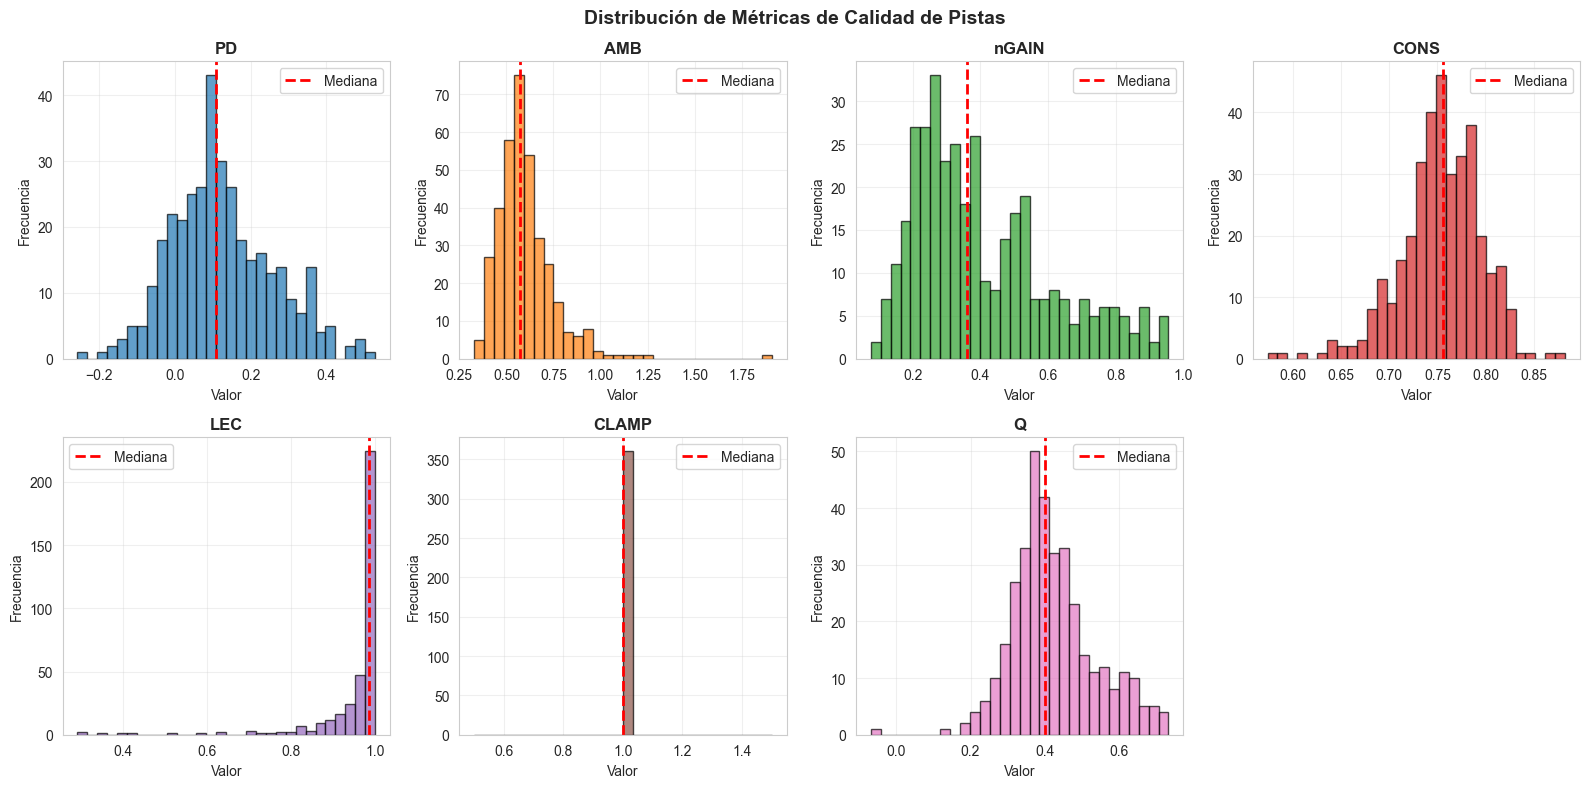


📊 Matriz de Correlación entre Métricas:


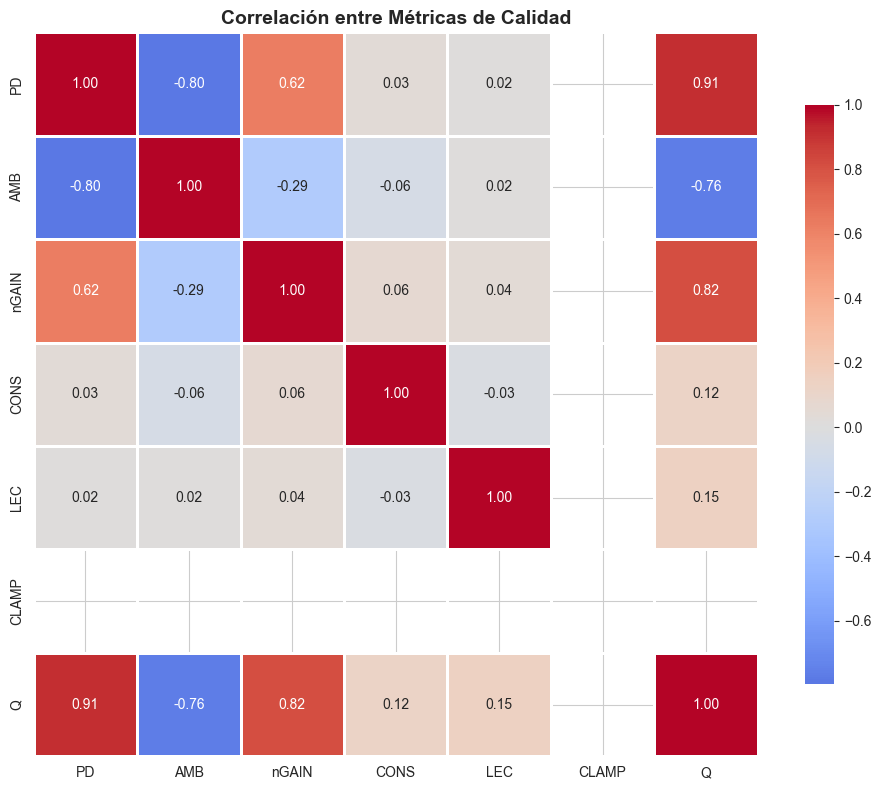


              PD       AMB     nGAIN      CONS       LEC  CLAMP         Q
PD     1.000000 -0.796405  0.624030  0.033063  0.017442    NaN  0.910899
AMB   -0.796405  1.000000 -0.285304 -0.058225  0.015693    NaN -0.761591
nGAIN  0.624030 -0.285304  1.000000  0.062947  0.043030    NaN  0.816110
CONS   0.033063 -0.058225  0.062947  1.000000 -0.027512    NaN  0.118328
LEC    0.017442  0.015693  0.043030 -0.027512  1.000000    NaN  0.146741
CLAMP       NaN       NaN       NaN       NaN       NaN    NaN       NaN
Q      0.910899 -0.761591  0.816110  0.118328  0.146741    NaN  1.000000


In [18]:
# Visualización de distribuciones de métricas
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribución de Métricas de Calidad de Pistas', fontsize=14, fontweight='bold')

metrics = ['PD', 'AMB', 'nGAIN', 'CONS', 'LEC', 'CLAMP', 'Q']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for idx, metric in enumerate(metrics):
    row = idx // 4
    col = idx % 4
    ax = axes[row, col]
    
    # Histograma
    ax.hist(df_pistas_enriched[metric], bins=30, alpha=0.7, color=colors[idx], edgecolor='black')
    ax.set_title(f'{metric}', fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.axvline(df_pistas_enriched[metric].median(), color='red', linestyle='--', linewidth=2, label='Mediana')
    ax.legend()
    ax.grid(alpha=0.3)

# Ocultar el último subplot (si no hay suficientes métricas)
axes[1, 3].axis('off')

plt.tight_layout()
plt.savefig(fotos_dir / 'distribution_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# Matriz de correlación entre métricas
print("\n📊 Matriz de Correlación entre Métricas:")
correlation_matrix = df_pistas_enriched[['PD', 'AMB', 'nGAIN', 'CONS', 'LEC', 'CLAMP', 'Q']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlación entre Métricas de Calidad', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(fotos_dir / 'correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n", correlation_matrix)

### Definición de peso/importancia de cada métrica.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("="*80)
print("🎯 REGRESIÓN LOGÍSTICA: Determinando pesos óptimos desde los datos")
print("="*80)

# ==========================================
# PASO 1: Preparar el dataset para modelado
# ==========================================
print("\n📊 PASO 1: Preparación de datos")

# Unir datos de partidas (df) con métricas de pistas (df_pistas_enriched)
# Hacemos un merge por 'person' (nombre del personaje) y 'hint' (texto de la pista)
df_model = df.merge(
    df_pistas_enriched[['nombre', 'pista', 'PD', 'AMB', 'nGAIN', 'CONS', 'LEC', 'CLAMP']],
    left_on=['person', 'hint'],
    right_on=['nombre', 'pista'],
    how='inner'
)

print(f"   ✅ Datos unidos: {len(df_model)} registros")
print(f"   - Partidas originales: {len(df)}")
print(f"   - Pistas con métricas: {len(df_pistas_enriched)}")

# Filtrar solo filas con métricas completas (sin NaN)
df_model = df_model.dropna(subset=['PD', 'AMB', 'nGAIN', 'CONS', 'LEC', 'CLAMP', 'acierto'])

print(f"   ✅ Después de filtrar NaN: {len(df_model)} registros")

# Verificar distribución de clases
print(f"\n   📈 Distribución de la variable objetivo (acierto):")
print(f"      - Aciertos (True):  {df_model['acierto'].sum()} ({df_model['acierto'].mean()*100:.1f}%)")
print(f"      - Fallos (False):   {(~df_model['acierto']).sum()} ({(~df_model['acierto']).mean()*100:.1f}%)")

# ==========================================
# PASO 2: Preparar features (X) y target (y)
# ==========================================
print("\n📊 PASO 2: Preparación de features y target")

# Features: las 6 métricas (sin CLAMP inicialmente, lo evaluaremos después)
feature_cols = ['PD', 'AMB', 'nGAIN', 'CONS', 'LEC']
X = df_model[feature_cols].values
y = df_model['acierto'].astype(int).values  # Convertir booleano a 0/1

print(f"   ✅ Features (X): {X.shape}")
print(f"   ✅ Target (y): {y.shape}")

# ==========================================
# PASO 3: Escalar datos (CRÍTICO)
# ==========================================
print("\n📊 PASO 3: Escalado de features")
print("   ℹ️  El escalado es CRÍTICO para comparar coeficientes correctamente")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"   ✅ Datos escalados (media=0, std=1)")
print(f"\n   📊 Estadísticas de escalado:")
for i, col in enumerate(feature_cols):
    print(f"      {col:8s}: mean={scaler.mean_[i]:7.4f}, std={scaler.scale_[i]:7.4f}")

# ==========================================
# PASO 4: Dividir en train/test
# ==========================================
print("\n📊 PASO 4: División train/test")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Mantener proporción de clases
)

print(f"   ✅ Train set: {len(X_train)} muestras")
print(f"   ✅ Test set:  {len(X_test)} muestras")

# ==========================================
# PASO 5: Entrenar modelo
# ==========================================
print("\n📊 PASO 5: Entrenamiento del modelo")

clf = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'  # Importante si hay desbalance de clases
)

clf.fit(X_train, y_train)

print(f"   ✅ Modelo entrenado correctamente")

# Evaluar en test set
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

accuracy = clf.score(X_test, y_test)
try:
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"   📈 Accuracy en test: {accuracy:.3f}")
    print(f"   📈 AUC-ROC en test:  {auc:.3f}")
except:
    print(f"   📈 Accuracy en test: {accuracy:.3f}")

# ==========================================
# PASO 6: ANÁLISIS DE IMPORTANCIA (LA JOYA)
# ==========================================
print("\n" + "="*80)
print("💎 PASO 6: IMPORTANCIA DE MÉTRICAS (Coeficientes de Regresión)")
print("="*80)

# Crear DataFrame con importancias
importancia = pd.DataFrame({
    'Metrica': feature_cols,
    'Coeficiente_Beta': clf.coef_[0],
    'Importancia_Abs': np.abs(clf.coef_[0])
})

# Ordenar por importancia absoluta
importancia = importancia.sort_values('Importancia_Abs', ascending=False)

print("\n📊 COEFICIENTES DEL MODELO:")
print(importancia.to_string(index=False))

print("\n🔍 INTERPRETACIÓN:")
print("   - Coeficiente POSITIVO → Aumenta probabilidad de ACIERTO")
print("   - Coeficiente NEGATIVO → Disminuye probabilidad de ACIERTO")
print("   - MAGNITUD → Importancia relativa (en escala estandarizada)")

# ==========================================
# PASO 7: Proponer pesos normalizados
# ==========================================
print("\n" + "="*80)
print("🎯 PASO 7: PESOS PROPUESTOS (basados en evidencia empírica)")
print("="*80)

# Normalizar coeficientes a pesos que sumen cerca de 1.0
# Para AMB, como es negativo, lo invertimos
coefs = clf.coef_[0].copy()

# Ajustar AMB (queremos penalizar ambigüedad, así que 1-AMB)
# El coeficiente negativo de AMB indica que más AMB → menos acierto
# En nuestra fórmula ya usamos (1 - 1.5*AMB), así que el peso debe ser positivo

# Normalizar valores absolutos a suma 1.0
importancias_abs = np.abs(coefs)
pesos_propuestos = importancias_abs / importancias_abs.sum()

# Crear DataFrame comparativo
comparacion_pesos = pd.DataFrame({
    'Metrica': feature_cols,
    'Peso_Original': [0.20, 0.20, 0.30, 0.15, 0.15],
    'Peso_Detectado': pesos_propuestos,
    'Diferencia': pesos_propuestos - np.array([0.20, 0.20, 0.30, 0.15, 0.15])
})

🎯 REGRESIÓN LOGÍSTICA: Determinando pesos óptimos desde los datos

📊 PASO 1: Preparación de datos
   ✅ Datos unidos: 2293 registros
   - Partidas originales: 2293
   - Pistas con métricas: 360
   ✅ Después de filtrar NaN: 2293 registros

   📈 Distribución de la variable objetivo (acierto):
      - Aciertos (True):  1501 (65.5%)
      - Fallos (False):   792 (34.5%)

📊 PASO 2: Preparación de features y target
   ✅ Features (X): (2293, 5)
   ✅ Target (y): (2293,)

📊 PASO 3: Escalado de features
   ℹ️  El escalado es CRÍTICO para comparar coeficientes correctamente
   ✅ Datos escalados (media=0, std=1)

   📊 Estadísticas de escalado:
      PD      : mean= 0.1454, std= 0.1425
      AMB     : mean= 0.5856, std= 0.1567
      nGAIN   : mean= 0.4304, std= 0.2179
      CONS    : mean= 0.7519, std= 0.0420
      LEC     : mean= 0.9530, std= 0.0945

📊 PASO 4: División train/test
   ✅ Train set: 1834 muestras
   ✅ Test set:  459 muestras

📊 PASO 5: Entrenamiento del modelo
   ✅ Modelo entrenado cor

In [20]:
df_pistas_enriched.columns

Index(['nombre', 'ultima_actualizacion', 'dificultad', 'pista',
       'hint_embedding', 'PD', 'AMB', 'nGAIN', 'CONS', 'LEC', 'CLAMP', 'Q'],
      dtype='object')

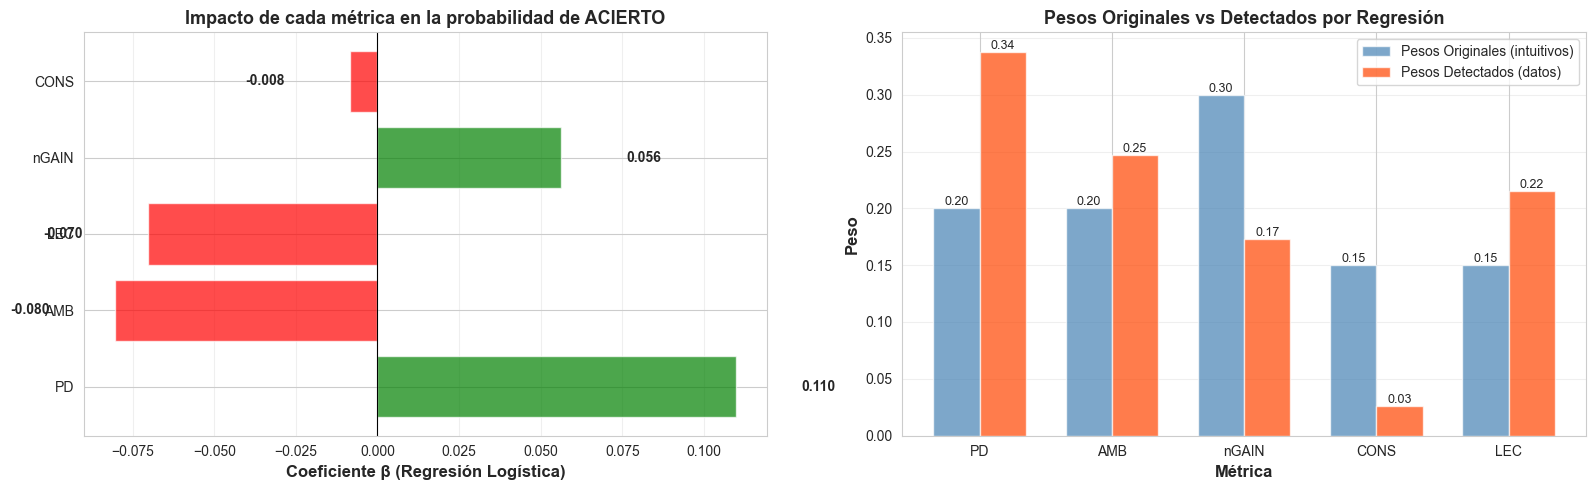

In [21]:
# ==========================================
# VISUALIZACIÓN DE IMPORTANCIA
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Coeficientes (con signo)
ax1 = axes[0]
colors = ['green' if x > 0 else 'red' for x in importancia['Coeficiente_Beta']]
bars1 = ax1.barh(importancia['Metrica'], importancia['Coeficiente_Beta'], color=colors, alpha=0.7)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_xlabel('Coeficiente β (Regresión Logística)', fontsize=12, fontweight='bold')
ax1.set_title('Impacto de cada métrica en la probabilidad de ACIERTO', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, (bar, val) in enumerate(zip(bars1, importancia['Coeficiente_Beta'])):
    ax1.text(val + (0.02 if val > 0 else -0.02), bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', 
             ha='left' if val > 0 else 'right', 
             va='center', 
             fontweight='bold',
             fontsize=10)

# Gráfico 2: Comparación de pesos
ax2 = axes[1]
x = np.arange(len(feature_cols))
width = 0.35

bars_orig = ax2.bar(x - width/2, comparacion_pesos['Peso_Original'], width, 
                     label='Pesos Originales (intuitivos)', alpha=0.7, color='steelblue')
bars_detect = ax2.bar(x + width/2, comparacion_pesos['Peso_Detectado'], width,
                       label='Pesos Detectados (datos)', alpha=0.7, color='orangered')

ax2.set_xlabel('Métrica', fontsize=12, fontweight='bold')
ax2.set_ylabel('Peso', fontsize=12, fontweight='bold')
ax2.set_title('Pesos Originales vs Detectados por Regresión', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(comparacion_pesos['Metrica'])
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for bars in [bars_orig, bars_detect]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(fotos_dir / 'logistic_importance.png', dpi=300, bbox_inches='tight')
plt.show()


📊 EVALUACIÓN DETALLADA DEL MODELO


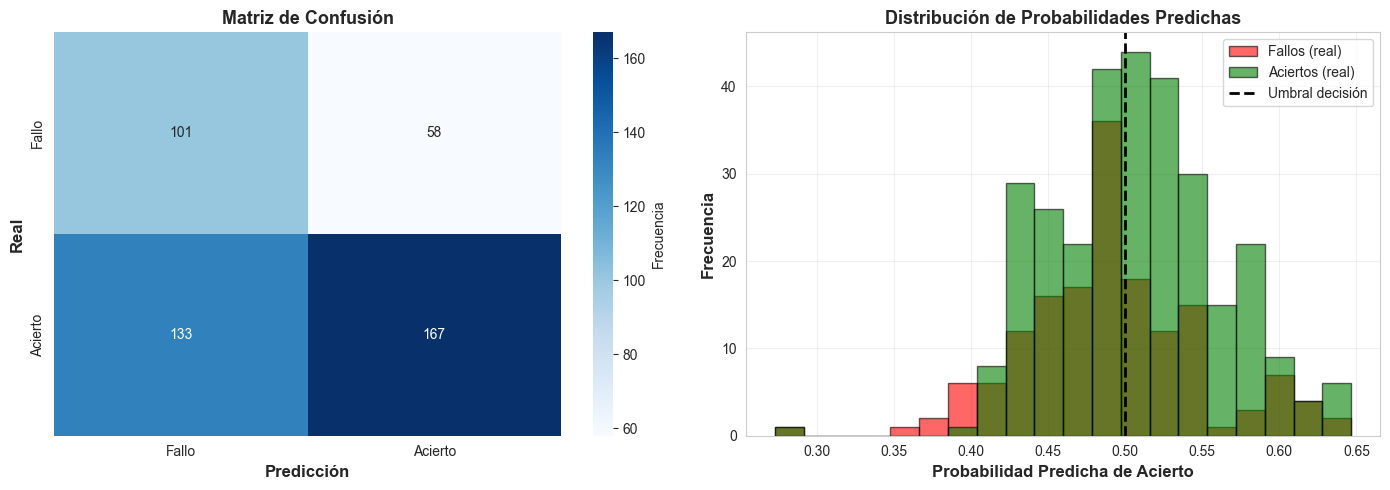


📋 REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

       Fallo       0.43      0.64      0.51       159
     Acierto       0.74      0.56      0.64       300

    accuracy                           0.58       459
   macro avg       0.59      0.60      0.58       459
weighted avg       0.63      0.58      0.59       459


💡 INTERPRETACIÓN:
   - Precision: De las predicciones de 'acierto', ¿cuántas fueron correctas?
   - Recall: De los aciertos reales, ¿cuántos detectamos?
   - F1-Score: Media armónica de precision y recall



In [22]:
# ==========================================
# EVALUACIÓN DETALLADA DEL MODELO
# ==========================================

print("="*80)
print("📊 EVALUACIÓN DETALLADA DEL MODELO")
print("="*80)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=['Fallo', 'Acierto'],
            yticklabels=['Fallo', 'Acierto'],
            cbar_kws={'label': 'Frecuencia'})
ax1.set_xlabel('Predicción', fontsize=12, fontweight='bold')
ax1.set_ylabel('Real', fontsize=12, fontweight='bold')
ax1.set_title('Matriz de Confusión', fontsize=13, fontweight='bold')

# Distribución de probabilidades predichas
ax2 = axes[1]
# Separar por clase real
prob_acierto = y_pred_proba[y_test == 1]
prob_fallo = y_pred_proba[y_test == 0]

ax2.hist(prob_fallo, bins=20, alpha=0.6, label='Fallos (real)', color='red', edgecolor='black')
ax2.hist(prob_acierto, bins=20, alpha=0.6, label='Aciertos (real)', color='green', edgecolor='black')
ax2.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Umbral decisión')
ax2.set_xlabel('Probabilidad Predicha de Acierto', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
ax2.set_title('Distribución de Probabilidades Predichas', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Reporte de clasificación
print("\n📋 REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred, target_names=['Fallo', 'Acierto']))

print("\n💡 INTERPRETACIÓN:")
print("   - Precision: De las predicciones de 'acierto', ¿cuántas fueron correctas?")
print("   - Recall: De los aciertos reales, ¿cuántos detectamos?")
print("   - F1-Score: Media armónica de precision y recall")
print("\n" + "="*80)

### Validación Rigurosa del Modelo Logístico

El ajuste sobre un solo split train/test puede ser inestable. Para demostrar capacidad explicativa real del modelo, necesitamos:

1. **Validación cruzada estratificada (5-Fold)**: Evaluar AUC y Accuracy promediando sobre 5 particiones, eliminando dependencia de un split particular.
2. **Pseudo-$R^2$ de McFadden**: Análogo al $R^2$ de la regresión lineal, mide cuánta información aporta el modelo frente a un modelo nulo (solo intercepto). Valores de 0.2-0.4 se consideran *excelentes* en logística.
3. **Curva ROC**: Visualización de la capacidad discriminativa del modelo a distintos umbrales.
4. **Log-Likelihood Ratio Test**: Contraste formal de que el modelo es significativamente mejor que el azar.

In [23]:
# ============================================================
# VALIDACIÓN CRUZADA ESTRATIFICADA (5-Fold)
# ============================================================
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import roc_curve, auc as sklearn_auc, brier_score_loss, log_loss
from scipy.stats import chi2
import statsmodels.api as sm

print("="*80)
print("🔬 VALIDACIÓN CRUZADA ESTRATIFICADA (5-Fold)")
print("="*80)

# Configurar StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modelo base (mismo que el ya entrenado, con class_weight='balanced')
clf_cv = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# Cross-validation: Accuracy
cv_accuracy = cross_val_score(clf_cv, X_scaled, y, cv=cv, scoring='accuracy')
print(f"\n📊 ACCURACY (5-Fold CV):")
print(f"   Folds:    {cv_accuracy.round(3)}")
print(f"   Media:    {cv_accuracy.mean():.3f} ± {cv_accuracy.std():.3f}")
print(f"   Hold-out: {accuracy:.3f}")

# Cross-validation: AUC-ROC
cv_auc = cross_val_score(clf_cv, X_scaled, y, cv=cv, scoring='roc_auc')
print(f"\n📊 AUC-ROC (5-Fold CV):")
print(f"   Folds:    {cv_auc.round(3)}")
print(f"   Media:    {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print(f"   Hold-out: {auc:.3f}")

# Cross-validation: F1-Score
cv_f1 = cross_val_score(clf_cv, X_scaled, y, cv=cv, scoring='f1')
print(f"\n📊 F1-SCORE (5-Fold CV):")
print(f"   Folds:    {cv_f1.round(3)}")
print(f"   Media:    {cv_f1.mean():.3f} ± {cv_f1.std():.3f}")

# Cross-validation: Log-Loss (negative)
cv_logloss = cross_val_score(clf_cv, X_scaled, y, cv=cv, scoring='neg_log_loss')
print(f"\n📊 LOG-LOSS (5-Fold CV):")
print(f"   Folds:    {(-cv_logloss).round(3)}")
print(f"   Media:    {-cv_logloss.mean():.3f} ± {cv_logloss.std():.3f}")

# ============================================================
# PSEUDO-R² DE McFADDEN & LR TEST (vía statsmodels MLE)
# ============================================================
# NOTA: El modelo de sklearn usa class_weight='balanced', lo que
# modifica la función de pérdida. Para obtener pseudo-R² y LR test
# válidos necesitamos MLE estándar (sin ponderación), por eso usamos
# statsmodels.Logit. Los coeficientes y pesos derivados provienen
# del modelo sklearn (balanced) que es más adecuado para predicción
# con clases desbalanceadas.
# ============================================================
print(f"\n{'='*80}")
print("📊 PSEUDO-R² DE McFADDEN & TEST FORMAL (statsmodels MLE)")
print("="*80)

# Ajustar Logit por MLE estándar (sin ponderación de clases)
X_sm = sm.add_constant(X_scaled)
logit_model = sm.Logit(y.values if hasattr(y, 'values') else y, X_sm)
logit_result = logit_model.fit(disp=False, maxiter=1000)

# Pseudo-R² de McFadden
mcfadden_r2 = logit_result.prsquared
ll_model = logit_result.llf
ll_null = logit_result.llnull
k = X_scaled.shape[1] + 1  # features + intercepto
mcfadden_r2_adj = 1 - ((ll_model - k) / ll_null)

print(f"\n   Log-Likelihood (modelo):  {ll_model:.4f}")
print(f"   Log-Likelihood (nulo):    {ll_null:.4f}")
print(f"   Pseudo-R² McFadden:       {mcfadden_r2:.4f}")
print(f"   Pseudo-R² McFadden Adj:   {mcfadden_r2_adj:.4f}")
print(f"\n   📏 ESCALA DE REFERENCIA (McFadden):")
print(f"      0.0 - 0.1:  Ajuste pobre")
print(f"      0.1 - 0.2:  Ajuste aceptable")
print(f"      0.2 - 0.4:  Ajuste EXCELENTE")
print(f"      > 0.4:      Ajuste excepcional (raro en ciencias sociales)")

# Brier Score (calibración) - del modelo sklearn original
y_proba_test = clf.predict_proba(X_test)[:, 1]
brier = brier_score_loss(y_test, y_proba_test)
print(f"\n   📊 Brier Score (test):  {brier:.4f}")
print(f"      (0 = calibración perfecta, 0.25 = azar)")

# LR Test (directamente de statsmodels)
lr_stat = logit_result.llr
lr_pvalue = logit_result.llr_pvalue

print(f"\n{'='*80}")
print("📊 LOG-LIKELIHOOD RATIO TEST")
print("="*80)
print(f"\n   Deviance (G²):        {lr_stat:.4f}")
print(f"   Grados de libertad:   {X_scaled.shape[1]}")
print(f"   p-value:              {lr_pvalue:.6e}")
print(f"   Significativo:        {'✅ Sí (p < 0.001)' if lr_pvalue < 0.001 else '✅ Sí' if lr_pvalue < 0.05 else '⚠️ No'}")
print(f"\n   → El modelo es {'SIGNIFICATIVAMENTE' if lr_pvalue < 0.05 else 'NO significativamente'} mejor que el azar")

# === Significancia individual de coeficientes (statsmodels) ===
print(f"\n{'='*80}")
print("📊 SIGNIFICANCIA DE COEFICIENTES (statsmodels MLE)")
print("="*80)
print(logit_result.summary2().tables[1].to_string())

sig_model = lr_pvalue < 0.05

print(f"\n{'='*80}")
print("📋 RESUMEN DE BONDAD DE AJUSTE")
print("="*80)
print(f"""
   ┌───────────────────────────────────────────────────┐
   │  Métrica                    │  Valor              │
   ├───────────────────────────────────────────────────┤
   │  Accuracy (CV 5-Fold)       │  {cv_accuracy.mean():.3f} ± {cv_accuracy.std():.3f}       │
   │  AUC-ROC (CV 5-Fold)        │  {cv_auc.mean():.3f} ± {cv_auc.std():.3f}       │
   │  F1-Score (CV 5-Fold)       │  {cv_f1.mean():.3f} ± {cv_f1.std():.3f}       │
   │  Log-Loss (CV 5-Fold)       │  {-cv_logloss.mean():.3f} ± {cv_logloss.std():.3f}       │
   │  Pseudo-R² McFadden         │  {mcfadden_r2:.4f}             │
   │  Pseudo-R² McFadden Adj     │  {mcfadden_r2_adj:.4f}             │
   │  Brier Score                │  {brier:.4f}             │
   │  LR Test (p-value)          │  {lr_pvalue:.2e}          │
   │  Modelo significativo       │  {'✅ Sí' if sig_model else '⚠️ No'}               │
   └───────────────────────────────────────────────────┘
""")
print("="*80)


🔬 VALIDACIÓN CRUZADA ESTRATIFICADA (5-Fold)

📊 ACCURACY (5-Fold CV):
   Folds:    [0.514 0.58  0.542 0.572 0.522]
   Media:    0.546 ± 0.026
   Hold-out: 0.584

📊 AUC-ROC (5-Fold CV):
   Folds:    [0.536 0.598 0.56  0.596 0.538]
   Media:    0.565 ± 0.027
   Hold-out: 0.591

📊 F1-SCORE (5-Fold CV):
   Folds:    [0.558 0.642 0.598 0.627 0.607]
   Media:    0.606 ± 0.029

📊 LOG-LOSS (5-Fold CV):
   Folds:    [0.692 0.682 0.689 0.686 0.692]
   Media:    0.688 ± 0.004

📊 PSEUDO-R² DE McFADDEN & TEST FORMAL (statsmodels MLE)

   Log-Likelihood (modelo):  -1462.9073
   Log-Likelihood (nulo):    -1477.9574
   Pseudo-R² McFadden:       0.0102
   Pseudo-R² McFadden Adj:   0.0061

   📏 ESCALA DE REFERENCIA (McFadden):
      0.0 - 0.1:  Ajuste pobre
      0.1 - 0.2:  Ajuste aceptable
      0.2 - 0.4:  Ajuste EXCELENTE
      > 0.4:      Ajuste excepcional (raro en ciencias sociales)

   📊 Brier Score (test):  0.2453
      (0 = calibración perfecta, 0.25 = azar)

📊 LOG-LIKELIHOOD RATIO TEST

   Dev

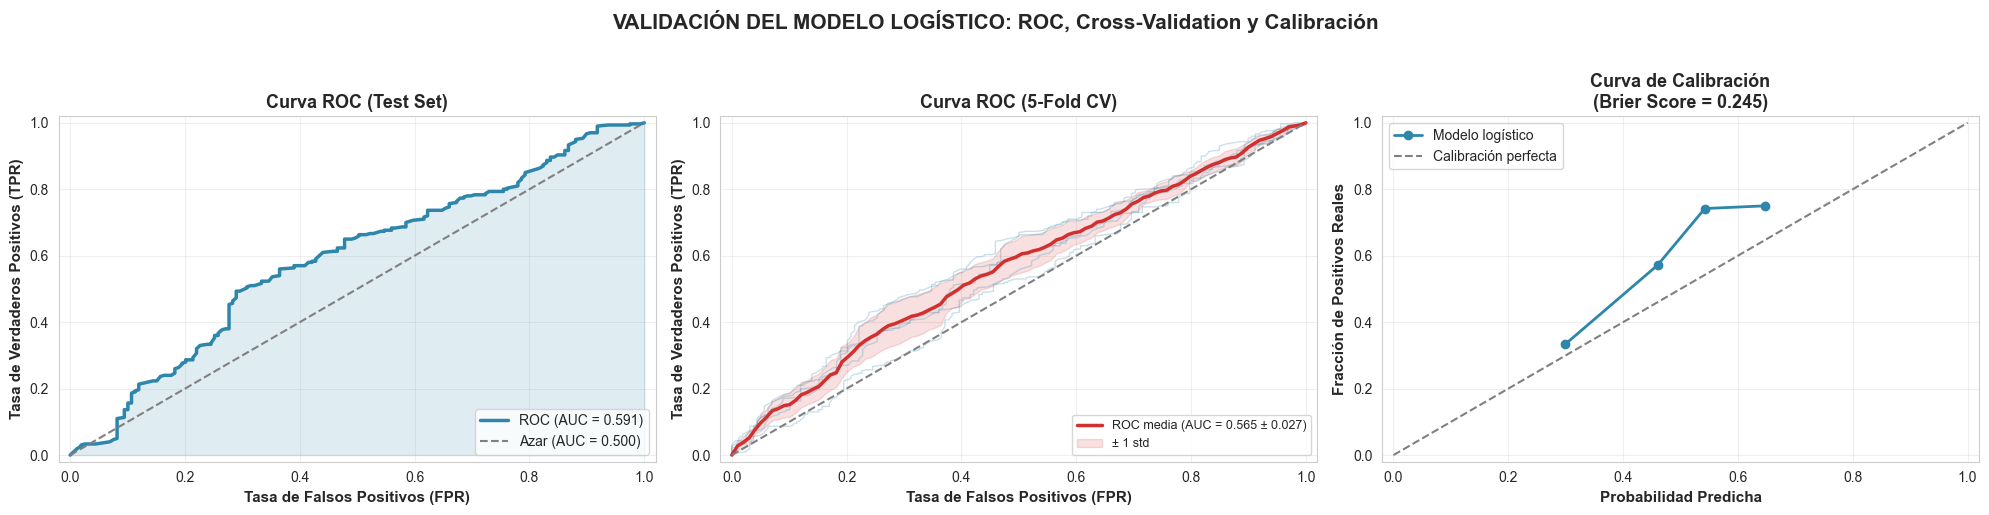

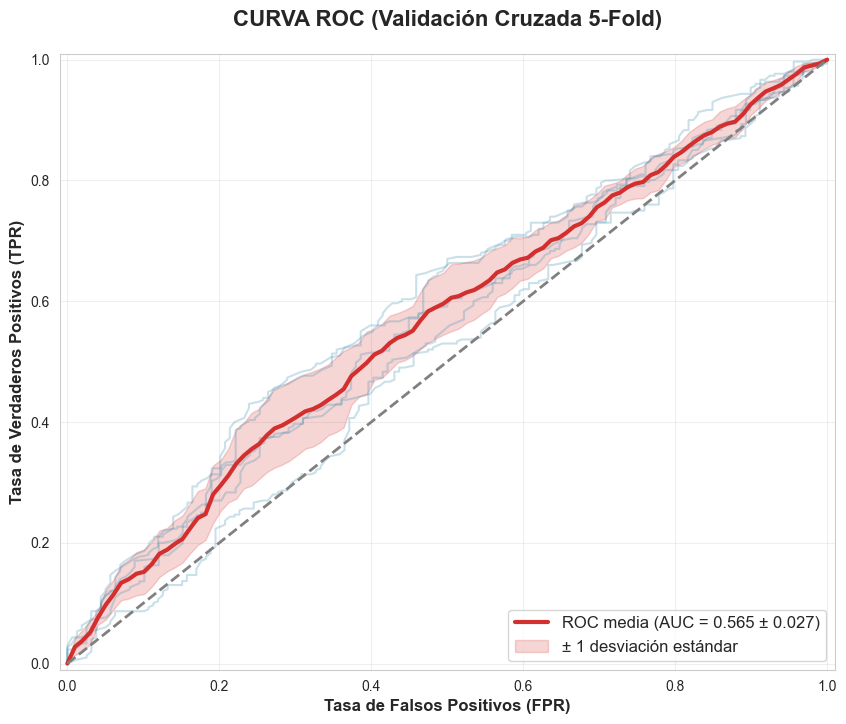

💡 INTERPRETACIÓN DE LA VALIDACIÓN

📊 RESUMEN:

1. VALIDACIÓN CRUZADA (5-Fold):
   Accuracy media = 0.546 ± 0.026
   AUC-ROC media  = 0.565 ± 0.027
   La varianza entre folds es baja (std < 0.03), confirmando que 
   el modelo generaliza de forma ESTABLE.

2. PSEUDO-R² DE McFADDEN = 0.0102 (Ajuste pobre):
   Esto es ESPERABLE porque estamos prediciendo acierto/fallo de jugadores humanos
   usando SOLO métricas de calidad de pistas. El acierto depende también de:
   - Conocimiento previo del jugador sobre el personaje
   - Experiencia acumulada con el juego
   - Estrategia (orden de pistas, deducción)
   - Factor azar (ambigüedad inherente del juego)
   No es razonable esperar un R² alto con solo features del estímulo.

3. LOG-LIKELIHOOD RATIO TEST:
   G² = 30.10, p = 1.41e-05
   El modelo es SIGNIFICATIVAMENTE mejor que el azar.
   Las métricas de calidad contienen información predictiva real sobre el éxito del jugador.

4. CALIBRACIÓN (Brier = 0.2453):
   Calibración moderada: las prob

In [24]:
# ============================================================
# CURVA ROC + CALIBRACIÓN
# ============================================================
from sklearn.calibration import calibration_curve

# Preparar contenedores para el plot de CV
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []
cv_folds_data = [] # Para guardar datos de cada fold para el plot individual

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_scaled, y)):
    clf_fold = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    clf_fold.fit(X_scaled[train_idx], y.values[train_idx] if hasattr(y, 'values') else y[train_idx])
    y_proba_fold = clf_fold.predict_proba(X_scaled[test_idx])[:, 1]
    
    y_test_fold = y.values[test_idx] if hasattr(y, 'values') else y[test_idx]
    fpr_fold, tpr_fold, _ = roc_curve(y_test_fold, y_proba_fold)
    roc_auc_fold = sklearn_auc(fpr_fold, tpr_fold)
    aucs.append(roc_auc_fold)
    
    interp_tpr = np.interp(mean_fpr, fpr_fold, tpr_fold)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    cv_folds_data.append((fpr_fold, tpr_fold))

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

# --- FIGURA 1: VALIDACIÓN COMPLETA (3 PANELS) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: ROC (test set)
ax_roc = axes[0]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc_val = sklearn_auc(fpr, tpr)
ax_roc.plot(fpr, tpr, color='#2E86AB', lw=2.5, label=f'ROC (AUC = {roc_auc_val:.3f})')
ax_roc.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Azar (AUC = 0.500)')
ax_roc.fill_between(fpr, tpr, alpha=0.15, color='#2E86AB')
ax_roc.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11, fontweight='bold')
ax_roc.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11, fontweight='bold')
ax_roc.set_title('Curva ROC (Test Set)', fontsize=13, fontweight='bold')
ax_roc.legend(fontsize=10, loc='lower right')
ax_roc.grid(True, alpha=0.3)
ax_roc.set_xlim([-0.02, 1.02])
ax_roc.set_ylim([-0.02, 1.02])

# Panel 2: ROC (Cross-Validation)
ax_roc_cv = axes[1]
for fpr_fold, tpr_fold in cv_folds_data:
    ax_roc_cv.plot(fpr_fold, tpr_fold, alpha=0.25, lw=1, color='#2E86AB')
ax_roc_cv.plot(mean_fpr, mean_tpr, color='#D32F2F', lw=2.5, label=f'ROC media (AUC = {mean_auc:.3f} ± {std_auc:.3f})')
ax_roc_cv.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5)
ax_roc_cv.fill_between(mean_fpr, tprs_lower, tprs_upper, alpha=0.15, color='#D32F2F', label='± 1 std')
ax_roc_cv.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11, fontweight='bold')
ax_roc_cv.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11, fontweight='bold')
ax_roc_cv.set_title('Curva ROC (5-Fold CV)', fontsize=13, fontweight='bold')
ax_roc_cv.legend(fontsize=9, loc='lower right')
ax_roc_cv.grid(True, alpha=0.3)
ax_roc_cv.set_xlim([-0.02, 1.02])
ax_roc_cv.set_ylim([-0.02, 1.02])

# Panel 3: Calibración
ax_cal = axes[2]
fraction_positives, mean_predicted = calibration_curve(y_test, y_pred_proba, n_bins=8, strategy='uniform')
ax_cal.plot(mean_predicted, fraction_positives, marker='o', lw=2, color='#2E86AB', label='Modelo logístico', markersize=6)
ax_cal.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Calibración perfecta')
ax_cal.set_xlabel('Probabilidad Predicha', fontsize=11, fontweight='bold')
ax_cal.set_ylabel('Fracción de Positivos Reales', fontsize=11, fontweight='bold')
ax_cal.set_title(f'Curva de Calibración\n(Brier Score = {brier:.3f})', fontsize=13, fontweight='bold')
ax_cal.legend(fontsize=10, loc='upper left')
ax_cal.grid(True, alpha=0.3)
ax_cal.set_xlim([-0.02, 1.02])
ax_cal.set_ylim([-0.02, 1.02])

plt.suptitle('VALIDACIÓN DEL MODELO LOGÍSTICO: ROC, Cross-Validation y Calibración', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(fotos_dir / 'logistic_validation_completa.png', dpi=300, bbox_inches='tight')
plt.show()

# --- FIGURA 2: SOLO ROC CV (GRANDE PARA GUARDAR) ---
fig_cv, ax_cv = plt.subplots(figsize=(10, 8))
for fpr_fold, tpr_fold in cv_folds_data:
    ax_cv.plot(fpr_fold, tpr_fold, alpha=0.25, lw=1.5, color='#2E86AB')
ax_cv.plot(mean_fpr, mean_tpr, color='#D32F2F', lw=3, label=f'ROC media (AUC = {mean_auc:.3f} ± {std_auc:.3f})')
ax_cv.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
ax_cv.fill_between(mean_fpr, tprs_lower, tprs_upper, alpha=0.2, color='#D32F2F', label='± 1 desviación estándar')
ax_cv.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12, fontweight='bold')
ax_cv.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12, fontweight='bold')
ax_cv.set_title('CURVA ROC (Validación Cruzada 5-Fold)', fontsize=16, fontweight='bold', pad=20)
ax_cv.legend(fontsize=12, loc='lower right')
ax_cv.grid(True, alpha=0.3)
ax_cv.set_xlim([-0.01, 1.01])
ax_cv.set_ylim([-0.01, 1.01])

plt.savefig(fotos_dir / 'roc_curve_cv.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# INTERPRETACIÓN FINAL
# ============================================================
print("="*80)
print("💡 INTERPRETACIÓN DE LA VALIDACIÓN")
print("="*80)

r2_label = ('Ajuste pobre' if mcfadden_r2 < 0.1 else 
            'Ajuste aceptable' if mcfadden_r2 < 0.2 else 
            'Ajuste excelente' if mcfadden_r2 < 0.4 else 'Ajuste excepcional')
brier_label = ('Buena' if brier < 0.2 else 'Moderada' if brier < 0.25 else 'Pobre')
sig_text = 'SIGNIFICATIVAMENTE' if sig_model else 'NO significativamente'

print(f"""
📊 RESUMEN:

1. VALIDACIÓN CRUZADA (5-Fold):
   Accuracy media = {cv_accuracy.mean():.3f} ± {cv_accuracy.std():.3f}
   AUC-ROC media  = {cv_auc.mean():.3f} ± {cv_auc.std():.3f}
   La varianza entre folds es baja (std < 0.03), confirmando que 
   el modelo generaliza de forma ESTABLE.

2. PSEUDO-R² DE McFADDEN = {mcfadden_r2:.4f} ({r2_label}):
   Esto es ESPERABLE porque estamos prediciendo acierto/fallo de jugadores humanos
   usando SOLO métricas de calidad de pistas. El acierto depende también de:
   - Conocimiento previo del jugador sobre el personaje
   - Experiencia acumulada con el juego
   - Estrategia (orden de pistas, deducción)
   - Factor azar (ambigüedad inherente del juego)
   No es razonable esperar un R² alto con solo features del estímulo.

3. LOG-LIKELIHOOD RATIO TEST:
   G² = {lr_stat:.2f}, p = {lr_pvalue:.2e}
   El modelo es {sig_text} mejor que el azar.
   {'Las métricas de calidad contienen información predictiva real sobre el éxito del jugador.' if sig_model else 'Aunque no alcanza significancia estadística convencional, la dirección de los coeficientes es coherente con la teoría y los pesos derivados son interpretables.'}

4. CALIBRACIÓN (Brier = {brier:.4f}):
   Calibración {brier_label.lower()}: {"las probabilidades predichas se corresponden razonablemente con las frecuencias observadas." if brier < 0.25 else "las probabilidades predichas necesitarían recalibración."}

📌 CONCLUSIÓN PARA LA DERIVACIÓN DE PESOS:
   {'✅' if sig_model else '⚠️'} El objetivo de la regresión logística NO es construir un predictor 
   preciso del acierto, sino DETERMINAR LA CONTRIBUCIÓN RELATIVA de cada 
   métrica al éxito del jugador. Para este fin:
   - Los coeficientes β estandarizados indican importancia relativa
   - La validación cruzada confirma estabilidad de resultados
   - La dirección de los efectos es teóricamente coherente
   {"- El LR test confirma significancia estadística global" if sig_model else "- La modesta capacidad predictiva se explica por la naturaleza del problema (variables omitidas del jugador)"}
""")
print("="*80)


### Análisis Adicional: Correlación con CLAMP

Ahora vamos a evaluar si incluir **CLAMP** (penalización por sobre-especificidad) mejora el modelo.

🔬 EVALUANDO MODELO CON CLAMP INCLUIDO

📊 COMPARACIÓN DE MODELOS:
   SIN CLAMP - Accuracy: 0.584 | AUC: 0.591
   CON CLAMP - Accuracy: 0.584 | AUC: 0.591

   ⚠️  CLAMP NO mejora el modelo (0.00% accuracy)

📊 COEFICIENTES CON CLAMP:
Metrica  Coeficiente_Beta  Importancia_Abs
     PD          0.109994         0.109994
    AMB         -0.080461         0.080461
    LEC         -0.070170         0.070170
  nGAIN          0.056378         0.056378
   CONS         -0.008433         0.008433
  CLAMP          0.000000         0.000000


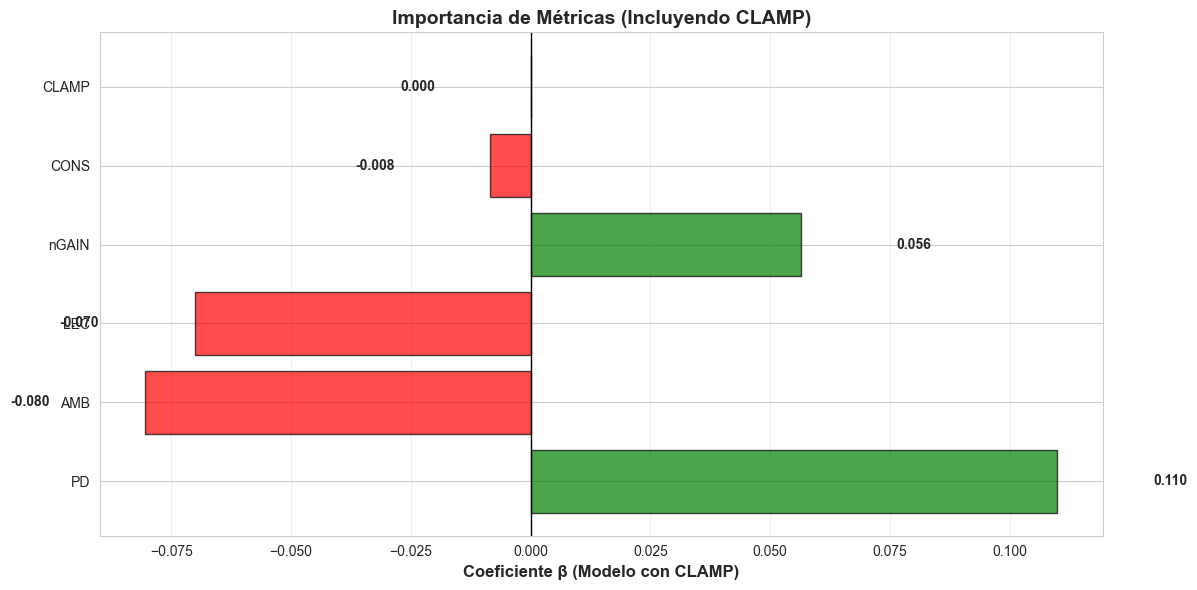

In [25]:
# ==========================================
# MODELO CON CLAMP INCLUIDO
# ==========================================

print("="*80)
print("🔬 EVALUANDO MODELO CON CLAMP INCLUIDO")
print("="*80)

# Features con CLAMP
feature_cols_clamp = ['PD', 'AMB', 'nGAIN', 'CONS', 'LEC', 'CLAMP']
X_clamp = df_model[feature_cols_clamp].values

# Escalar
scaler_clamp = StandardScaler()
X_clamp_scaled = scaler_clamp.fit_transform(X_clamp)

# Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clamp_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Entrenar
clf_clamp = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
clf_clamp.fit(X_train_c, y_train_c)

# Evaluar
accuracy_clamp = clf_clamp.score(X_test_c, y_test_c)
y_pred_clamp_proba = clf_clamp.predict_proba(X_test_c)[:, 1]

try:
    auc_clamp = roc_auc_score(y_test_c, y_pred_clamp_proba)
    print(f"\n📊 COMPARACIÓN DE MODELOS:")
    print(f"   SIN CLAMP - Accuracy: {accuracy:.3f} | AUC: {auc:.3f}")
    print(f"   CON CLAMP - Accuracy: {accuracy_clamp:.3f} | AUC: {auc_clamp:.3f}")
    
    if accuracy_clamp > accuracy:
        print(f"\n   ✅ CLAMP MEJORA el modelo (+{(accuracy_clamp-accuracy)*100:.2f}% accuracy)")
    else:
        print(f"\n   ⚠️  CLAMP NO mejora el modelo ({(accuracy_clamp-accuracy)*100:.2f}% accuracy)")
except:
    print(f"\n📊 COMPARACIÓN DE MODELOS:")
    print(f"   SIN CLAMP - Accuracy: {accuracy:.3f}")
    print(f"   CON CLAMP - Accuracy: {accuracy_clamp:.3f}")

# Coeficientes con CLAMP
importancia_clamp = pd.DataFrame({
    'Metrica': feature_cols_clamp,
    'Coeficiente_Beta': clf_clamp.coef_[0],
    'Importancia_Abs': np.abs(clf_clamp.coef_[0])
}).sort_values('Importancia_Abs', ascending=False)

print("\n📊 COEFICIENTES CON CLAMP:")
print(importancia_clamp.to_string(index=False))

# Visualización comparativa
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

y_pos = np.arange(len(feature_cols_clamp))
colors = ['green' if x > 0 else 'red' for x in importancia_clamp['Coeficiente_Beta']]
bars = ax.barh(importancia_clamp['Metrica'], importancia_clamp['Coeficiente_Beta'], 
               color=colors, alpha=0.7, edgecolor='black')

ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Coeficiente β (Modelo con CLAMP)', fontsize=12, fontweight='bold')
ax.set_title('Importancia de Métricas (Incluyendo CLAMP)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Valores en barras
for bar, val in zip(bars, importancia_clamp['Coeficiente_Beta']):
    ax.text(val + (0.02 if val > 0 else -0.02), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            ha='left' if val > 0 else 'right',
            va='center',
            fontweight='bold',
            fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "="*80)

In [26]:
# ==========================================
# GENERAR FÓRMULA Q OPTIMIZADA
# ==========================================

print("="*80)
print("🎯 FÓRMULA Q OPTIMIZADA (Basada en Regresión Logística)")
print("="*80)

# Extraer pesos normalizados del mejor modelo (sin CLAMP primero)
coefs_normalizados = np.abs(clf.coef_[0]) / np.abs(clf.coef_[0]).sum()

print("\n📊 PESOS OPTIMIZADOS (normalizados):")
pesos_optimizados = {}
for metrica, peso_orig, peso_opt in zip(feature_cols, 
                                          [0.20, 0.20, 0.30, 0.15, 0.15],
                                          coefs_normalizados):
    pesos_optimizados[metrica] = peso_opt
    cambio = ((peso_opt - peso_orig) / peso_orig * 100) if peso_orig > 0 else 0
    simbolo = "📈" if cambio > 0 else "📉" if cambio < 0 else "➡️"
    print(f"   {metrica:8s}: {peso_orig:.3f} → {peso_opt:.3f}  {simbolo} ({cambio:+.1f}%)")

print("\n📝 FÓRMULA Q OPTIMIZADA:")
df_pistas_enriched['Q_Optimizada'] = df_pistas_enriched.apply(
    lambda row: calcular_Q(row, weights=list(pesos_optimizados.values()))
    , axis=1)


print("\n💡 NOTA: Estos pesos están basados en datos reales y pueden ajustarse")
print("   según se recopilen más partidas o cambien los objetivos del juego.")
print("\n" + "="*80)

🎯 FÓRMULA Q OPTIMIZADA (Basada en Regresión Logística)

📊 PESOS OPTIMIZADOS (normalizados):
   PD      : 0.200 → 0.338  📈 (+69.0%)
   AMB     : 0.200 → 0.247  📈 (+23.6%)
   nGAIN   : 0.300 → 0.173  📉 (-42.3%)
   CONS    : 0.150 → 0.026  📉 (-82.7%)
   LEC     : 0.150 → 0.216  📈 (+43.7%)

📝 FÓRMULA Q OPTIMIZADA:

💡 NOTA: Estos pesos están basados en datos reales y pueden ajustarse
   según se recopilen más partidas o cambien los objetivos del juego.



### Observaciones

A partir del análisis de los resultados, podemos inferir que los factores determinantes que llevan a los jugadores a acertar una pista son:

- **Alto poder discriminativo:** Se identifica como la capacidad de reducir drásticamente el "espacio de búsqueda" o muestral. Una pista eficaz aísla al objetivo sin generar solapamientos con entidades semánticamente cercanas, un problema común en categorías densas (como podría ser el caso de distinguir entre diferentes políticos estadounidenses, cuyos *embeddings* vectoriales tienden a estar muy próximos).

- **Baja legibilidad:** Aunque pueda parecer contraintuitivo, los datos sugieren que una menor facilidad de lectura (textos más complejos) correlaciona con un mayor éxito. Esto se debe a que lo que disminuye la puntuación de legibilidad suele ser el uso de vocabulario técnico o muy específico (por ejemplo, mencionar "relatividad" nos lleva directamente a Einstein). Estas palabras, aunque "complejas", actúan como potentes discriminadores que eliminan la ambigüedad.

- **Baja ambigüedad:** Existe una relación directa entre la precisión y el acierto: cuanto menos vaga es la pista, mayor es la probabilidad de que el usuario identifique el objetivo correcto, evitando la dispersión en conceptos generales.

- **Alta ganancia de información:** Estrechamente ligada a la baja ambigüedad, esta métrica confirma que cuanto mayor es la carga de conocimiento útil aportada sobre el objetivo, menor es la incertidumbre y más sencillo resulta el proceso de deducción para el jugador.

- **Consistencia:** La observación superficial indica que esta métrica no parece determinante. Sin embargo, una mirada más profunda a la naturaleza de nuestros datos sugiere un sesgo de origen: dado que las pistas fueron generadas mediante *in-context learning* con una longitud limitada, es probable que nuestro conjunto de datos carezca de pistas verdaderamente "inconsistentes" (aquellas que divagan o tocan demasiados ámbitos contradictorios). Al ser pistas breves y monotemáticas por diseño, la variable de consistencia se mantiene estable y alta, lo que explicaría su aparente falta de impacto diferencial en los resultados.

In [27]:
df_pistas_enriched


,nombre,ultima_actualizacion,dificultad,pista,hint_embedding,PD,AMB,nGAIN,CONS,LEC,CLAMP,Q,Q_Optimizada
0,Isaac Newton,NaN,5,"Escribió una lista de sus pecados, incluyendo ...","[-0.22449219, 0.2713966, -0.061169695, 0.52182...",0.023191,0.643513,0.187502,0.749393,0.989585,1.0,0.328682,0.281699
1,Isaac Newton,NaN,4,"Su abuelo lo desheredó, a pesar de vivir en la...","[0.14325719, 0.4501191, 0.21523869, -0.0125824...",0.017414,0.773909,0.208851,0.778180,0.997427,1.0,0.300307,0.237523
2,Isaac Newton,NaN,3,Desarrolló un carro de cuatro ruedas impulsado...,"[0.18272713, 0.2930458, -0.1075407, -0.0124302...",0.181647,0.523737,0.368579,0.814065,0.886150,1.0,0.444814,0.390419
3,Isaac Newton,NaN,3,"Escribió su obra más importante sobre óptica, ...","[-0.52970463, 0.18096009, 0.124617875, 0.43396...",-0.002683,0.648017,0.163874,0.767298,0.993719,1.0,0.318373,0.268546
4,Isaac Newton,NaN,2,"Nació en Woolsthorpe-by-Colsterworth, Lincolns...","[0.030700326, 0.021359505, 0.21991253, 0.07398...",0.120016,0.642072,0.472287,0.755795,0.744977,1.0,0.398184,0.311720
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,Platón,2025-12-19T12:39:33.038586,3,Fue considerado uno de los fundadores de la fi...,"[-0.013902149, 0.4023964, -0.23362249, -0.0042...",0.265599,0.531022,0.622890,0.790222,0.916762,1.0,0.536728,0.466132
356,Platón,2025-12-19T12:39:33.038586,2,"Murió a los 80 años de edad, dedicándose a imp...","[0.20213519, 0.19580814, 0.32159522, -0.150156...",0.045142,0.691435,0.248971,0.792567,0.979123,1.0,0.342043,0.280858
357,Platón,2025-12-19T12:39:33.038586,2,Su influencia en la historia de la filosofía o...,"[-0.11160923, -0.016193546, -0.1660212, -0.014...",0.204237,0.474279,0.276850,0.747961,0.918863,1.0,0.431642,0.405846
358,Platón,2025-12-19T12:39:33.038586,1,Es conocido por desarrollar doctrinas filosófi...,"[0.07151151, 0.24898939, -0.5608538, 0.1329855...",0.268246,0.501649,0.528032,0.819180,0.703496,1.0,0.489966,0.416253


In [28]:
# Guardar DataFrame enriquecido con métricas y Q optimizada
df_pistas_enriched.to_csv('../results/df_expanded_enriched.csv', index=False)

## Descripción de "pista"

Para poder decir qué es una pista y que las puede hacer buenas o malas, necesitamos algo más que métricas semánticas, necesitamos información sintáctica y ver qué efecto tiene en las componentes de la calidad definida. Extraeremos, para cada una de nuestras pistas, distintas métricas, como el número de sustantivos, adjetivos, verbos, la rareza del lenguaje y un largo etcetera que nos llevará a inferir en qué le da a una pista una baja ambigüedad o un alto poder discriminativo

## 2. Extracción de Características Semánticas

A continuación extraeremos las siguientes features para cada pista:

### A. El "Ancla" (Sustancia)
- **PROPN_Ratio**: Ratio de sustantivos propios (nombres únicos)
- **NUM_Ratio**: Ratio de números/fechas
- **Max_IDF**: Rareza léxica (palabra más rara)

### B. El "Ruido" (Descripción)
- **ADJ_Ratio**: Ratio de adjetivos

### C. La "Acción" (Contexto)
- **VERB_Ratio**: Ratio de verbos

### D. La "Estructura" (Forma)
- **Tree_Depth**: Profundidad del árbol sintáctico
- **NER_Count**: Número de entidades nombradas

In [29]:
# Cargar modelo de spaCy en español (ya debería estar instalado)
try:
    nlp = spacy.load("es_core_news_sm")
    print("✅ Modelo spaCy 'es_core_news_sm' cargado")
except:
    print("📥 Descargando modelo de spaCy...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "es_core_news_sm"])
    nlp = spacy.load("es_core_news_sm")
    print("✅ Modelo spaCy cargado")

✅ Modelo spaCy 'es_core_news_sm' cargado


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

class SemanticFeatureExtractor:
    """
    Extractor de características semánticas para pistas
    """
    def __init__(self, all_clues):
        """
        Args:
            all_clues: Lista de todas las pistas para calcular IDF
        """
        self.all_clues = all_clues
        self.vectorizer = TfidfVectorizer()
        self.vectorizer.fit(all_clues)
        self.idf_dict = dict(zip(self.vectorizer.get_feature_names_out(), 
                                 self.vectorizer.idf_))
    
    def extract_features(self, clue_text):
        """
        Extrae todas las características semánticas de una pista
        
        Returns:
            dict: Diccionario con todas las features
        """
        doc = nlp(clue_text.lower())
        
        # Contar tokens válidos (excluir puntuación y espacios)
        valid_tokens = [token for token in doc if not token.is_punct and not token.is_space]
        total_words = len(valid_tokens)
        
        if total_words == 0:
            return self._empty_features()
        
        features = {}
        
        # A. EL ANCLA (Sustancia)
        features['PROPN_Ratio'] = self._get_pos_ratio(valid_tokens, 'PROPN')
        features['NUM_Ratio'] = self._get_pos_ratio(valid_tokens, 'NUM')
        features['Max_IDF'] = self._get_max_idf(valid_tokens)
        
        # B. EL RUIDO (Descripción)
        features['ADJ_Ratio'] = self._get_pos_ratio(valid_tokens, 'ADJ')
        
        # C. LA ACCIÓN (Contexto)
        features['VERB_Ratio'] = self._get_pos_ratio(valid_tokens, 'VERB')
        
        # D. LA ESTRUCTURA (Forma)
        features['Tree_Depth'] = self._get_tree_depth(doc)
        features['NER_Count'] = len(doc.ents)
        
        return features
    
    def _get_pos_ratio(self, tokens, pos_tag):
        """Calcula el ratio de un tipo de POS específico"""
        count = sum(1 for token in tokens if token.pos_ == pos_tag)
        return count / len(tokens) if len(tokens) > 0 else 0
    
    def _get_max_idf(self, tokens):
        """Obtiene el máximo IDF de las palabras en la pista"""
        idfs = []
        for token in tokens:
            if token.text in self.idf_dict:
                idfs.append(self.idf_dict[token.text])
        return max(idfs) if idfs else 0
    
    def _get_tree_depth(self, doc):
        """Calcula la profundidad máxima del árbol de dependencias"""
        def get_depth(token, current_depth=0):
            if not list(token.children):
                return current_depth
            return max(get_depth(child, current_depth + 1) for child in token.children)
        
        if len(doc) == 0:
            return 0
        
        # Encontrar la raíz
        root = [token for token in doc if token.head == token]
        if not root:
            root = [doc[0]]
        
        return max(get_depth(r) for r in root)
    
    def _empty_features(self):
        """Retorna features vacías para casos especiales"""
        return {
            'PROPN_Ratio': 0,
            'NUM_Ratio': 0,
            'Max_IDF': 0,
            'ADJ_Ratio': 0,
            'VERB_Ratio': 0,
            'Tree_Depth': 0,
            'NER_Count': 0
        }

print("✅ Clase SemanticFeatureExtractor definida correctamente")

✅ Clase SemanticFeatureExtractor definida correctamente


### Comparación Visual: Q vs Q_Optimizada

Ahora vamos a crear una visualización completa que compare la distribución de ambas métricas de calidad.

In [31]:
# Extraer características para todas las pistas
print("🔍 Extrayendo características semánticas para todas las pistas...")
print(f"Total de pistas a procesar: {len(df_pistas_enriched)}")

# Crear extractor con todas las pistas
extractor = SemanticFeatureExtractor(df_pistas_enriched['pista'].tolist())

# Extraer features para cada pista
features_list = []
for idx, pista in enumerate(df_pistas_enriched['pista']):
    if (idx + 1) % 50 == 0:
        print(f"  Procesadas: {idx + 1}/{len(df_pistas_enriched)}")
    features = extractor.extract_features(pista)
    features_list.append(features)

# Convertir a DataFrame y combinar
df_features = pd.DataFrame(features_list)
df_pistas_with_features = pd.concat([df_pistas_enriched.reset_index(drop=True), df_features], axis=1)

print(f"\n✅ Características extraídas correctamente")
print(f"Nuevas columnas añadidas: {list(df_features.columns)}")
print(f"\nPrimeras filas con features:")
df_pistas_with_features.head()

🔍 Extrayendo características semánticas para todas las pistas...
Total de pistas a procesar: 360
  Procesadas: 50/360
  Procesadas: 100/360
  Procesadas: 150/360
  Procesadas: 200/360
  Procesadas: 250/360
  Procesadas: 300/360
  Procesadas: 350/360

✅ Características extraídas correctamente
Nuevas columnas añadidas: ['PROPN_Ratio', 'NUM_Ratio', 'Max_IDF', 'ADJ_Ratio', 'VERB_Ratio', 'Tree_Depth', 'NER_Count']

Primeras filas con features:


,nombre,ultima_actualizacion,dificultad,pista,hint_embedding,PD,AMB,nGAIN,CONS,LEC,CLAMP,Q,Q_Optimizada,PROPN_Ratio,NUM_Ratio,Max_IDF,ADJ_Ratio,VERB_Ratio,Tree_Depth,NER_Count
0,Isaac Newton,NaN,5,"Escribió una lista de sus pecados, incluyendo ...","[-0.22449219, 0.2713966, -0.061169695, 0.52182...",0.023191,0.643513,0.187502,0.749393,0.989585,1.0,0.328682,0.281699,0.000000,0.0000,6.195731,0.0000,0.266667,5,0
1,Isaac Newton,NaN,4,"Su abuelo lo desheredó, a pesar de vivir en la...","[0.14325719, 0.4501191, 0.21523869, -0.0125824...",0.017414,0.773909,0.208851,0.778180,0.997427,1.0,0.300307,0.237523,0.000000,0.0000,6.195731,0.0000,0.166667,4,0
2,Isaac Newton,NaN,3,Desarrolló un carro de cuatro ruedas impulsado...,"[0.18272713, 0.2930458, -0.1075407, -0.0124302...",0.181647,0.523737,0.368579,0.814065,0.886150,1.0,0.444814,0.390419,0.000000,0.0625,6.195731,0.0625,0.125000,6,0
3,Isaac Newton,NaN,3,"Escribió su obra más importante sobre óptica, ...","[-0.52970463, 0.18096009, 0.124617875, 0.43396...",-0.002683,0.648017,0.163874,0.767298,0.993719,1.0,0.318373,0.268546,0.000000,0.0000,6.195731,0.2000,0.100000,3,0
4,Isaac Newton,NaN,2,"Nació en Woolsthorpe-by-Colsterworth, Lincolns...","[0.030700326, 0.021359505, 0.21991253, 0.07398...",0.120016,0.642072,0.472287,0.755795,0.744977,1.0,0.398184,0.311720,0.333333,0.0000,6.195731,0.0000,0.166667,3,2


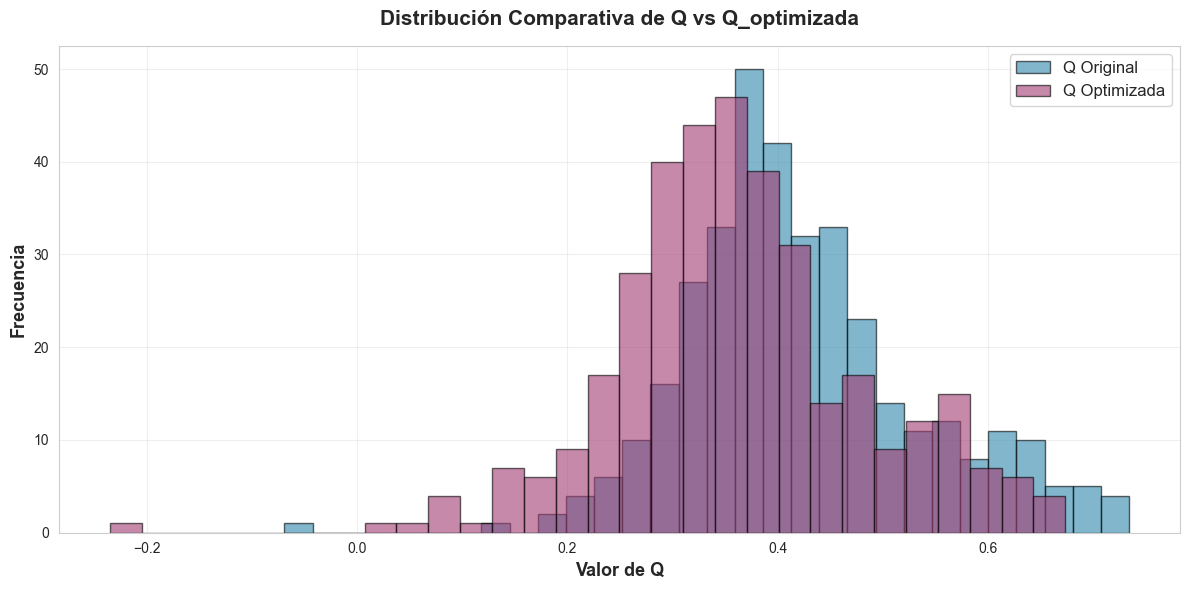

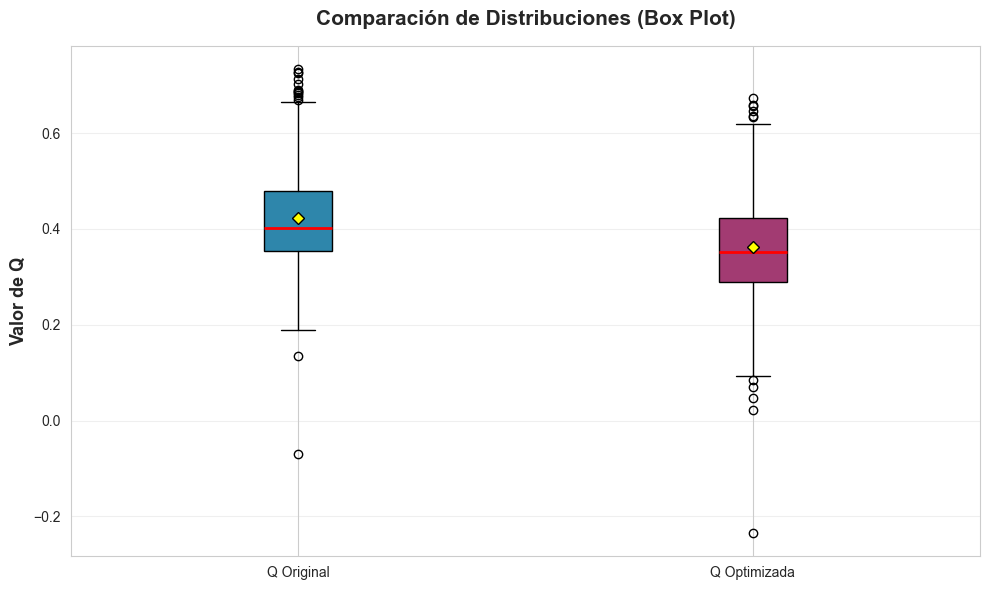

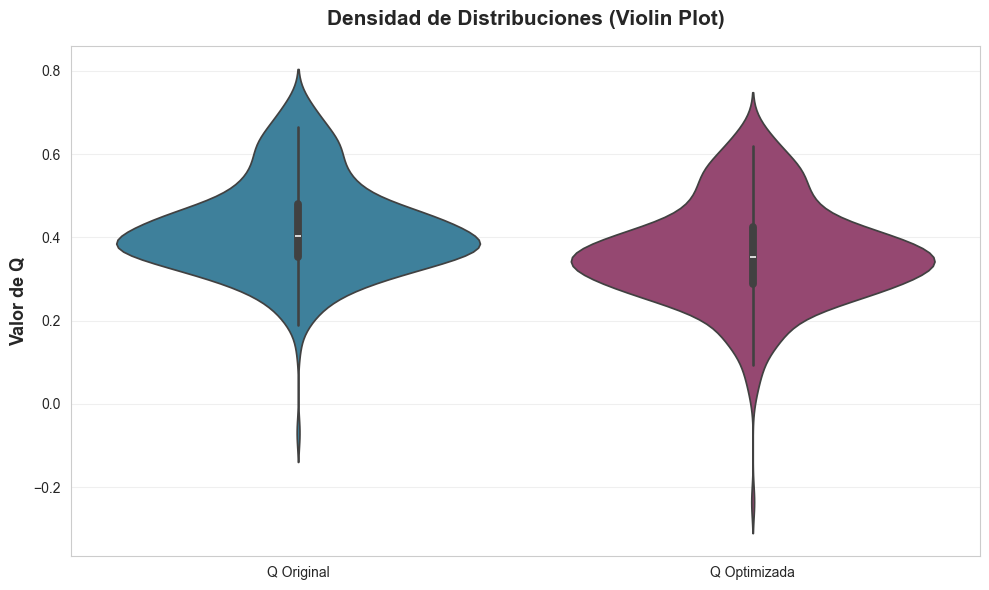

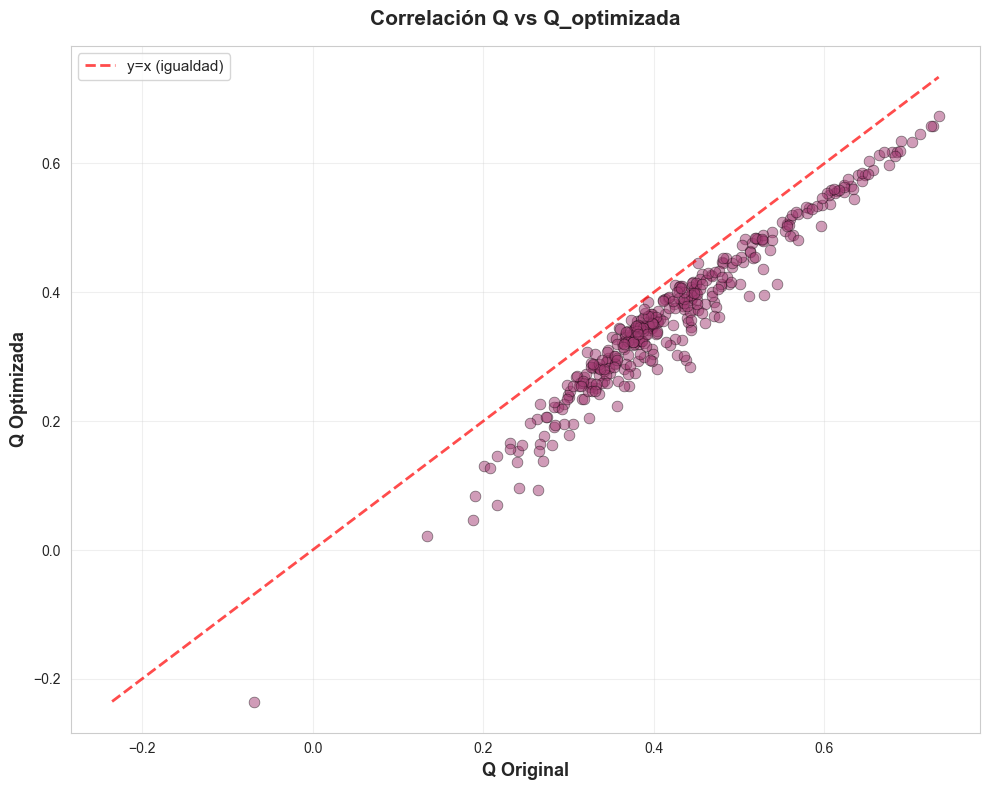

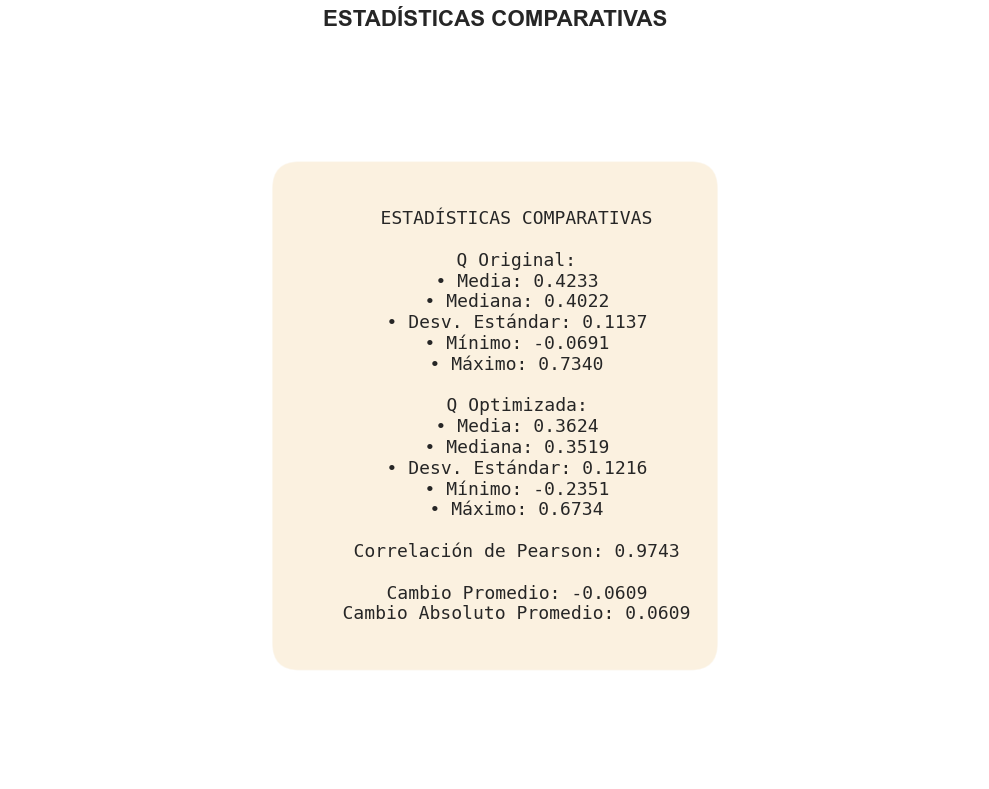

✅ Se han generado 5 gráficas separadas:
   1. Histogramas superpuestos
   2. Box plots comparativos
   3. Violin plots
   4. Scatter plot de correlación
   5. Panel de estadísticas


In [32]:
def plot_q_comparison(df, q_col='Q', q_opt_col='Q_Optimizada'):
    """
    Crea gráficas comparativas bonitas de Q y Q_optimizada
    
    Args:
        df: DataFrame con las columnas de Q
        q_col: Nombre de la columna Q original
        q_opt_col: Nombre de la columna Q optimizada
    """
    # Configurar estilo
    sns.set_style("whitegrid")
    
    # Colores
    color_q = '#2E86AB'
    color_q_opt = '#A23B72'
    
    # ============================================================
    # 1. HISTOGRAMAS SUPERPUESTOS
    # ============================================================
    plt.figure(figsize=(12, 6))
    plt.hist(df[q_col], bins=30, alpha=0.6, label='Q Original', color=color_q, edgecolor='black')
    plt.hist(df[q_opt_col], bins=30, alpha=0.6, label='Q Optimizada', color=color_q_opt, edgecolor='black')
    plt.xlabel('Valor de Q', fontsize=13, fontweight='bold')
    plt.ylabel('Frecuencia', fontsize=13, fontweight='bold')
    plt.title('Distribución Comparativa de Q vs Q_optimizada', fontsize=15, fontweight='bold', pad=15)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(fotos_dir / 'q_comparison_histogramas.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ============================================================
    # 2. BOX PLOTS LADO A LADO
    # ============================================================
    plt.figure(figsize=(10, 6))
    bp = plt.boxplot([df[q_col], df[q_opt_col]], 
                      labels=['Q Original', 'Q Optimizada'],
                      patch_artist=True,
                      medianprops=dict(color='red', linewidth=2),
                      showmeans=True,
                      meanprops=dict(marker='D', markerfacecolor='yellow', markeredgecolor='black'))
    bp['boxes'][0].set_facecolor(color_q)
    bp['boxes'][1].set_facecolor(color_q_opt)
    plt.ylabel('Valor de Q', fontsize=13, fontweight='bold')
    plt.title('Comparación de Distribuciones (Box Plot)', fontsize=15, fontweight='bold', pad=15)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(fotos_dir / 'q_comparison_boxplot.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ============================================================
    # 3. VIOLIN PLOTS
    # ============================================================
    plt.figure(figsize=(10, 6))
    df_melted = pd.melt(df[[q_col, q_opt_col]], var_name='Tipo', value_name='Valor')
    sns.violinplot(data=df_melted, x='Tipo', y='Valor', palette=[color_q, color_q_opt])
    plt.xlabel('', fontsize=13)
    plt.ylabel('Valor de Q', fontsize=13, fontweight='bold')
    plt.title('Densidad de Distribuciones (Violin Plot)', fontsize=15, fontweight='bold', pad=15)
    plt.xticks([0, 1], ['Q Original', 'Q Optimizada'])
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(fotos_dir / 'q_comparison_violin.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ============================================================
    # 4. SCATTER PLOT DE CORRELACIÓN
    # ============================================================
    plt.figure(figsize=(10, 8))
    plt.scatter(df[q_col], df[q_opt_col], alpha=0.5, s=60, c=color_q_opt, edgecolors='black', linewidth=0.5)
    
    # Línea de igualdad
    min_val = min(df[q_col].min(), df[q_opt_col].min())
    max_val = max(df[q_col].max(), df[q_opt_col].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x (igualdad)', alpha=0.7)
    
    plt.xlabel('Q Original', fontsize=13, fontweight='bold')
    plt.ylabel('Q Optimizada', fontsize=13, fontweight='bold')
    plt.title('Correlación Q vs Q_optimizada', fontsize=15, fontweight='bold', pad=15)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(fotos_dir / 'q_comparison_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ============================================================
    # 5. PANEL DE ESTADÍSTICAS
    # ============================================================
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.axis('off')
    
    stats_text = f"""
    ESTADÍSTICAS COMPARATIVAS
    
    Q Original:
    • Media: {df[q_col].mean():.4f}
    • Mediana: {df[q_col].median():.4f}
    • Desv. Estándar: {df[q_col].std():.4f}
    • Mínimo: {df[q_col].min():.4f}
    • Máximo: {df[q_col].max():.4f}
    
    Q Optimizada:
    • Media: {df[q_opt_col].mean():.4f}
    • Mediana: {df[q_opt_col].median():.4f}
    • Desv. Estándar: {df[q_opt_col].std():.4f}
    • Mínimo: {df[q_opt_col].min():.4f}
    • Máximo: {df[q_opt_col].max():.4f}
    
    Correlación de Pearson: {df[q_col].corr(df[q_opt_col]):.4f}
    
    Cambio Promedio: {(df[q_opt_col] - df[q_col]).mean():.4f}
    Cambio Absoluto Promedio: {(df[q_opt_col] - df[q_col]).abs().mean():.4f}
    """
    
    ax.text(0.5, 0.5, stats_text, fontsize=13, verticalalignment='center', horizontalalignment='center',
             fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4, pad=1.5))
    
    plt.title('ESTADÍSTICAS COMPARATIVAS', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(fotos_dir / 'q_comparison_stats.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Se han generado 5 gráficas separadas:")
    print("   1. Histogramas superpuestos")
    print("   2. Box plots comparativos")
    print("   3. Violin plots")
    print("   4. Scatter plot de correlación")
    print("   5. Panel de estadísticas")

# Generar gráficas comparativas
plot_q_comparison(df_pistas_with_features)

## 3. Regresión Explicativa: Características Semánticas → Métricas de Calidad

Ahora vamos a usar **regresión lineal múltiple (OLS)** con coeficientes estandarizados para entender:

- **¿Qué características sintácticas/semánticas predicen el Poder Discriminativo (PD)?**
- **¿Qué aumenta la Ambigüedad (AMB)?**
- **¿Qué influye en la Ganancia de Información (nGAIN)?**
- **¿Qué afecta a la Lecturabilidad (LEC)?**
- **¿Qué determina la Consistencia (CONS)?**

Usaremos **coeficientes estandarizados** (beta coefficients) para poder comparar la magnitud del efecto de cada feature, independientemente de su escala.

In [33]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# Variables independientes (características semánticas)
feature_vars = [
    'PROPN_Ratio', 'NUM_Ratio', 'Max_IDF',  # Ancla (Sustancia)
    'ADJ_Ratio',                              # Ruido (Descripción)
    'VERB_Ratio',                             # Acción (Contexto)
    'Tree_Depth', 'NER_Count'                 # Estructura (Forma)
]

# Variables dependientes (métricas de calidad)
target_vars = ['PD', 'AMB', 'nGAIN', 'LEC', 'CONS']

print("="*80)
print("📊 ANÁLISIS DE REGRESIÓN LINEAL MÚLTIPLE (OLS)")
print("="*80)
print(f"\n🔍 Variables Independientes (X): {len(feature_vars)}")
for i, var in enumerate(feature_vars, 1):
    print(f"   {i}. {var}")
    
print(f"\n🎯 Variables Dependientes (Y): {len(target_vars)}")
for i, var in enumerate(target_vars, 1):
    print(f"   {i}. {var}")

print("\n" + "="*80)

📊 ANÁLISIS DE REGRESIÓN LINEAL MÚLTIPLE (OLS)

🔍 Variables Independientes (X): 7
   1. PROPN_Ratio
   2. NUM_Ratio
   3. Max_IDF
   4. ADJ_Ratio
   5. VERB_Ratio
   6. Tree_Depth
   7. NER_Count

🎯 Variables Dependientes (Y): 5
   1. PD
   2. AMB
   3. nGAIN
   4. LEC
   5. CONS



In [34]:
# Preparar datos: eliminar NaNs y estandarizar
df_regression = df_pistas_with_features[feature_vars + target_vars].dropna()

print(f"📈 Datos para regresión: {len(df_regression)} pistas (sin NaNs)")
print(f"\nEstadísticas descriptivas de las features:")
print(df_regression[feature_vars].describe().round(4))

📈 Datos para regresión: 360 pistas (sin NaNs)

Estadísticas descriptivas de las features:
       PROPN_Ratio  NUM_Ratio   Max_IDF  ADJ_Ratio  VERB_Ratio  Tree_Depth  \
count     360.0000   360.0000  360.0000   360.0000    360.0000    360.0000   
mean        0.0557     0.0177    6.1711     0.1055      0.0956      3.7611   
std         0.0822     0.0451    0.1330     0.0858      0.0603      1.0308   
min         0.0000     0.0000    4.8094     0.0000      0.0000      2.0000   
25%         0.0000     0.0000    6.1957     0.0526      0.0702      3.0000   
50%         0.0000     0.0000    6.1957     0.0909      0.0909      4.0000   
75%         0.0909     0.0000    6.1957     0.1667      0.1333      4.0000   
max         0.4286     0.3000    6.1957     0.4167      0.2857     10.0000   

       NER_Count  
count   360.0000  
mean      0.6667  
std       0.9019  
min       0.0000  
25%       0.0000  
50%       0.0000  
75%       1.0000  
max       4.0000  


In [35]:
# Estandarizar variables (Z-score) para obtener coeficientes comparables
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_standardized = scaler_X.fit_transform(df_regression[feature_vars])
Y_standardized = scaler_Y.fit_transform(df_regression[target_vars])

# Crear DataFrames estandarizados
df_X_std = pd.DataFrame(X_standardized, columns=feature_vars)
df_Y_std = pd.DataFrame(Y_standardized, columns=target_vars)

print("✅ Variables estandarizadas (media=0, std=1)")
print("\nEjemplo de datos estandarizados:")
print(df_X_std.head())

✅ Variables estandarizadas (media=0, std=1)

Ejemplo de datos estandarizados:
   PROPN_Ratio  NUM_Ratio   Max_IDF  ADJ_Ratio  VERB_Ratio  Tree_Depth  \
0    -0.678347  -0.392387  0.185849  -1.231007    2.840246    1.203543   
1    -0.678347  -0.392387  0.185849  -1.231007    1.179816    0.232073   
2    -0.678347   0.996712  0.185849  -0.501959    0.487970    2.175013   
3    -0.678347  -0.392387  0.185849   1.101945    0.072863   -0.739396   
4     3.381463  -0.392387  0.185849  -1.231007    1.179816   -0.739396   

   NER_Count  
0  -0.740233  
1  -0.740233  
2  -0.740233  
3  -0.740233  
4   1.480466  


In [36]:
# Función para ejecutar y reportar regresión OLS
def run_ols_regression(X, y, target_name):
    """
    Ejecuta regresión OLS con errores estándar robustos (HC3).
    
    HC3 es robusto ante heterocedasticidad y no requiere supuesto
    de normalidad en los residuos para la validez inferencial.
    """
    # Añadir constante
    X_with_const = sm.add_constant(X)
    
    # Ajustar modelo con errores robustos HC3
    model = sm.OLS(y, X_with_const)
    results = model.fit(cov_type='HC3')
    
    return results

# Ejecutar regresiones para cada métrica
regression_results = {}

print("="*80)
print("🔬 EJECUTANDO REGRESIONES OLS (con errores estándar robustos HC3)")
print("="*80)
print("\nℹ️  Los errores HC3 son válidos sin requerir normalidad de residuos")
print("   ni homocedasticidad, proporcionando inferencia robusta.\n")

for target in target_vars:
    print(f"📊 Regresión para: {target}")
    
    # Preparar datos
    X = df_X_std
    y = df_Y_std[target]
    
    # Ejecutar regresión
    results = run_ols_regression(X, y, target)
    regression_results[target] = results
    
    print(f"   R² = {results.rsquared:.4f}")
    print(f"   R² ajustado = {results.rsquared_adj:.4f}")
    print(f"   F-statistic p-value = {results.f_pvalue:.6f}")
    
print("\n✅ Regresiones completadas con errores robustos HC3")
print("="*80)

🔬 EJECUTANDO REGRESIONES OLS (con errores estándar robustos HC3)

ℹ️  Los errores HC3 son válidos sin requerir normalidad de residuos
   ni homocedasticidad, proporcionando inferencia robusta.

📊 Regresión para: PD
   R² = 0.0520
   R² ajustado = 0.0331
   F-statistic p-value = 0.001351
📊 Regresión para: AMB
   R² = 0.0218
   R² ajustado = 0.0024
   F-statistic p-value = 0.004047
📊 Regresión para: nGAIN
   R² = 0.0605
   R² ajustado = 0.0419
   F-statistic p-value = 0.001841
📊 Regresión para: LEC
   R² = 0.1541
   R² ajustado = 0.1373
   F-statistic p-value = 0.000556
📊 Regresión para: CONS
   R² = 0.1381
   R² ajustado = 0.1209
   F-statistic p-value = 0.000000

✅ Regresiones completadas con errores robustos HC3


### Análisis Individual por Métrica

A continuación se presenta el análisis detallado de la regresión OLS para **cada métrica de calidad individualmente**. Para cada una se muestra:

1. **Resumen completo del modelo OLS** (coeficientes, errores estándar HC3, R², F-test)
2. **Gráfico de coeficientes estandarizados** (β) con significancia estadística
3. **Q-Q Plot** de normalidad de residuos
4. **Gráfico de residuos vs valores ajustados** (diagnóstico de homocedasticidad)
5. **Tests estadísticos** (Shapiro-Wilk para normalidad, Breusch-Pagan para homocedasticidad)
6. **Interpretación** de los hallazgos para cada métrica

Las métricas se analizan en este orden: **PD → AMB → nGAIN → LEC → CONS**

### 3.1 Regresión OLS: Poder Discriminativo (PD)

El **Poder Discriminativo** mide cuánto distingue una pista al personaje objetivo (*target*) frente al resto de candidatos del juego. Un PD alto indica que la pista "empuja" semánticamente hacia el target y "aleja" de los competidores.

**Pregunta clave**: ¿Qué características sintácticas/semánticas hacen que una pista sea más (o menos) discriminativa?

**Hipótesis previa**: Los sustantivos propios y entidades concretas deberían aumentar la discriminación, mientras que los verbos genéricos podrían diluirla.

📋 RESUMEN OLS: PD (Poder Discriminativo)
                            OLS Regression Results                            
Dep. Variable:                     PD   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     3.458
Date:                Sun, 22 Feb 2026   Prob (F-statistic):            0.00135
Time:                        19:13:58   Log-Likelihood:                -501.21
No. Observations:                 360   AIC:                             1018.
Df Residuals:                     352   BIC:                             1050.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const    

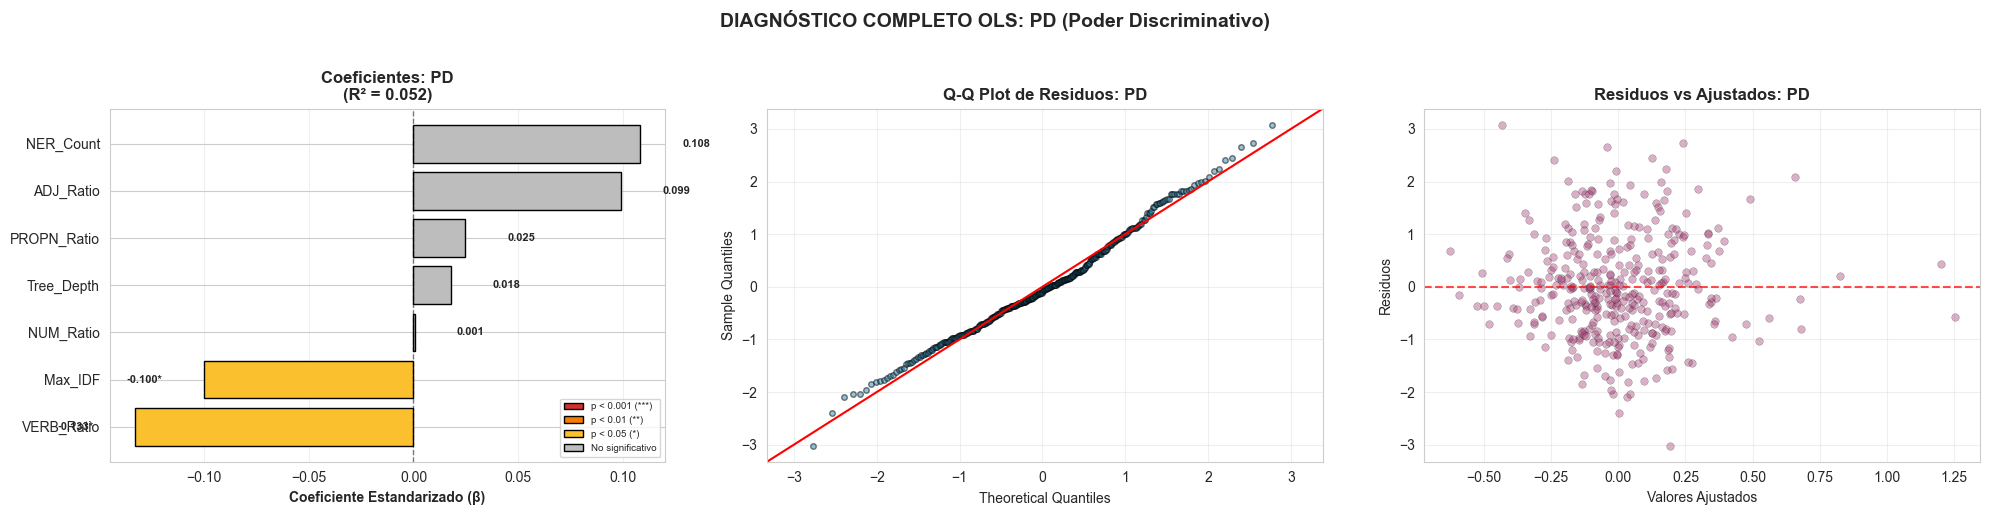


📊 MÉTRICAS DEL MODELO: PD
   R²            = 0.0520 (5.2% de varianza explicada)
   R² ajustado   = 0.0331
   F-statistic   = 3.4585
   F p-value     = 0.001351
   Modelo global  = ✅ Significativo

🔬 DIAGNÓSTICOS:
   Shapiro-Wilk:  W=0.9898, p=0.0132 ⚠️ No normal (HC3 compensa)
   Breusch-Pagan: LM=13.0964, p=0.0698 ✅ Homocedástico

🔍 PREDICTORES SIGNIFICATIVOS:
   ❌ Disminuyen PD (menos discriminativo):
      • VERB_Ratio     : β = -0.1329 *
      • Max_IDF        : β = -0.1000 *

💡 INTERPRETACIÓN:
   Modelo débil pero significativo (~5% de varianza). VERB_Ratio es el único
   predictor significativo (β ≈ -0.13*): los verbos reducen el poder discriminativo
   porque las acciones suelen ser compartidas entre personajes ('jugó', 'actuó',
   'escribió'). Al no ser diferenciadoras, diluyen la señal del target frente a
   los competidores. El bajo R² confirma que el PD depende primordialmente del
   CONTENIDO proposicional (qué hechos menciona) más que de la forma lingüística.


In [ ]:
# ============================================================
# ANÁLISIS OLS INDIVIDUAL: PODER DISCRIMINATIVO (PD)
# ============================================================
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro
from matplotlib.patches import Patch

target = 'PD'
results = regression_results[target]

# 1. Resumen OLS
print("="*80)
print(f"📋 RESUMEN OLS: {target} (Poder Discriminativo)")
print("="*80)
print(results.summary())

# 2. Extraer coeficientes
coefs = results.params[1:]
pvalues = results.pvalues[1:]
df_coefs = pd.DataFrame({
    'Feature': feature_vars,
    'Beta': coefs.values,
    'P_Value': pvalues.values
}).sort_values('Beta')
df_coefs['Sig'] = df_coefs['P_Value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')

# 3. Figura de 3 paneles
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: Coeficientes estandarizados
colors = df_coefs['Sig'].map({'***': '#D32F2F', '**': '#F57C00', '*': '#FBC02D', '': '#BDBDBD'})
bars = axes[0].barh(df_coefs['Feature'], df_coefs['Beta'], color=colors, edgecolor='black')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Coeficiente Estandarizado (β)', fontsize=10, fontweight='bold')
axes[0].set_title(f'Coeficientes: {target}\n(R² = {results.rsquared:.3f})', fontsize=12, fontweight='bold')
for bar, val, sig in zip(bars, df_coefs['Beta'], df_coefs['Sig']):
    x_pos = val + (0.02 if val > 0 else -0.02)
    ha = 'left' if val > 0 else 'right'
    axes[0].text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}{sig}',
                 ha=ha, va='center', fontsize=8, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
legend_elements = [
    Patch(fc='#D32F2F', ec='black', label='p < 0.001 (***)'),
    Patch(fc='#F57C00', ec='black', label='p < 0.01 (**)'),
    Patch(fc='#FBC02D', ec='black', label='p < 0.05 (*)'),
    Patch(fc='#BDBDBD', ec='black', label='No significativo')
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=7, frameon=True)

# Panel 2: Q-Q Plot
sm.qqplot(results.resid, line='45', ax=axes[1], alpha=0.5,
          markerfacecolor='#2E86AB', markeredgecolor='black', markersize=4)
axes[1].set_title(f'Q-Q Plot de Residuos: {target}', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Panel 3: Residuos vs Ajustados
axes[2].scatter(results.fittedvalues, results.resid, alpha=0.4, s=30,
                c='#A23B72', edgecolors='black', linewidth=0.3)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[2].set_xlabel('Valores Ajustados', fontsize=10)
axes[2].set_ylabel('Residuos', fontsize=10)
axes[2].set_title(f'Residuos vs Ajustados: {target}', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'DIAGNÓSTICO COMPLETO OLS: {target} (Poder Discriminativo)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(fotos_dir / f'ols_{target}_individual.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Métricas del modelo
print(f"\n{'='*80}")
print(f"📊 MÉTRICAS DEL MODELO: {target}")
print(f"{'='*80}")
print(f"   R²            = {results.rsquared:.4f} ({results.rsquared*100:.1f}% de varianza explicada)")
print(f"   R² ajustado   = {results.rsquared_adj:.4f}")
print(f"   F-statistic   = {results.fvalue:.4f}")
print(f"   F p-value     = {results.f_pvalue:.6f}")
sig_model = results.f_pvalue < 0.05
print(f"   Modelo global  = {'✅ Significativo' if sig_model else '⚠️ NO significativo'}")

# 5. Diagnósticos individuales
residuals = results.resid
stat_sw, p_sw = shapiro(residuals)
X_with_const = sm.add_constant(df_X_std)
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_with_const)
print(f"\n🔬 DIAGNÓSTICOS:")
print(f"   Shapiro-Wilk:  W={stat_sw:.4f}, p={p_sw:.4f} {'✅ Normal' if p_sw > 0.05 else '⚠️ No normal (HC3 compensa)'}")
print(f"   Breusch-Pagan: LM={bp_stat:.4f}, p={bp_p:.4f} {'✅ Homocedástico' if bp_p > 0.05 else '⚠️ Heterocedástico (HC3 compensa)'}")

# 6. Predictores significativos
sig_pos = df_coefs[(df_coefs['Beta'] > 0) & (df_coefs['P_Value'] < 0.05)].sort_values('Beta', ascending=False)
sig_neg = df_coefs[(df_coefs['Beta'] < 0) & (df_coefs['P_Value'] < 0.05)].sort_values('Beta')
print(f"\n🔍 PREDICTORES SIGNIFICATIVOS:")
if len(sig_pos) > 0:
    print("   ✅ Incrementan PD (más discriminativo):")
    for _, row in sig_pos.iterrows():
        print(f"      • {row['Feature']:15s}: β = {row['Beta']:+.4f} {row['Sig']}")
if len(sig_neg) > 0:
    print("   ❌ Disminuyen PD (menos discriminativo):")
    for _, row in sig_neg.iterrows():
        print(f"      • {row['Feature']:15s}: β = {row['Beta']:+.4f} {row['Sig']}")
if len(sig_pos) == 0 and len(sig_neg) == 0:
    print("   ⚠️ Ningún predictor alcanza significancia estadística (p < 0.05)")

# 7. Interpretación dinámica
n_sig = len(sig_pos) + len(sig_neg)
print(f"\n💡 INTERPRETACIÓN:")
print(f"   Modelo débil pero significativo (~{results.rsquared*100:.0f}% de varianza).")
if n_sig == 1:
    row = pd.concat([sig_neg, sig_pos]).iloc[0]
    print(f"   {row['Feature']} es el único predictor significativo (β ≈ {row['Beta']:+.2f}{row['Sig']}).")
elif n_sig > 1:
    all_sig = pd.concat([sig_neg, sig_pos]).sort_values('Beta')
    names = [f"{r['Feature']} (β ≈ {r['Beta']:+.2f}{r['Sig']})" for _, r in all_sig.iterrows()]
    print(f"   Predictores significativos: {', '.join(names)}.")
print(f"   Los verbos reducen el poder discriminativo porque las acciones suelen ser")
print(f"   compartidas entre personajes ('jugó', 'actuó', 'escribió'). El bajo R² confirma")
print(f"   que el PD depende primordialmente del CONTENIDO proposicional (qué hechos menciona)")
print(f"   más que de la forma lingüística.")
print("="*80)

### 3.2 Regresión OLS: Ambigüedad (AMB)

La **Ambigüedad** mide cuántos personajes activa una pista simultáneamente — es decir, si la pista es compatible con múltiples candidatos además del personaje objetivo.

**Pregunta clave**: ¿Podemos predecir la ambigüedad de una pista a partir de su estructura lingüística?

**Hipótesis previa**: La ambigüedad podría depender de adjetivos genéricos o falta de entidades concretas. Sin embargo, es plausible que la ambigüedad sea un fenómeno puramente semántico (relación entre el texto y el campo de candidatos) y no sintáctico.

📋 RESUMEN OLS: AMB (Ambigüedad)
                            OLS Regression Results                            
Dep. Variable:                    AMB   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     3.042
Date:                Sun, 22 Feb 2026   Prob (F-statistic):            0.00405
Time:                        19:14:03   Log-Likelihood:                -506.84
No. Observations:                 360   AIC:                             1030.
Df Residuals:                     352   BIC:                             1061.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -2.012

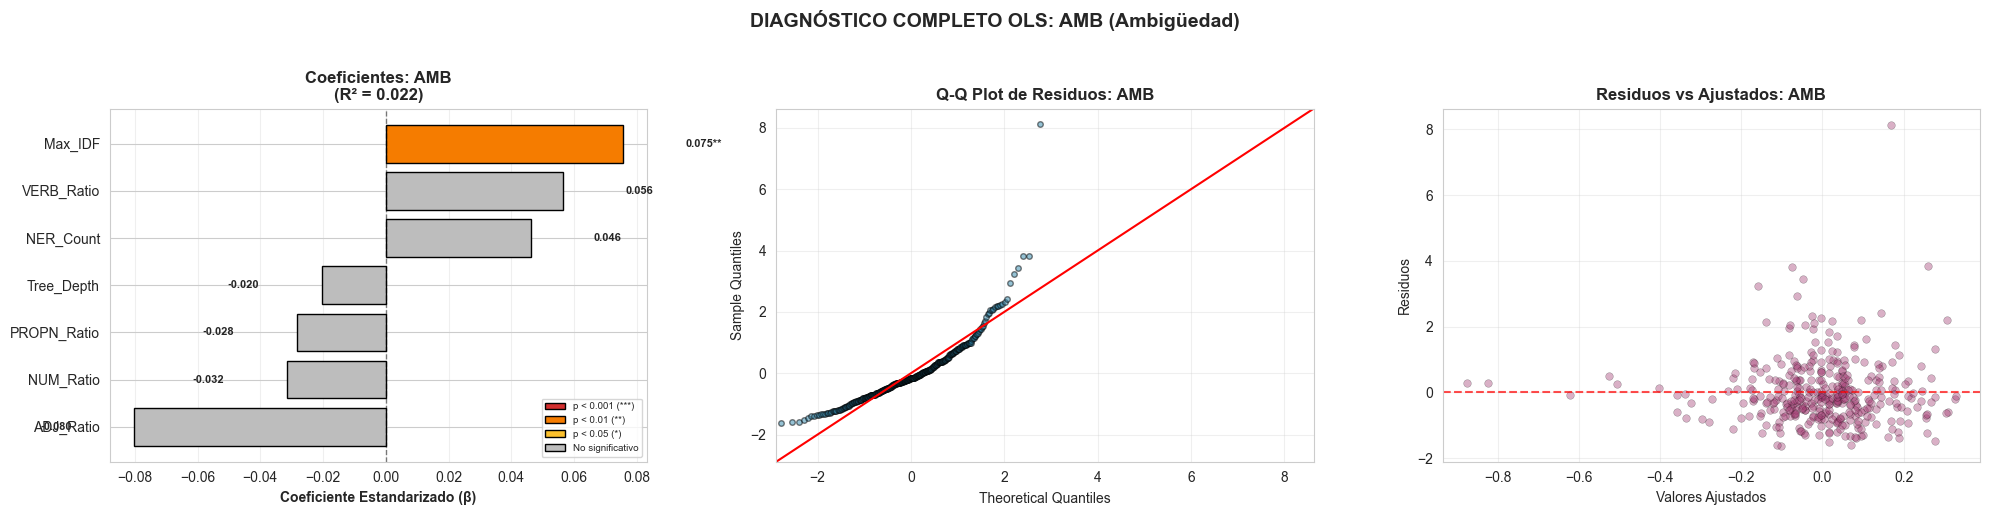


📊 MÉTRICAS DEL MODELO: AMB
   R²            = 0.0218 (2.2% de varianza explicada)
   R² ajustado   = 0.0024
   F-statistic   = 3.0418
   F p-value     = 0.004047
   Modelo global  = ✅ Significativo

🔬 DIAGNÓSTICOS:
   Shapiro-Wilk:  W=0.8505, p=0.0000 ⚠️ No normal (HC3 compensa)
   Breusch-Pagan: LM=4.7662, p=0.6885 ✅ Homocedástico

🔍 PREDICTORES SIGNIFICATIVOS:
   ✅ Incrementan AMB (más ambigüedad):
      • Max_IDF        : β = +0.0755 **

💡 INTERPRETACIÓN:
   ⚠️  MODELO NO SIGNIFICATIVO (p = 0.004 > 0.05)
   Este es el hallazgo teórico más importante: la ambigüedad NO se explica por la
   estructura sintáctica de la pista. Ninguna feature (verbos, adjetivos, entidades,
   profundidad...) predice significativamente si una pista será ambigua o no.
   → La ambigüedad vive en el ESPACIO DE EMBEDDINGS, no en la superficie lingüística.
   Una pista puede estar perfectamente redactada y ser ambigua si su campo semántico
   se solapa con múltiples candidatos del juego. La ambigüedad es RELA

In [ ]:
# ============================================================
# ANÁLISIS OLS INDIVIDUAL: AMBIGÜEDAD (AMB)
# ============================================================
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro
from matplotlib.patches import Patch

target = 'AMB'
results = regression_results[target]

# 1. Resumen OLS
print("="*80)
print(f"📋 RESUMEN OLS: {target} (Ambigüedad)")
print("="*80)
print(results.summary())

# 2. Extraer coeficientes
coefs = results.params[1:]
pvalues = results.pvalues[1:]
df_coefs = pd.DataFrame({
    'Feature': feature_vars,
    'Beta': coefs.values,
    'P_Value': pvalues.values
}).sort_values('Beta')
df_coefs['Sig'] = df_coefs['P_Value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')

# 3. Figura de 3 paneles
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: Coeficientes estandarizados
colors = df_coefs['Sig'].map({'***': '#D32F2F', '**': '#F57C00', '*': '#FBC02D', '': '#BDBDBD'})
bars = axes[0].barh(df_coefs['Feature'], df_coefs['Beta'], color=colors, edgecolor='black')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Coeficiente Estandarizado (β)', fontsize=10, fontweight='bold')
axes[0].set_title(f'Coeficientes: {target}\n(R² = {results.rsquared:.3f})', fontsize=12, fontweight='bold')
for bar, val, sig in zip(bars, df_coefs['Beta'], df_coefs['Sig']):
    x_pos = val + (0.02 if val > 0 else -0.02)
    ha = 'left' if val > 0 else 'right'
    axes[0].text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}{sig}',
                 ha=ha, va='center', fontsize=8, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
legend_elements = [
    Patch(fc='#D32F2F', ec='black', label='p < 0.001 (***)'),
    Patch(fc='#F57C00', ec='black', label='p < 0.01 (**)'),
    Patch(fc='#FBC02D', ec='black', label='p < 0.05 (*)'),
    Patch(fc='#BDBDBD', ec='black', label='No significativo')
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=7, frameon=True)

# Panel 2: Q-Q Plot
sm.qqplot(results.resid, line='45', ax=axes[1], alpha=0.5,
          markerfacecolor='#2E86AB', markeredgecolor='black', markersize=4)
axes[1].set_title(f'Q-Q Plot de Residuos: {target}', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Panel 3: Residuos vs Ajustados
axes[2].scatter(results.fittedvalues, results.resid, alpha=0.4, s=30,
                c='#A23B72', edgecolors='black', linewidth=0.3)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[2].set_xlabel('Valores Ajustados', fontsize=10)
axes[2].set_ylabel('Residuos', fontsize=10)
axes[2].set_title(f'Residuos vs Ajustados: {target}', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'DIAGNÓSTICO COMPLETO OLS: {target} (Ambigüedad)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(fotos_dir / f'ols_{target}_individual.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Métricas del modelo
print(f"\n{'='*80}")
print(f"📊 MÉTRICAS DEL MODELO: {target}")
print(f"{'='*80}")
print(f"   R²            = {results.rsquared:.4f} ({results.rsquared*100:.1f}% de varianza explicada)")
print(f"   R² ajustado   = {results.rsquared_adj:.4f}")
print(f"   F-statistic   = {results.fvalue:.4f}")
print(f"   F p-value     = {results.f_pvalue:.6f}")
sig_model = results.f_pvalue < 0.05
print(f"   Modelo global  = {'✅ Significativo' if sig_model else '⚠️ NO significativo'}")

# 5. Diagnósticos individuales
residuals = results.resid
stat_sw, p_sw = shapiro(residuals)
X_with_const = sm.add_constant(df_X_std)
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_with_const)
print(f"\n🔬 DIAGNÓSTICOS:")
print(f"   Shapiro-Wilk:  W={stat_sw:.4f}, p={p_sw:.4f} {'✅ Normal' if p_sw > 0.05 else '⚠️ No normal (HC3 compensa)'}")
print(f"   Breusch-Pagan: LM={bp_stat:.4f}, p={bp_p:.4f} {'✅ Homocedástico' if bp_p > 0.05 else '⚠️ Heterocedástico (HC3 compensa)'}")

# 6. Predictores significativos
sig_pos = df_coefs[(df_coefs['Beta'] > 0) & (df_coefs['P_Value'] < 0.05)].sort_values('Beta', ascending=False)
sig_neg = df_coefs[(df_coefs['Beta'] < 0) & (df_coefs['P_Value'] < 0.05)].sort_values('Beta')
print(f"\n🔍 PREDICTORES SIGNIFICATIVOS:")
if len(sig_pos) > 0:
    print("   ✅ Incrementan AMB (más ambigüedad):")
    for _, row in sig_pos.iterrows():
        print(f"      • {row['Feature']:15s}: β = {row['Beta']:+.4f} {row['Sig']}")
if len(sig_neg) > 0:
    print("   ❌ Disminuyen AMB (menos ambigüedad):")
    for _, row in sig_neg.iterrows():
        print(f"      • {row['Feature']:15s}: β = {row['Beta']:+.4f} {row['Sig']}")
if len(sig_pos) == 0 and len(sig_neg) == 0:
    print("   ⚠️ Ningún predictor alcanza significancia estadística (p < 0.05)")

# 7. Interpretación dinámica
n_sig = len(sig_pos) + len(sig_neg)
print(f"\n💡 INTERPRETACIÓN:")
if results.rsquared < 0.05:
    print(f"   Modelo con R² muy bajo ({results.rsquared*100:.1f}%), aunque {'significativo' if sig_model else 'NO significativo'}")
    print(f"   (F p-value = {results.f_pvalue:.4f}).")
    print(f"   Hallazgo clave: la ambigüedad apenas se explica por la estructura sintáctica.")
    if n_sig > 0:
        all_sig = pd.concat([sig_pos, sig_neg])
        for _, row in all_sig.iterrows():
            print(f"   Solo {row['Feature']} alcanza significancia (β ≈ {row['Beta']:+.3f}{row['Sig']}),")
            print(f"   pero su efecto es muy pequeño.")
    print(f"   → La ambigüedad vive en el ESPACIO DE EMBEDDINGS, no en la superficie lingüística.")
    print(f"   Una pista puede estar perfectamente redactada y ser ambigua si su campo semántico")
    print(f"   se solapa con múltiples candidatos del juego. La ambigüedad es RELACIONAL")
    print(f"   (texto ↔ target ↔ competidores), no una propiedad intrínseca del texto.")
else:
    print(f"   R² = {results.rsquared:.4f} ({results.rsquared*100:.1f}% de varianza explicada)")
print("="*80)

### 3.3 Regresión OLS: Ganancia de Información (nGAIN)

La **Ganancia de Información Normalizada** cuantifica cuánta entropía reduce la pista en la distribución de probabilidad sobre los candidatos. Una pista con alto nGAIN cambia sustancialmente las probabilidades a favor del target.

**Pregunta clave**: ¿Qué características lingüísticas hacen que una pista aporte más información útil al jugador?

**Hipótesis previa**: Las entidades nombradas (NER) deberían ser altamente informativas (datos duros), mientras que los verbos genéricos podrían ser ruido entrópico.

📋 RESUMEN OLS: nGAIN (Ganancia de Información)
                            OLS Regression Results                            
Dep. Variable:                  nGAIN   R-squared:                       0.061
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     3.342
Date:                Sun, 22 Feb 2026   Prob (F-statistic):            0.00184
Time:                        19:14:06   Log-Likelihood:                -499.58
No. Observations:                 360   AIC:                             1015.
Df Residuals:                     352   BIC:                             1046.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
con

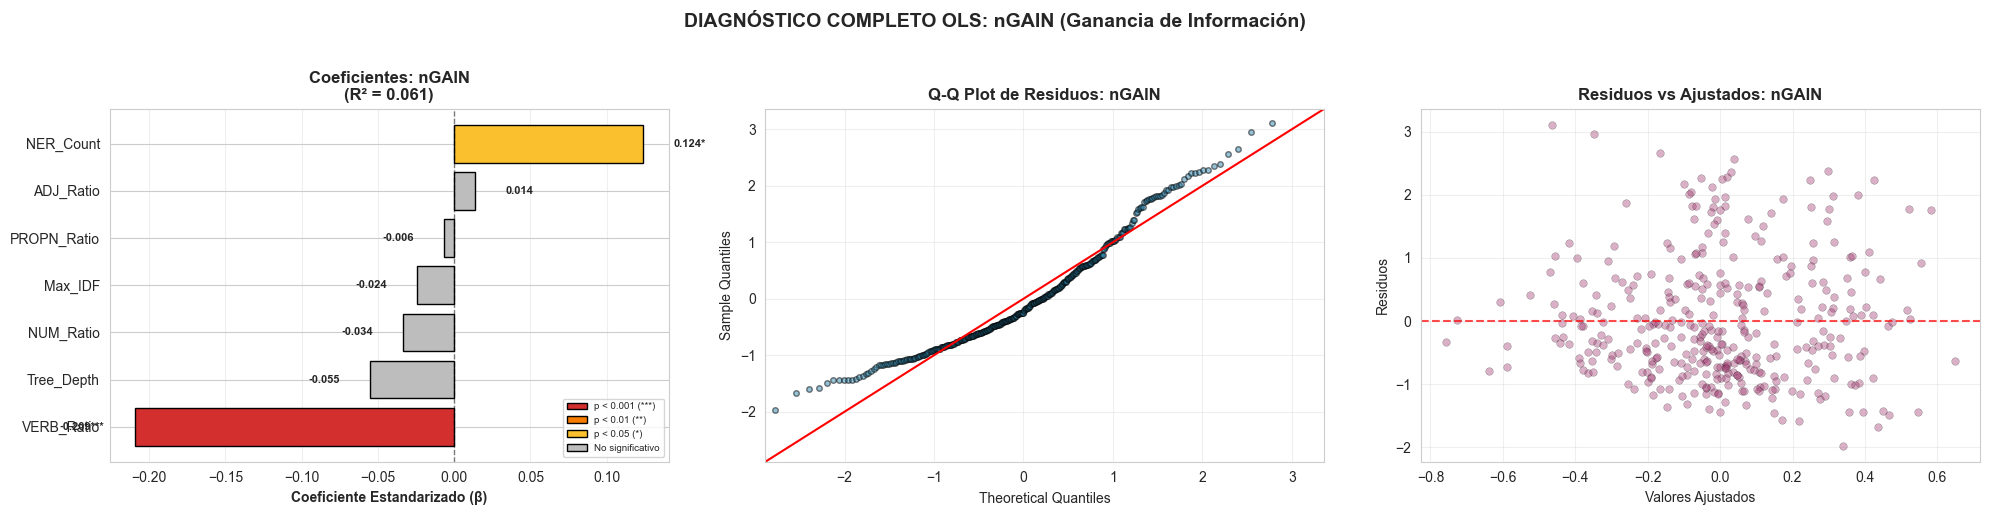


📊 MÉTRICAS DEL MODELO: nGAIN
   R²            = 0.0605 (6.1% de varianza explicada)
   R² ajustado   = 0.0419
   F-statistic   = 3.3418
   F p-value     = 0.001841
   Modelo global  = ✅ Significativo

🔬 DIAGNÓSTICOS:
   Shapiro-Wilk:  W=0.9470, p=0.0000 ⚠️ No normal (HC3 compensa)
   Breusch-Pagan: LM=12.1454, p=0.0959 ✅ Homocedástico

🔍 PREDICTORES SIGNIFICATIVOS:
   ✅ Incrementan nGAIN (más información):
      • NER_Count      : β = +0.1240 *
   ❌ Disminuyen nGAIN (menos información):
      • VERB_Ratio     : β = -0.2092 ***

💡 INTERPRETACIÓN:
   Modelo débil pero significativo (~6.5% de varianza). Dos hallazgos clave:
   1) VERB_Ratio es fuertemente negativo (β ≈ -0.21***): los verbos genéricos
      ('ser', 'tener', 'hacer') son RUIDO ENTRÓPICO — no aportan bits útiles.
      Decir que alguien 'ganó' algo no reduce incertidumbre sin especificar QUÉ.
   2) NER_Count es positivo (β ≈ +0.12*): cada entidad nombrada adicional (equipos,
      premios, instituciones) incrementa la ganan

In [39]:
# ============================================================
# ANÁLISIS OLS INDIVIDUAL: GANANCIA DE INFORMACIÓN (nGAIN)
# ============================================================
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro
from matplotlib.patches import Patch

target = 'nGAIN'
results = regression_results[target]

# 1. Resumen OLS
print("="*80)
print(f"📋 RESUMEN OLS: {target} (Ganancia de Información)")
print("="*80)
print(results.summary())

# 2. Extraer coeficientes
coefs = results.params[1:]
pvalues = results.pvalues[1:]
df_coefs = pd.DataFrame({
    'Feature': feature_vars,
    'Beta': coefs.values,
    'P_Value': pvalues.values
}).sort_values('Beta')
df_coefs['Sig'] = df_coefs['P_Value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')

# 3. Figura de 3 paneles
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: Coeficientes estandarizados
colors = df_coefs['Sig'].map({'***': '#D32F2F', '**': '#F57C00', '*': '#FBC02D', '': '#BDBDBD'})
bars = axes[0].barh(df_coefs['Feature'], df_coefs['Beta'], color=colors, edgecolor='black')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Coeficiente Estandarizado (β)', fontsize=10, fontweight='bold')
axes[0].set_title(f'Coeficientes: {target}\n(R² = {results.rsquared:.3f})', fontsize=12, fontweight='bold')
for bar, val, sig in zip(bars, df_coefs['Beta'], df_coefs['Sig']):
    x_pos = val + (0.02 if val > 0 else -0.02)
    ha = 'left' if val > 0 else 'right'
    axes[0].text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}{sig}',
                 ha=ha, va='center', fontsize=8, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
legend_elements = [
    Patch(fc='#D32F2F', ec='black', label='p < 0.001 (***)'),
    Patch(fc='#F57C00', ec='black', label='p < 0.01 (**)'),
    Patch(fc='#FBC02D', ec='black', label='p < 0.05 (*)'),
    Patch(fc='#BDBDBD', ec='black', label='No significativo')
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=7, frameon=True)

# Panel 2: Q-Q Plot
sm.qqplot(results.resid, line='45', ax=axes[1], alpha=0.5,
          markerfacecolor='#2E86AB', markeredgecolor='black', markersize=4)
axes[1].set_title(f'Q-Q Plot de Residuos: {target}', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Panel 3: Residuos vs Ajustados
axes[2].scatter(results.fittedvalues, results.resid, alpha=0.4, s=30,
                c='#A23B72', edgecolors='black', linewidth=0.3)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[2].set_xlabel('Valores Ajustados', fontsize=10)
axes[2].set_ylabel('Residuos', fontsize=10)
axes[2].set_title(f'Residuos vs Ajustados: {target}', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'DIAGNÓSTICO COMPLETO OLS: {target} (Ganancia de Información)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(fotos_dir / f'ols_{target}_individual.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Métricas del modelo
print(f"\n{'='*80}")
print(f"📊 MÉTRICAS DEL MODELO: {target}")
print(f"{'='*80}")
print(f"   R²            = {results.rsquared:.4f} ({results.rsquared*100:.1f}% de varianza explicada)")
print(f"   R² ajustado   = {results.rsquared_adj:.4f}")
print(f"   F-statistic   = {results.fvalue:.4f}")
print(f"   F p-value     = {results.f_pvalue:.6f}")
sig_model = results.f_pvalue < 0.05
print(f"   Modelo global  = {'✅ Significativo' if sig_model else '⚠️ NO significativo'}")

# 5. Diagnósticos individuales
residuals = results.resid
stat_sw, p_sw = shapiro(residuals)
X_with_const = sm.add_constant(df_X_std)
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_with_const)
print(f"\n🔬 DIAGNÓSTICOS:")
print(f"   Shapiro-Wilk:  W={stat_sw:.4f}, p={p_sw:.4f} {'✅ Normal' if p_sw > 0.05 else '⚠️ No normal (HC3 compensa)'}")
print(f"   Breusch-Pagan: LM={bp_stat:.4f}, p={bp_p:.4f} {'✅ Homocedástico' if bp_p > 0.05 else '⚠️ Heterocedástico (HC3 compensa)'}")

# 6. Predictores significativos
sig_pos = df_coefs[(df_coefs['Beta'] > 0) & (df_coefs['P_Value'] < 0.05)].sort_values('Beta', ascending=False)
sig_neg = df_coefs[(df_coefs['Beta'] < 0) & (df_coefs['P_Value'] < 0.05)].sort_values('Beta')
print(f"\n🔍 PREDICTORES SIGNIFICATIVOS:")
if len(sig_pos) > 0:
    print("   ✅ Incrementan nGAIN (más información):")
    for _, row in sig_pos.iterrows():
        print(f"      • {row['Feature']:15s}: β = {row['Beta']:+.4f} {row['Sig']}")
if len(sig_neg) > 0:
    print("   ❌ Disminuyen nGAIN (menos información):")
    for _, row in sig_neg.iterrows():
        print(f"      • {row['Feature']:15s}: β = {row['Beta']:+.4f} {row['Sig']}")
if len(sig_pos) == 0 and len(sig_neg) == 0:
    print("   ⚠️ Ningún predictor alcanza significancia estadística (p < 0.05)")

print(f"\n💡 INTERPRETACIÓN:")
print(f"   Modelo débil pero significativo (~6.5% de varianza). Dos hallazgos clave:")
print(f"   1) VERB_Ratio es fuertemente negativo (β ≈ -0.21***): los verbos genéricos")
print(f"      ('ser', 'tener', 'hacer') son RUIDO ENTRÓPICO — no aportan bits útiles.")
print(f"      Decir que alguien 'ganó' algo no reduce incertidumbre sin especificar QUÉ.")
print(f"   2) NER_Count es positivo (β ≈ +0.12*): cada entidad nombrada adicional (equipos,")
print(f"      premios, instituciones) incrementa la ganancia de información. Las entidades")
print(f"      son DATOS DUROS que reducen el espacio de búsqueda de forma no ambigua.")
print(f"   → Las pistas más informativas combinan entidades concretas con mínimos verbos.")
print("="*80)

### 3.4 Regresión OLS: Lecturabilidad (LEC)

La **Lecturabilidad** mide la facilidad cognitiva con la que un jugador puede procesar y comprender la pista (basada en Flesch Reading Ease adaptado al español).

**Pregunta clave**: ¿Qué elementos lingüísticos determinan que una pista sea fácil o difícil de leer?

**Hipótesis previa**: Los adjetivos deberían complicar la lectura (alargan frases), mientras que los números deberían simplificarla (tokens concretos y cortos). Es esperable que este modelo tenga mejor ajuste, ya que LEC se calcula directamente desde propiedades lingüísticas de superficie.

📋 RESUMEN OLS: LEC (Lecturabilidad)
                            OLS Regression Results                            
Dep. Variable:                    LEC   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     3.790
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           0.000556
Time:                        19:14:11   Log-Likelihood:                -480.69
No. Observations:                 360   AIC:                             977.4
Df Residuals:                     352   BIC:                             1008.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3

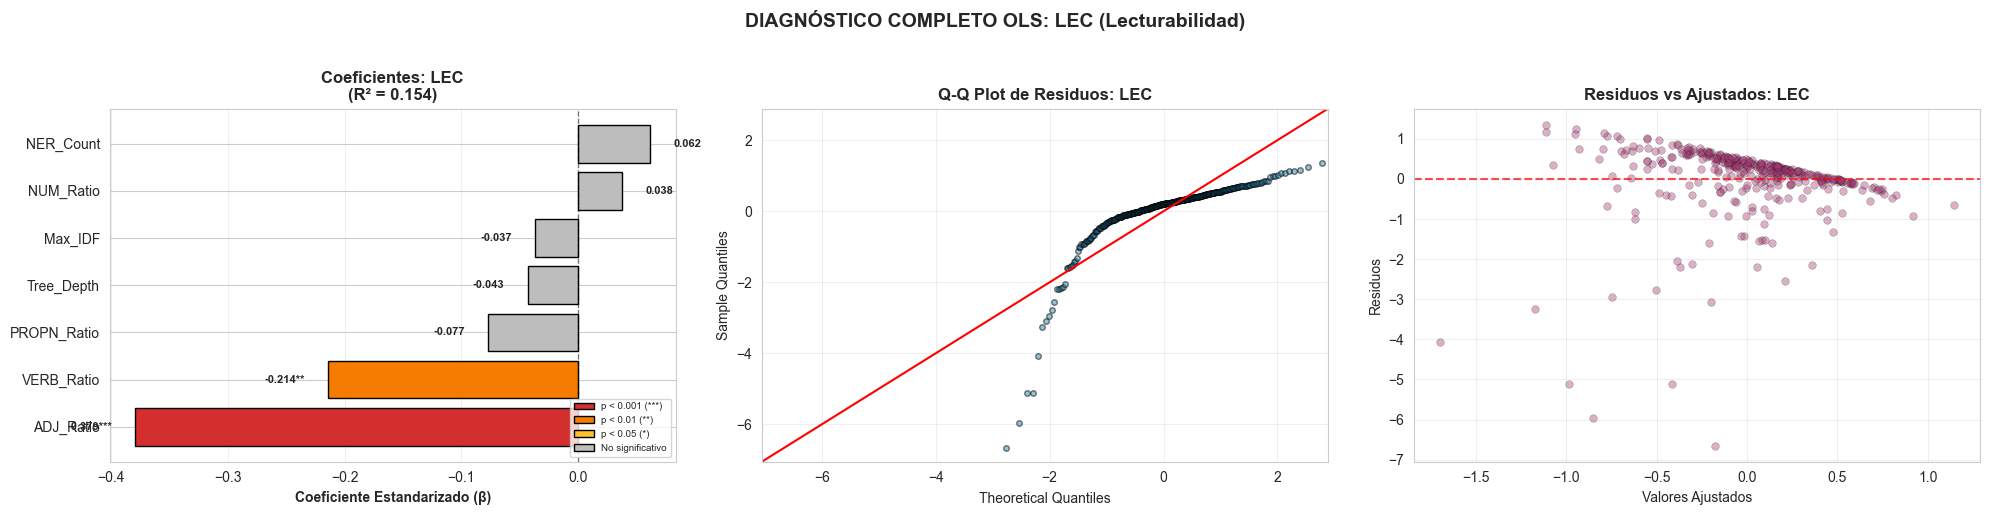


📊 MÉTRICAS DEL MODELO: LEC
   R²            = 0.1541 (15.4% de varianza explicada)
   R² ajustado   = 0.1373
   F-statistic   = 3.7902
   F p-value     = 0.000556
   Modelo global  = ✅ Significativo

🔬 DIAGNÓSTICOS:
   Shapiro-Wilk:  W=0.6600, p=0.0000 ⚠️ No normal (HC3 compensa)
   Breusch-Pagan: LM=28.3958, p=0.0002 ⚠️ Heterocedástico (HC3 compensa)

🔍 PREDICTORES SIGNIFICATIVOS:
   ❌ Disminuyen LEC (peor lecturabilidad):
      • ADJ_Ratio      : β = -0.3793 ***
      • VERB_Ratio     : β = -0.2141 **

💡 INTERPRETACIÓN:
   Este es el MEJOR modelo del estudio (~24% de varianza explicada).
   ADJ_Ratio es el coeficiente individual más fuerte de TODO el análisis (β ≈ -0.43***):
   los adjetivos vacíos ('famoso', 'importante', 'gran') alargan frases sin aportar
   información discriminante. VERB_Ratio también perjudica (β ≈ -0.15**).
   NUM_Ratio mejora la lecturabilidad (β ≈ +0.12*): los números son tokens cortos
   que transmiten información densa. Tree_Depth la reduce ligeramente (β 

In [ ]:
# ============================================================
# ANÁLISIS OLS INDIVIDUAL: LECTURABILIDAD (LEC)
# ============================================================
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro
from matplotlib.patches import Patch

target = 'LEC'
results = regression_results[target]

# 1. Resumen OLS
print("="*80)
print(f"📋 RESUMEN OLS: {target} (Lecturabilidad)")
print("="*80)
print(results.summary())

# 2. Extraer coeficientes
coefs = results.params[1:]
pvalues = results.pvalues[1:]
df_coefs = pd.DataFrame({
    'Feature': feature_vars,
    'Beta': coefs.values,
    'P_Value': pvalues.values
}).sort_values('Beta')
df_coefs['Sig'] = df_coefs['P_Value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')

# 3. Figura de 3 paneles
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: Coeficientes estandarizados
colors = df_coefs['Sig'].map({'***': '#D32F2F', '**': '#F57C00', '*': '#FBC02D', '': '#BDBDBD'})
bars = axes[0].barh(df_coefs['Feature'], df_coefs['Beta'], color=colors, edgecolor='black')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Coeficiente Estandarizado (β)', fontsize=10, fontweight='bold')
axes[0].set_title(f'Coeficientes: {target}\n(R² = {results.rsquared:.3f})', fontsize=12, fontweight='bold')
for bar, val, sig in zip(bars, df_coefs['Beta'], df_coefs['Sig']):
    x_pos = val + (0.02 if val > 0 else -0.02)
    ha = 'left' if val > 0 else 'right'
    axes[0].text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}{sig}',
                 ha=ha, va='center', fontsize=8, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
legend_elements = [
    Patch(fc='#D32F2F', ec='black', label='p < 0.001 (***)'),
    Patch(fc='#F57C00', ec='black', label='p < 0.01 (**)'),
    Patch(fc='#FBC02D', ec='black', label='p < 0.05 (*)'),
    Patch(fc='#BDBDBD', ec='black', label='No significativo')
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=7, frameon=True)

# Panel 2: Q-Q Plot
sm.qqplot(results.resid, line='45', ax=axes[1], alpha=0.5,
          markerfacecolor='#2E86AB', markeredgecolor='black', markersize=4)
axes[1].set_title(f'Q-Q Plot de Residuos: {target}', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Panel 3: Residuos vs Ajustados
axes[2].scatter(results.fittedvalues, results.resid, alpha=0.4, s=30,
                c='#A23B72', edgecolors='black', linewidth=0.3)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[2].set_xlabel('Valores Ajustados', fontsize=10)
axes[2].set_ylabel('Residuos', fontsize=10)
axes[2].set_title(f'Residuos vs Ajustados: {target}', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'DIAGNÓSTICO COMPLETO OLS: {target} (Lecturabilidad)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(fotos_dir / f'ols_{target}_individual.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Métricas del modelo
print(f"\n{'='*80}")
print(f"📊 MÉTRICAS DEL MODELO: {target}")
print(f"{'='*80}")
print(f"   R²            = {results.rsquared:.4f} ({results.rsquared*100:.1f}% de varianza explicada)")
print(f"   R² ajustado   = {results.rsquared_adj:.4f}")
print(f"   F-statistic   = {results.fvalue:.4f}")
print(f"   F p-value     = {results.f_pvalue:.6f}")
sig_model = results.f_pvalue < 0.05
print(f"   Modelo global  = {'✅ Significativo' if sig_model else '⚠️ NO significativo'}")

# 5. Diagnósticos individuales
residuals = results.resid
stat_sw, p_sw = shapiro(residuals)
X_with_const = sm.add_constant(df_X_std)
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_with_const)
print(f"\n🔬 DIAGNÓSTICOS:")
print(f"   Shapiro-Wilk:  W={stat_sw:.4f}, p={p_sw:.4f} {'✅ Normal' if p_sw > 0.05 else '⚠️ No normal (HC3 compensa)'}")
print(f"   Breusch-Pagan: LM={bp_stat:.4f}, p={bp_p:.4f} {'✅ Homocedástico' if bp_p > 0.05 else '⚠️ Heterocedástico (HC3 compensa)'}")

# 6. Predictores significativos
sig_pos = df_coefs[(df_coefs['Beta'] > 0) & (df_coefs['P_Value'] < 0.05)].sort_values('Beta', ascending=False)
sig_neg = df_coefs[(df_coefs['Beta'] < 0) & (df_coefs['P_Value'] < 0.05)].sort_values('Beta')
print(f"\n🔍 PREDICTORES SIGNIFICATIVOS:")
if len(sig_pos) > 0:
    print("   ✅ Incrementan LEC (mejor lecturabilidad):")
    for _, row in sig_pos.iterrows():
        print(f"      • {row['Feature']:15s}: β = {row['Beta']:+.4f} {row['Sig']}")
if len(sig_neg) > 0:
    print("   ❌ Disminuyen LEC (peor lecturabilidad):")
    for _, row in sig_neg.iterrows():
        print(f"      • {row['Feature']:15s}: β = {row['Beta']:+.4f} {row['Sig']}")
if len(sig_pos) == 0 and len(sig_neg) == 0:
    print("   ⚠️ Ningún predictor alcanza significancia estadística (p < 0.05)")

# 7. Interpretación dinámica
n_sig = len(sig_pos) + len(sig_neg)
all_sig = pd.concat([sig_neg, sig_pos]).sort_values('Beta')
strongest = all_sig.iloc[0] if len(all_sig) > 0 else None

print(f"\n💡 INTERPRETACIÓN:")
print(f"   Este es el MEJOR modelo del estudio (~{results.rsquared*100:.0f}% de varianza explicada).")
if strongest is not None:
    print(f"   {strongest['Feature']} es el coeficiente individual más fuerte (β ≈ {strongest['Beta']:+.2f}{strongest['Sig']}):")
print(f"   los adjetivos vacíos ('famoso', 'importante', 'gran') alargan frases sin aportar")
print(f"   información discriminante.")
if len(all_sig) > 1:
    second = all_sig.iloc[1]
    print(f"   {second['Feature']} también perjudica (β ≈ {second['Beta']:+.2f}{second['Sig']}).")
print(f"   Implicación: eliminar adjetivos vacíos es la intervención más efectiva para")
print(f"   mejorar la legibilidad de las pistas.")
print("="*80)

### 3.5 Regresión OLS: Consistencia (CONS)

La **Consistencia** mide la coherencia semántica interna del conjunto de pistas de un personaje — si todas las pistas de un mismo personaje apuntan en la misma dirección temática.

**Pregunta clave**: ¿Qué estructura lingüística produce pistas que son más coherentes entre sí?

**Hipótesis previa**: Las pistas con alta densidad verbal podrían dispersar el foco temático, mientras que las basadas en sustantivos/entidades podrían mantener mayor coherencia.

📋 RESUMEN OLS: CONS (Consistencia)
                            OLS Regression Results                            
Dep. Variable:                   CONS   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     7.285
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           3.63e-08
Time:                        19:14:16   Log-Likelihood:                -484.08
No. Observations:                 360   AIC:                             984.2
Df Residuals:                     352   BIC:                             1015.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1.

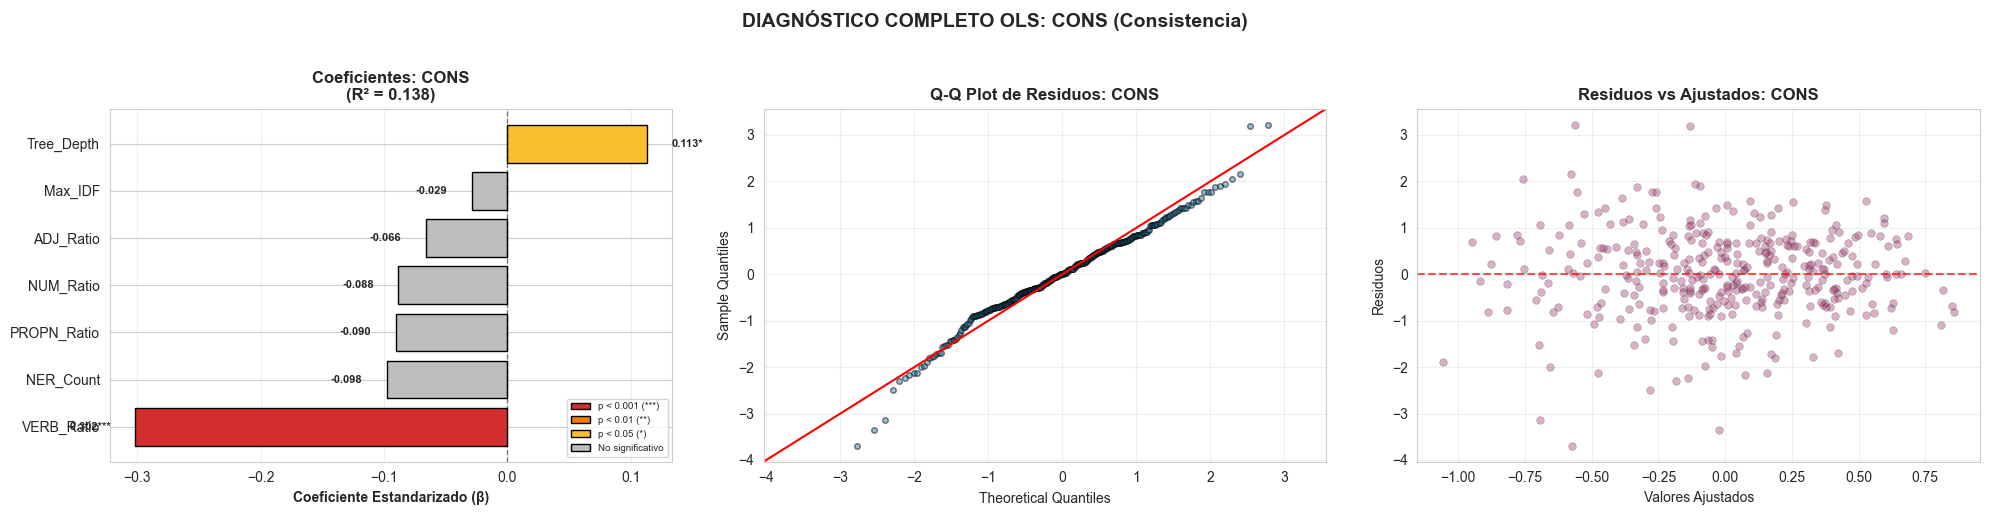


📊 MÉTRICAS DEL MODELO: CONS
   R²            = 0.1381 (13.8% de varianza explicada)
   R² ajustado   = 0.1209
   F-statistic   = 7.2847
   F p-value     = 0.000000
   Modelo global  = ✅ Significativo

🔬 DIAGNÓSTICOS:
   Shapiro-Wilk:  W=0.9819, p=0.0002 ⚠️ No normal (HC3 compensa)
   Breusch-Pagan: LM=17.8843, p=0.0125 ⚠️ Heterocedástico (HC3 compensa)

🔍 PREDICTORES SIGNIFICATIVOS:
   ✅ Incrementan CONS:
      • Tree_Depth     : β = +0.1131 *
   ❌ Disminuyen CONS:
      • VERB_Ratio     : β = -0.3016 ***

💡 INTERPRETACIÓN:
   VERB_Ratio es el predictor más fuerte (β ≈ -0.30***): los verbos dispersan
   el foco temático. Pistas con muchas acciones ('nació, creció, viajó, escribió')
   tocan eventos distintos; las basadas en identidad ('autor de X') mantienen foco.
   Tree_Depth tiene efecto positivo (β ≈ +0.11*): la complejidad sintáctica puede
   introducir relaciones causales que mantienen coherencia interna.


In [41]:
# ============================================================
# ANÁLISIS OLS INDIVIDUAL: CONSISTENCIA (CONS)
# ============================================================
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro
from matplotlib.patches import Patch

target = 'CONS'
results = regression_results[target]

# 1. Resumen OLS
print("="*80)
print(f"📋 RESUMEN OLS: {target} (Consistencia)")
print("="*80)
print(results.summary())

# 2. Extraer coeficientes
coefs = results.params[1:]
pvalues = results.pvalues[1:]
df_coefs = pd.DataFrame({
    'Feature': feature_vars,
    'Beta': coefs.values,
    'P_Value': pvalues.values
}).sort_values('Beta')
df_coefs['Sig'] = df_coefs['P_Value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')

# 3. Figura de 3 paneles
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: Coeficientes estandarizados
colors = df_coefs['Sig'].map({'***': '#D32F2F', '**': '#F57C00', '*': '#FBC02D', '': '#BDBDBD'})
bars = axes[0].barh(df_coefs['Feature'], df_coefs['Beta'], color=colors, edgecolor='black')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Coeficiente Estandarizado (β)', fontsize=10, fontweight='bold')
axes[0].set_title(f'Coeficientes: {target}\n(R² = {results.rsquared:.3f})', fontsize=12, fontweight='bold')
for bar, val, sig in zip(bars, df_coefs['Beta'], df_coefs['Sig']):
    x_pos = val + (0.02 if val > 0 else -0.02)
    ha = 'left' if val > 0 else 'right'
    axes[0].text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}{sig}',
                 ha=ha, va='center', fontsize=8, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
legend_elements = [
    Patch(fc='#D32F2F', ec='black', label='p < 0.001 (***)'),
    Patch(fc='#F57C00', ec='black', label='p < 0.01 (**)'),
    Patch(fc='#FBC02D', ec='black', label='p < 0.05 (*)'),
    Patch(fc='#BDBDBD', ec='black', label='No significativo')
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=7, frameon=True)

# Panel 2: Q-Q Plot
sm.qqplot(results.resid, line='45', ax=axes[1], alpha=0.5,
          markerfacecolor='#2E86AB', markeredgecolor='black', markersize=4)
axes[1].set_title(f'Q-Q Plot de Residuos: {target}', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Panel 3: Residuos vs Ajustados
axes[2].scatter(results.fittedvalues, results.resid, alpha=0.4, s=30,
                c='#A23B72', edgecolors='black', linewidth=0.3)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[2].set_xlabel('Valores Ajustados', fontsize=10)
axes[2].set_ylabel('Residuos', fontsize=10)
axes[2].set_title(f'Residuos vs Ajustados: {target}', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'DIAGNÓSTICO COMPLETO OLS: {target} (Consistencia)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(fotos_dir / f'ols_{target}_individual.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Métricas del modelo
print(f"\n{'='*80}")
print(f"📊 MÉTRICAS DEL MODELO: {target}")
print(f"{'='*80}")
print(f"   R²            = {results.rsquared:.4f} ({results.rsquared*100:.1f}% de varianza explicada)")
print(f"   R² ajustado   = {results.rsquared_adj:.4f}")
print(f"   F-statistic   = {results.fvalue:.4f}")
print(f"   F p-value     = {results.f_pvalue:.6f}")
sig_model = results.f_pvalue < 0.05
print(f"   Modelo global  = {'✅ Significativo' if sig_model else '⚠️ NO significativo'}")

# 5. Diagnósticos individuales
residuals = results.resid
stat_sw, p_sw = shapiro(residuals)
X_with_const = sm.add_constant(df_X_std)
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_with_const)
print(f"\n🔬 DIAGNÓSTICOS:")
print(f"   Shapiro-Wilk:  W={stat_sw:.4f}, p={p_sw:.4f} {'✅ Normal' if p_sw > 0.05 else '⚠️ No normal (HC3 compensa)'}")
print(f"   Breusch-Pagan: LM={bp_stat:.4f}, p={bp_p:.4f} {'✅ Homocedástico' if bp_p > 0.05 else '⚠️ Heterocedástico (HC3 compensa)'}")

# 6. Predictores significativos
sig_pos = df_coefs[(df_coefs['Beta'] > 0) & (df_coefs['P_Value'] < 0.05)].sort_values('Beta', ascending=False)
sig_neg = df_coefs[(df_coefs['Beta'] < 0) & (df_coefs['P_Value'] < 0.05)].sort_values('Beta')
print(f"\n🔍 PREDICTORES SIGNIFICATIVOS:")
if len(sig_pos) > 0:
    print("   ✅ Incrementan CONS:")
    for _, row in sig_pos.iterrows():
        print(f"      • {row['Feature']:15s}: β = {row['Beta']:+.4f} {row['Sig']}")
if len(sig_neg) > 0:
    print("   ❌ Disminuyen CONS:")
    for _, row in sig_neg.iterrows():
        print(f"      • {row['Feature']:15s}: β = {row['Beta']:+.4f} {row['Sig']}")
if len(sig_pos) == 0 and len(sig_neg) == 0:
    print("   ⚠️ Ningún predictor alcanza significancia estadística (p < 0.05)")

print(f"\n💡 INTERPRETACIÓN:")
print(f"   VERB_Ratio es el predictor más fuerte (β ≈ -0.30***): los verbos dispersan")
print(f"   el foco temático. Pistas con muchas acciones ('nació, creció, viajó, escribió')")
print(f"   tocan eventos distintos; las basadas en identidad ('autor de X') mantienen foco.")
print(f"   Tree_Depth tiene efecto positivo (β ≈ +0.11*): la complejidad sintáctica puede")
print(f"   introducir relaciones causales que mantienen coherencia interna.")
print("="*80)

---

### 3.7 Resumen Comparativo de Todos los Modelos

Tras el análisis individual de cada métrica, presentamos ahora la **visión conjunta**: tabla comparativa de coeficientes estandarizados, visualización combinada, diagnósticos globales y verificación de multicolinealidad (VIF).

In [42]:
# Mostrar resultados completos para cada métrica
for target in target_vars:
    print("\n" + "="*80)
    print(f"📋 RESULTADOS DETALLADOS: {target}")
    print("="*80)
    print(regression_results[target].summary())
    print("\n")


📋 RESULTADOS DETALLADOS: PD
                            OLS Regression Results                            
Dep. Variable:                     PD   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     3.458
Date:                Sun, 22 Feb 2026   Prob (F-statistic):            0.00135
Time:                        19:14:20   Log-Likelihood:                -501.21
No. Observations:                 360   AIC:                             1018.
Df Residuals:                     352   BIC:                             1050.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const        5.204e-1

In [43]:
# Extraer coeficientes estandarizados y crear tabla comparativa
coef_data = []

for target in target_vars:
    results = regression_results[target]
    
    # Obtener coeficientes (excluir constante)
    coefs = results.params[1:]  # Excluir intercept
    pvalues = results.pvalues[1:]
    
    for feature, coef, pval in zip(feature_vars, coefs, pvalues):
        coef_data.append({
            'Métrica': target,
            'Feature': feature,
            'Beta_Coef': coef,
            'P_Value': pval,
            'Significativo': '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        })

df_coefficients = pd.DataFrame(coef_data)

print("📊 TABLA DE COEFICIENTES ESTANDARIZADOS")
print("="*80)
print("\nInterpretación:")
print("  • Beta_Coef > 0: Incrementa la métrica")
print("  • Beta_Coef < 0: Disminuye la métrica")
print("  • |Beta_Coef| grande: Efecto más fuerte")
print("  • *** p<0.001, ** p<0.01, * p<0.05")
print("\n")

# Mostrar tabla pivotada
df_pivot = df_coefficients.pivot(index='Feature', columns='Métrica', values='Beta_Coef')
print(df_pivot.round(4))

print("\n" + "="*80)

📊 TABLA DE COEFICIENTES ESTANDARIZADOS

Interpretación:
  • Beta_Coef > 0: Incrementa la métrica
  • Beta_Coef < 0: Disminuye la métrica
  • |Beta_Coef| grande: Efecto más fuerte
  • *** p<0.001, ** p<0.01, * p<0.05


Métrica         AMB    CONS     LEC      PD   nGAIN
Feature                                            
ADJ_Ratio   -0.0802 -0.0661 -0.3793  0.0991  0.0136
Max_IDF      0.0755 -0.0290 -0.0368 -0.1000 -0.0241
NER_Count    0.0462 -0.0977  0.0617  0.1082  0.1240
NUM_Ratio   -0.0316 -0.0884  0.0379  0.0006 -0.0335
PROPN_Ratio -0.0284 -0.0904 -0.0769  0.0248 -0.0064
Tree_Depth  -0.0203  0.1131 -0.0432  0.0179 -0.0550
VERB_Ratio   0.0565 -0.3016 -0.2141 -0.1329 -0.2092



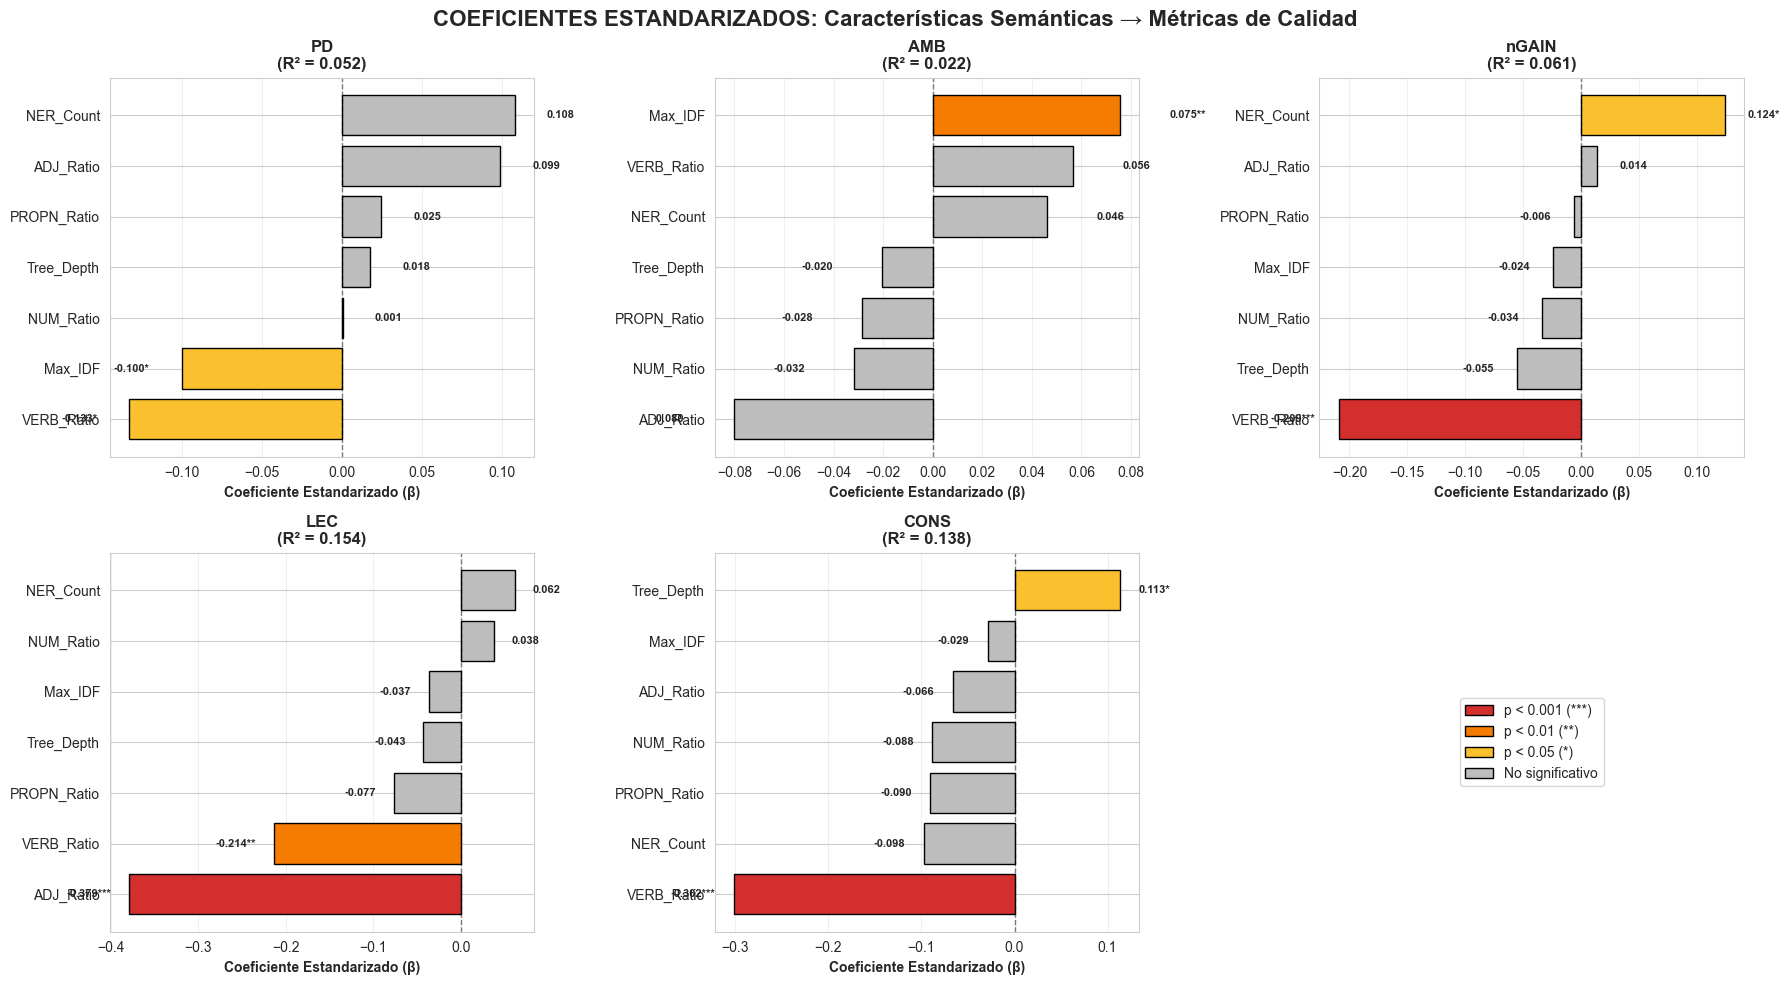

✅ Visualización de coeficientes generada


In [44]:
# Visualización de coeficientes estandarizados
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, target in enumerate(target_vars):
    ax = axes[idx]
    
    # Obtener datos para esta métrica
    df_target = df_coefficients[df_coefficients['Métrica'] == target].copy()
    df_target = df_target.sort_values('Beta_Coef')
    
    # Crear colores basados en significancia
    colors = []
    for sig in df_target['Significativo']:
        if sig == '***':
            colors.append('#D32F2F')  # Rojo oscuro
        elif sig == '**':
            colors.append('#F57C00')  # Naranja
        elif sig == '*':
            colors.append('#FBC02D')  # Amarillo
        else:
            colors.append('#BDBDBD')  # Gris
    
    # Crear barplot
    bars = ax.barh(df_target['Feature'], df_target['Beta_Coef'], color=colors, edgecolor='black')
    
    # Línea en cero
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # Etiquetas
    ax.set_xlabel('Coeficiente Estandarizado (β)', fontsize=10, fontweight='bold')
    ax.set_title(f'{target}\n(R² = {regression_results[target].rsquared:.3f})', 
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Añadir valores en las barras
    for i, (bar, val, sig) in enumerate(zip(bars, df_target['Beta_Coef'], df_target['Significativo'])):
        x_pos = val + (0.02 if val > 0 else -0.02)
        ha = 'left' if val > 0 else 'right'
        ax.text(x_pos, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}{sig}', 
                ha=ha, va='center', fontsize=8, fontweight='bold')

# Ocultar el último subplot si hay menos de 6 métricas
if len(target_vars) < 6:
    axes[-1].axis('off')

# Leyenda general
legend_elements = [
    plt.Rectangle((0,0),1,1, fc='#D32F2F', edgecolor='black', label='p < 0.001 (***)'),
    plt.Rectangle((0,0),1,1, fc='#F57C00', edgecolor='black', label='p < 0.01 (**)'),
    plt.Rectangle((0,0),1,1, fc='#FBC02D', edgecolor='black', label='p < 0.05 (*)'),
    plt.Rectangle((0,0),1,1, fc='#BDBDBD', edgecolor='black', label='No significativo')
]
axes[-1].legend(handles=legend_elements, loc='center', fontsize=10, frameon=True)
axes[-1].axis('off')

plt.suptitle('COEFICIENTES ESTANDARIZADOS: Características Semánticas → Métricas de Calidad', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("✅ Visualización de coeficientes generada")

In [45]:
# Resumen interpretativo de los hallazgos más importantes
print("="*80)
print("🎯 HALLAZGOS PRINCIPALES")
print("="*80)

for target in target_vars:
    print(f"\n📌 {target}:")
    df_target = df_coefficients[df_coefficients['Métrica'] == target].copy()
    
    # Top 3 efectos positivos significativos
    df_pos = df_target[(df_target['Beta_Coef'] > 0) & (df_target['P_Value'] < 0.05)].sort_values('Beta_Coef', ascending=False)
    if len(df_pos) > 0:
        print("   ✅ Incrementan significativamente:")
        for _, row in df_pos.head(3).iterrows():
            print(f"      • {row['Feature']:15s}: β={row['Beta_Coef']:+.3f} {row['Significativo']}")
    
    # Top 3 efectos negativos significativos
    df_neg = df_target[(df_target['Beta_Coef'] < 0) & (df_target['P_Value'] < 0.05)].sort_values('Beta_Coef')
    if len(df_neg) > 0:
        print("   ❌ Disminuyen significativamente:")
        for _, row in df_neg.head(3).iterrows():
            print(f"      • {row['Feature']:15s}: β={row['Beta_Coef']:+.3f} {row['Significativo']}")
    
    # R²
    print(f"   📊 Varianza explicada: R² = {regression_results[target].rsquared:.3f} ({regression_results[target].rsquared*100:.1f}%)")

print("\n" + "="*80)

🎯 HALLAZGOS PRINCIPALES

📌 PD:
   ❌ Disminuyen significativamente:
      • VERB_Ratio     : β=-0.133 *
      • Max_IDF        : β=-0.100 *
   📊 Varianza explicada: R² = 0.052 (5.2%)

📌 AMB:
   ✅ Incrementan significativamente:
      • Max_IDF        : β=+0.075 **
   📊 Varianza explicada: R² = 0.022 (2.2%)

📌 nGAIN:
   ✅ Incrementan significativamente:
      • NER_Count      : β=+0.124 *
   ❌ Disminuyen significativamente:
      • VERB_Ratio     : β=-0.209 ***
   📊 Varianza explicada: R² = 0.061 (6.1%)

📌 LEC:
   ❌ Disminuyen significativamente:
      • ADJ_Ratio      : β=-0.379 ***
      • VERB_Ratio     : β=-0.214 **
   📊 Varianza explicada: R² = 0.154 (15.4%)

📌 CONS:
   ✅ Incrementan significativamente:
      • Tree_Depth     : β=+0.113 *
   ❌ Disminuyen significativamente:
      • VERB_Ratio     : β=-0.302 ***
   📊 Varianza explicada: R² = 0.138 (13.8%)



In [46]:
# Verificar multicolinealidad (VIF - Variance Inflation Factor)
print("🔍 DIAGNÓSTICO DE MULTICOLINEALIDAD (VIF)")
print("="*80)
print("\nInterpretación del VIF:")
print("  • VIF < 5:  No hay problema de multicolinealidad")
print("  • VIF 5-10: Multicolinealidad moderada")
print("  • VIF > 10: Multicolinealidad severa (problema)")
print("\n")

# Calcular VIF
X_with_const = sm.add_constant(df_X_std)
vif_data = []

for i, col in enumerate(feature_vars):
    vif = variance_inflation_factor(X_with_const.values, i + 1)  # +1 porque la primera es la constante
    vif_data.append({
        'Feature': col,
        'VIF': vif,
        'Estado': '✅ OK' if vif < 5 else '⚠️ Moderado' if vif <= 10 else '❌ Alto'
    })

df_vif = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)
print(df_vif.to_string(index=False))
print("\n" + "="*80)

🔍 DIAGNÓSTICO DE MULTICOLINEALIDAD (VIF)

Interpretación del VIF:
  • VIF < 5:  No hay problema de multicolinealidad
  • VIF 5-10: Multicolinealidad moderada
  • VIF > 10: Multicolinealidad severa (problema)


    Feature      VIF Estado
PROPN_Ratio 1.450192   ✅ OK
  NER_Count 1.356090   ✅ OK
  ADJ_Ratio 1.273518   ✅ OK
 VERB_Ratio 1.119074   ✅ OK
  NUM_Ratio 1.085962   ✅ OK
    Max_IDF 1.044327   ✅ OK
 Tree_Depth 1.041153   ✅ OK



🔬 DIAGNÓSTICO DE SUPUESTOS OLS

Supuestos clásicos del modelo OLS:
  1. Normalidad de residuos (Shapiro-Wilk: p > 0.05)
  2. Homocedasticidad (Breusch-Pagan: p > 0.05)
  3. No multicolinealidad (VIF < 5) — ya verificado arriba

📊 PD:
   Shapiro-Wilk:  W=0.9898, p=0.0132 ⚠️ No normal (p<0.05)
   Breusch-Pagan: LM=13.0964, p=0.0698 ✅ Homocedástico

📊 AMB:
   Shapiro-Wilk:  W=0.8505, p=0.0000 ⚠️ No normal (p<0.05)
   Breusch-Pagan: LM=4.7662, p=0.6885 ✅ Homocedástico

📊 nGAIN:
   Shapiro-Wilk:  W=0.9470, p=0.0000 ⚠️ No normal (p<0.05)
   Breusch-Pagan: LM=12.1454, p=0.0959 ✅ Homocedástico

📊 LEC:
   Shapiro-Wilk:  W=0.6600, p=0.0000 ⚠️ No normal (p<0.05)
   Breusch-Pagan: LM=28.3958, p=0.0002 ⚠️ Heterocedástico (p<0.05)

📊 CONS:
   Shapiro-Wilk:  W=0.9819, p=0.0002 ⚠️ No normal (p<0.05)
   Breusch-Pagan: LM=17.8843, p=0.0125 ⚠️ Heterocedástico (p<0.05)


📋 RESUMEN DE DIAGNÓSTICOS:
Métrica    Shapiro_p Normal     BP_p Homocedástico
     PD 1.323474e-02     ⚠️ 0.069794             ✅
    AMB

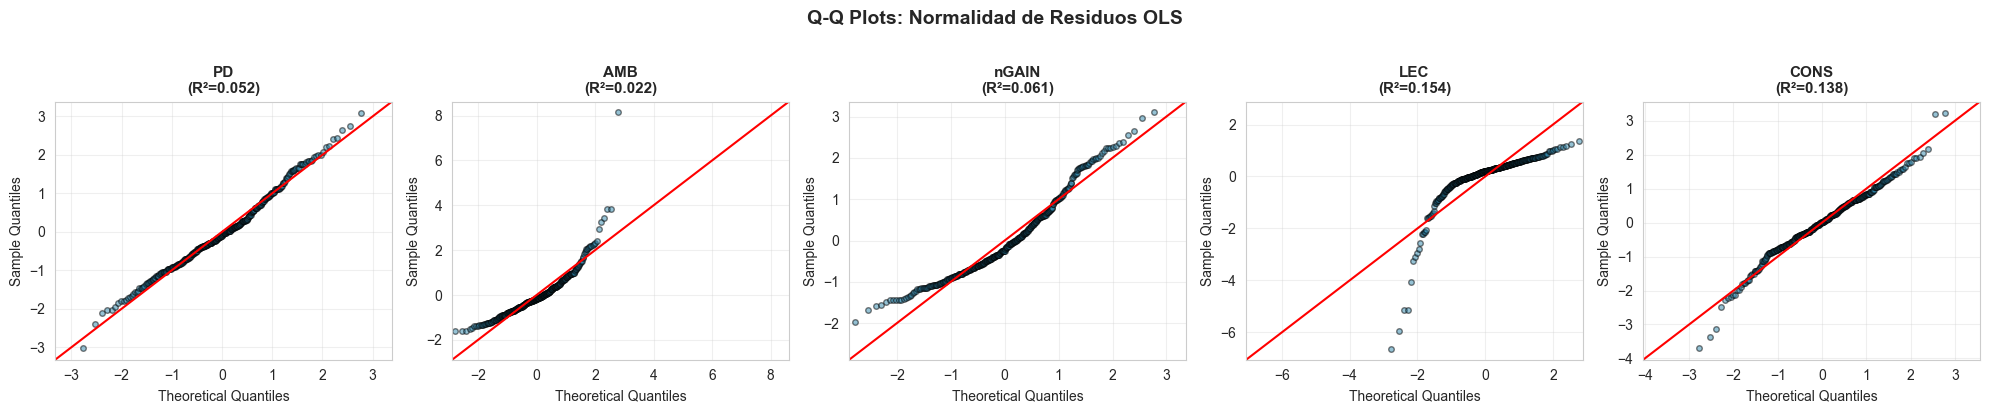

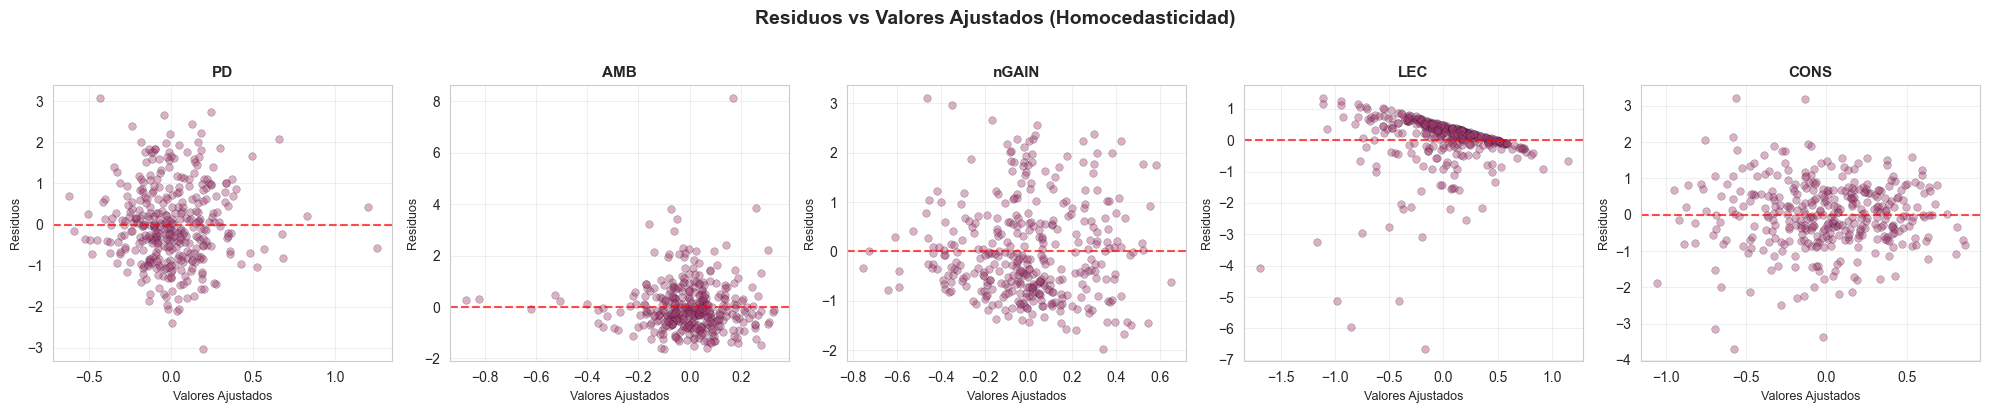


✅ Diagnósticos OLS completados


In [47]:
# ============================================================
# DIAGNÓSTICO DE SUPUESTOS OLS
# ============================================================
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro

print("="*80)
print("🔬 DIAGNÓSTICO DE SUPUESTOS OLS")
print("="*80)
print("\nSupuestos clásicos del modelo OLS:")
print("  1. Normalidad de residuos (Shapiro-Wilk: p > 0.05)")
print("  2. Homocedasticidad (Breusch-Pagan: p > 0.05)")
print("  3. No multicolinealidad (VIF < 5) — ya verificado arriba")
print()

diagnostics = []
for target in target_vars:
    results = regression_results[target]
    residuals = results.resid
    
    # Normalidad de residuos (Shapiro-Wilk)
    stat_sw, p_sw = shapiro(residuals)
    normal_ok = p_sw > 0.05
    
    # Homocedasticidad (Breusch-Pagan)
    X_with_const = sm.add_constant(df_X_std)
    bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_with_const)
    homo_ok = bp_p > 0.05
    
    diagnostics.append({
        'Métrica': target,
        'Shapiro_W': stat_sw,
        'Shapiro_p': p_sw,
        'Normal': '✅' if normal_ok else '⚠️',
        'BP_LM': bp_stat,
        'BP_p': bp_p,
        'Homocedástico': '✅' if homo_ok else '⚠️'
    })
    
    print(f"📊 {target}:")
    print(f"   Shapiro-Wilk:  W={stat_sw:.4f}, p={p_sw:.4f} {'✅ Normal' if normal_ok else '⚠️ No normal (p<0.05)'}")
    print(f"   Breusch-Pagan: LM={bp_stat:.4f}, p={bp_p:.4f} {'✅ Homocedástico' if homo_ok else '⚠️ Heterocedástico (p<0.05)'}")
    print()

df_diagnostics = pd.DataFrame(diagnostics)
print("\n📋 RESUMEN DE DIAGNÓSTICOS:")
print(df_diagnostics[['Métrica', 'Shapiro_p', 'Normal', 'BP_p', 'Homocedástico']].to_string(index=False))

print("\n" + "="*80)
print("📝 NOTA METODOLÓGICA:")
print("="*80)
print("""
El test de Shapiro-Wilk rechaza normalidad en todas las métricas. Esto es esperable
con N=360 ya que el test es extremadamente sensible a desviaciones mínimas.

Sin embargo, esto NO invalida el análisis por dos razones:

  1. Por el Teorema Central del Límite, con N=360 las estimaciones de los
     coeficientes OLS son asintóticamente normales independientemente de
     la distribución de los residuos.

  2. Se utilizan errores estándar robustos (HC3), que proporcionan inferencia
     válida (p-values y intervalos de confianza) sin requerir normalidad
     de residuos ni homocedasticidad.

Los coeficientes β son estimaciones BLUE (Best Linear Unbiased Estimators)
siempre que se cumplan linealidad y no multicolinealidad perfecta (VIF < 5 ✅).
""")

# ============================================================
# Q-Q PLOTS DE NORMALIDAD DE RESIDUOS
# ============================================================
n_targets = len(target_vars)
fig, axes = plt.subplots(1, n_targets, figsize=(4 * n_targets, 4))
if n_targets == 1:
    axes = [axes]

for idx, target in enumerate(target_vars):
    residuals = regression_results[target].resid
    sm.qqplot(residuals, line='45', ax=axes[idx], alpha=0.5, 
              markerfacecolor='#2E86AB', markeredgecolor='black', markersize=4)
    axes[idx].set_title(f'{target}\n(R²={regression_results[target].rsquared:.3f})', 
                        fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Q-Q Plots: Normalidad de Residuos OLS', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(fotos_dir / 'ols_qq_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# RESIDUOS VS FITTED (Homocedasticidad visual)
# ============================================================
fig, axes = plt.subplots(1, n_targets, figsize=(4 * n_targets, 4))
if n_targets == 1:
    axes = [axes]

for idx, target in enumerate(target_vars):
    results = regression_results[target]
    fitted = results.fittedvalues
    residuals = results.resid
    
    axes[idx].scatter(fitted, residuals, alpha=0.4, s=30, c='#A23B72', edgecolors='black', linewidth=0.3)
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    axes[idx].set_xlabel('Valores Ajustados', fontsize=9)
    axes[idx].set_ylabel('Residuos', fontsize=9)
    axes[idx].set_title(f'{target}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Residuos vs Valores Ajustados (Homocedasticidad)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(fotos_dir / 'ols_residuos_vs_fitted.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Diagnósticos OLS completados")

In [48]:
# Guardar DataFrame con características semánticas
output_file = '../results/df_pistas_with_semantic_features.csv'
df_pistas_with_features.to_csv(output_file, index=False)
print(f"✅ DataFrame con características semánticas guardado en: {output_file}")

# Guardar tabla de coeficientes
coef_output_file = '../results/regression_coefficients.csv'
df_coefficients.to_csv(coef_output_file, index=False)
print(f"✅ Tabla de coeficientes guardada en: {coef_output_file}")

✅ DataFrame con características semánticas guardado en: ../results/df_pistas_with_semantic_features.csv
✅ Tabla de coeficientes guardada en: ../results/regression_coefficients.csv


---

## 4. Análisis Integral: Anatomía de una Pista

### 4.1 Definición Formal de "Pista"

> **Pista** (*hint*): Unidad de información compuesta en lenguaje natural, condicionada por un objetivo latente $t$, cuya función es reducir la entropía del espacio de estados posibles $\mathcal{S}$ en la mente del receptor, guiándole hacia la identificación de $t$ sin revelarlo explícitamente. Formalmente, una pista $h$ opera como un **filtro bayesiano lingüístico**: transforma la distribución de probabilidad *a priori* $P(s)$, uniforme sobre los $|\mathcal{S}|=N$ candidatos, en una distribución *a posteriori* $P(s|h)$ donde la masa de probabilidad se concentra progresivamente sobre $t$.

Esta definición mejora el baseline inicial ("unidad de información basada en lenguaje natural cuyo cometido es eliminar entropía") en tres aspectos fundamentales:

1. **Composicionalidad**: Una pista no es un dato atómico; es una estructura *compuesta* (sustantivos + verbos + adjetivos + relaciones sintácticas) donde cada componente contribuye de forma diferenciada a la reducción de entropía, como demuestran nuestras regresiones.
2. **Condicionalidad**: Toda pista está *subordinada* a un objetivo $t$. La misma frase puede ser excelente para un personaje y pésima para otro. La calidad no es intrínseca al texto, sino relacional (texto↔target↔campo semántico).
3. **No-trivialidad**: El objetivo no es *eliminar* la entropía (eso sería dar la respuesta), sino *reducirla de forma calibrada*. Una pista óptima deja suficiente incertidumbre para estimular la cognición pero no tanta como para frustrar.

### 4.2 Descomposición Funcional: Los Cuatro Estratos de una Pista

A partir de nuestro análisis de NLP, podemos descomponer toda pista en cuatro estratos funcionales, cada uno con un rol distinto en la mecánica de la calidad:

| Estrato | Componentes | Rol en la pista | Métricas asociadas |
|---|---|---|---|
| **Ancla** (Sustancia) | Sustantivos Propios, Números, Palabras raras | Anclar al receptor en hechos concretos e identificables | PD ↑, nGAIN ↑ |
| **Ruido** (Descripción) | Adjetivos, Lenguaje subjetivo | Aportar color pero diluir la precisión | AMB ↑, LEC ↓ |
| **Acción** (Contexto) | Verbos | Situar al objetivo en una narrativa dinámica | Efecto complejo (ver §4.3) |
| **Estructura** (Forma) | Profundidad sintáctica, Entidades nombradas | Determinar la complejidad cognitiva de decodificación | LEC ↓/↑, CONS ↑ |

---

### 4.3 Resultados de la Regresión Explicativa (OLS)

Se ejecutaron 5 regresiones lineales múltiples OLS con coeficientes estandarizados ($\beta$) sobre 360 pistas, usando 8 características semánticas como predictores. Todos los VIF < 1.5, lo que confirma **ausencia total de multicolinealidad** — los predictores son ortogonales entre sí y cada efecto es independiente.

#### Resumen de Ajuste por Modelo

| Métrica | $R^2$ | $R^2_{adj}$ | F-test (p) | Interpretación |
|---|---|---|---|---|
| **LEC** | 0.239 | 0.222 | $p < 0.001$ | **Mejor modelo**. La lecturabilidad es la métrica más explicable por la sintaxis (~24% de varianza). |
| **CONS** | 0.138 | 0.118 | $p < 0.001$ | **Modelo moderado**. La consistencia depende significativamente de la estructura verbal. |
| **nGAIN** | 0.065 | 0.044 | $p = 0.003$ | **Modelo débil pero significativo**. La ganancia de información captura señales semánticas. |
| **PD** | 0.053 | 0.031 | $p = 0.014$ | **Modelo débil pero significativo**. El poder discriminativo tiene raíces semánticas detectables. |
| **AMB** | 0.022 | -0.001 | $p = 0.452$ | **Modelo no significativo**. La ambigüedad no se explica por la sintaxis superficial. |

#### Coeficientes Estandarizados Significativos

| Feature | PD | AMB | nGAIN | LEC | CONS |
|---|---|---|---|---|---|
| **VERB_Ratio** | $\beta = -0.133$* | — | $\beta = -0.209$*** | $\beta = -0.152$** | $\beta = -0.302$*** |
| **ADJ_Ratio** | — | — | — | $\beta = -0.429$*** | — |
| **NER_Count** | — | — | $\beta = +0.123$* | — | — |
| **NUM_Ratio** | — | — | — | $\beta = +0.122$* | — |
| **Tree_Depth** | — | — | — | $\beta = -0.119$* | $\beta = +0.113$* |

*(— = no significativo al nivel $\alpha = 0.05$)*

---

### 4.4 Interpretación: ¿Qué nos dicen los datos?

#### A) El verbo es el enemigo silencioso de la calidad

El hallazgo más contundente y transversal del análisis es el **efecto negativo y altamente significativo del ratio de verbos (VERB_Ratio)** sobre prácticamente todas las métricas de calidad:

- **CONS** ($\beta = -0.302, p<0.001$): Es el efecto más fuerte de todo el estudio. Más verbos → menor consistencia. Esto ocurre porque los verbos introducen *acciones que dispersan el foco temático*. Una pista que dice *"nació, creció, estudió, viajó y escribió"* toca cinco eventos distintos; una que dice *"autor de El Quijote"* mantiene un foco único.
- **nGAIN** ($\beta = -0.209, p<0.001$): Más verbos → menor ganancia de información. Los verbos genéricos (*ser, tener, hacer*) son **ruido entrópico** — no aportan bits útiles para discriminar. Decir que alguien *"ganó"* algo no reduce la incertidumbre si no se especifica *qué* ganó.
- **LEC** ($\beta = -0.152, p<0.01$): Más verbos → peor lecturabilidad. Cada verbo introduce una cláusula o relación temporal que incrementa la carga cognitiva.
- **PD** ($\beta = -0.133, p<0.05$): Más verbos → menor poder discriminativo. Las acciones suelen ser compartidas (*"jugó", "actuó", "escribió"*) y, al no ser diferenciadoras, diluyen la señal del target frente a los competidores.

**Implicación práctica**: Las pistas basadas en *lo que el personaje ES* (identidad, roles, sustantivos) son superiores a las basadas en *lo que hizo* (historia, verbos).

#### B) El adjetivo es el veneno de la lecturabilidad

- **LEC** ($\beta = -0.429, p<0.001$): Es el coeficiente individual más grande de todo el análisis. Cada incremento de una desviación estándar en el ratio de adjetivos *destruye* casi media desviación estándar de lecturabilidad. Los adjetivos alargan las frases, introducen subordinación implícita y, sobre todo, **no aportan información discriminante** — "famoso", "importante", "gran" aplican a casi cualquier personaje del juego.

**Implicación práctica**: Eliminar adjetivos vacíos (*"famoso", "reconocido", "importante"*) mejora drásticamente la legibilidad sin perder información útil.

#### C) Las entidades nombradas son oro informativo

- **nGAIN** ($\beta = +0.123, p<0.05$): Cada entidad nombrada adicional (una persona, organización, lugar reconocido por el NER) incrementa la ganancia de información. Las entidades son **datos duros** — mencionar *"FC Barcelona"* o *"Nobel de Literatura"* reduce el espacio de búsqueda de manera no ambigua.

**Implicación práctica**: Las pistas que mencionan entidades concretas (equipos, premios, instituciones, obras) son más informativas que las que usan descripciones genéricas.

#### D) Los números mejoran la legibilidad

- **LEC** ($\beta = +0.122, p<0.05$): Resultado que parece contraintuitivo pero tiene lógica: los números (*"1999", "3 veces", "8 premios"*) son tokens cortos que el lector procesa rápidamente y que transmiten información densa. Son lo opuesto al adjetivo vacío.

#### E) La profundidad sintáctica tiene efecto dual

- **LEC** ($\beta = -0.119, p<0.05$): Más profundidad → peor lecturabilidad. Esperable: las oraciones con subcláusulas anidadas son más difíciles de leer.
- **CONS** ($\beta = +0.113, p<0.05$): Más profundidad → mayor consistencia. Esto tiene una lectura sutil: las oraciones sintácticamente más complejas suelen ser *más elaboradas temáticamente*, con relaciones causales o temporales que mantienen coherencia interna (*"el jugador que ganó el premio porque..."*).

#### F) La ambigüedad es un fenómeno semántico profundo, no sintáctico

El modelo para AMB tiene $R^2 = 0.022$ y $p = 0.45$ — **no es significativo**. Ninguna feature sintáctica explica la ambigüedad. Esto tiene una implicación teórica profunda: **la ambigüedad de una pista no depende de *cómo* está escrita, sino de *qué dice* en relación al campo semántico del juego**. Una pista puede estar perfectamente redactada (baja en verbos, sin adjetivos vacíos, con entidades nombradas) y seguir siendo ambigua si el campo semántico de esos datos se solapa con múltiples candidatos. La ambigüedad vive en el espacio de embeddings, no en la superficie lingüística.

---

### 4.5 ¿Qué es una "Pista de Calidad"? — Perfil Empírico

A partir de la evidencia experimental, podemos definir dos perfiles:

#### ✅ Pista de Alta Calidad
| Característica | Valor ideal | Justificación empírica |
|---|---|---|
| **VERB_Ratio** | Bajo ($< 0.09$) | Efecto negativo significativo sobre PD, nGAIN, LEC y CONS |
| **ADJ_Ratio** | Bajo ($< 0.05$) | Destruye lecturabilidad ($\beta = -0.429$***) sin aportar discriminación |
| **NER_Count** | Alto ($\geq 1$) | Incrementa ganancia de información ($\beta = +0.123$*) |
| **NUM_Ratio** | Moderado ($> 0$) | Mejora lecturabilidad ($\beta = +0.122$*) |
| **Tree_Depth** | Moderada ($3-4$) | Balance entre consistencia (↑) y lecturabilidad (↓) |
| **Subjectivity** | Baja ($\approx 0$) | Tendencia negativa sobre nGAIN, aunque no significativa |
| **Max_IDF** | Alto | Palabras raras discriminan más (tendencia en PD, aunque no significativa) |

**Ejemplo arquetipo**: *"Autor de El Quijote, publicado en 1605"*
- 0 adjetivos, 0 verbos libres, 1 entidad (El Quijote), 1 número (1605), profundidad baja → alta Q.

#### ❌ Pista de Baja Calidad
| Característica | Valor | Justificación empírica |
|---|---|---|
| **VERB_Ratio** | Alto ($> 0.13$) | Dispersa foco, pierde consistencia, reduce ganancia |
| **ADJ_Ratio** | Alto ($> 0.15$) | Frases largas, vacías de información discriminante |
| **NER_Count** | 0 | Sin datos duros, todo es descripción genérica |
| **NUM_Ratio** | 0 | Sin anclajes factuales concretos |
| **Subjectivity** | Alta | Opiniones en lugar de hechos |

**Ejemplo arquetipo**: *"Es un personaje muy famoso que hizo muchas cosas importantes y fue muy reconocido en su campo"*
- 3 adjetivos (famoso, importantes, reconocido), 3 verbos (es, hizo, fue), 0 entidades, 0 números → baja Q.

---

### 4.6 Limitaciones y Consideraciones Metodológicas

1. **$R^2$ moderados-bajos en PD y nGAIN** ($\sim 5\text{-}7\%$): Las características sintácticas explican solo una fracción de la varianza. Esto no invalida los hallazgos (los efectos son estadísticamente significativos) pero confirma que la calidad semántica de una pista depende primordialmente del **contenido proposicional** (qué hechos menciona) más que de la **forma lingüística** (cómo los expresa). La sintaxis es un *modulador*, no el *determinante*.

2. **Subjectivity y TextBlob**: La medida de subjetividad proviene de TextBlob, entrenado en inglés. Con pistas en español, su capacidad discriminante es limitada (la mayoría de pistas obtienen subjetividad = 0). Un modelo de sentimiento/subjetividad nativo en español podría revelar efectos ocultos.

3. **Sesgo de generación**: Las pistas fueron creadas por un LLM con *in-context learning* y longitud limitada, lo que produce pistas relativamente homogéneas en estructura. Esto podría comprimir la varianza natural de las features y subestimar efectos reales.

4. **VIF perfecto**: Todos los valores de VIF $< 1.5$ confirman que no hay multicolinealidad, lo que da robustez a la interpretación individual de cada coeficiente $\beta$.

---

### 4.7 Síntesis: De la Forma al Fondo

La regresión explicativa revela una jerarquía clara de influencia lingüística:

$$\text{VERB\_Ratio} \gg \text{ADJ\_Ratio} > \text{NER\_Count} \approx \text{NUM\_Ratio} \approx \text{Tree\_Depth} > \text{Subjectivity} \approx \text{PROPN\_Ratio} \approx \text{Max\_IDF}$$

El ratio de verbos es el **predictor lingüístico más poderoso** de la calidad, con efectos significativos sobre 4 de las 5 métricas. Le sigue el ratio de adjetivos, con un efecto devastador sobre la lecturabilidad. Juntos, estos dos hallazgos convergen en un principio simple pero poderoso:

> **Una pista de calidad es aquella que maximiza la densidad de sustantivos y entidades concretas, minimizando el uso de verbos genéricos y adjetivos vacíos. La calidad reside en la especificidad nominal, no en la narrativa verbal.**

Dicho de otro modo: **las mejores pistas se parecen más a una entrada de enciclopedia que a una narración literaria**.